## This notebook adds the enformer prediction class (currently MAX over all cell-types) to the to be merged variant files
- First merging variant files (for each variant to which cell-type and variant-type (common, rare, ultra-rare, singleton) it belongs to)
- Merge all the enformer files (only the raw files exist) for each cell-type and variant file to the merged variant files and compute the enformer class   
- path: /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/<gene_list>/enformer/<gene_list>.<variant_type>_680_columns.tsv.gz
- gene_list = ['cardiac', 'cava', 'neuro', 'random']
- variant_type = ['ultra_rare', 'singleton']
- read file into pandas, get following columns
  - #CHROM	POS	ID	REF	ALT	DNase_max	INDEX_max	QUAL	FILTER	INFO	gene_set	variant_type	enformer_class

### Disclaimer: As I wrote this notebook I thought the enformer files are fine like that but they miss the information which one is in the enformer high; enformer low and enformer random class therefore a preprocessing was required which is done in the notebook: add_enformer_high_low_information.ipynb 
- The result is a file only considering ultra-rare and singleton variants and this needs to be combined with common (and rare) variants tsvs which are produced in the following notebook

In [1]:
import pandas as pd
import os
import numpy as np
import yaml
import re
# for the correlation plotting
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

config_path = "../../global80K_config.yaml"
# load config file
with open(config_path, "r") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

### Sanity check if all files exist

In [2]:
gene_list = ['cardiac', 'cava', 'neuro', 'random']
variant_type_list = ['ultra-rare', 'singleton']
for gene_type in gene_list:
    for variant_type in variant_type_list:
        enformer_file_name = f'/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/{gene_type}/enformer/{gene_type}.{variant_type}_680_columns.tsv.gz'
        prioritized_variant_file = f'/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/{gene_type}/variants/{gene_type}.{variant_type}_variants.vcf'
        print(enformer_file_name)
        print(os.path.exists(enformer_file_name))
        print(prioritized_variant_file)
        print(os.path.exists(prioritized_variant_file))

/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cardiac/enformer/cardiac.ultra-rare_680_columns.tsv.gz
True
/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cardiac/variants/cardiac.ultra-rare_variants.vcf
True
/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cardiac/enformer/cardiac.singleton_680_columns.tsv.gz
True
/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cardiac/variants/cardiac.singleton_variants.vcf
True
/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cava/enformer/cava.ultra-rare_680_columns.tsv.gz
True
/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cava/variants/cava.ultra-rare_variants.vcf
True
/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cava/enformer/cava.singleton_680_co

In [11]:
## Helpful code snippets

# for one example
# load all files in the folder '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/' with the extention '.tsv.gz'
# /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/<gene_list>/enformer/<gene_list>.<variant_type>_680_columns.tsv.gz
# /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/<gene_list>/variants/<gene_list>.<variant_type>_variants.vcf

gene_list = ['cardiac', 'cava', 'neuro', 'random']
# gene_list = ['neuro']
variant_type_list = ['common','rare','ultra-rare', 'singleton']
variant_type_list = ['common','rare']
# variant_type_list = ['ultra-rare']

for gene_type in gene_list:
    for variant_type in variant_type_list:
        print(f'/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/{gene_type}.{variant_type}_variants.tsv')
        # enformer_file_name = f'/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/{gene_type}/enformer/test_{gene_type}.{variant_type}_680_columns.tsv.gz'
        # prioritized_variant_file = f'/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/{gene_type}/variants/{gene_type}.{variant_type}_variants.vcf'
        # print(enformer_file_name)
        # print(prioritized_variant_file)
        # enformer_file = pd.read_csv(enformer_file_name, sep='\t')
        # variant_file = pd.read_csv(prioritized_variant_file, sep='\t', comment='#', header=None)
        # variant_file.columns = ['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']

        # break

/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/cardiac.common_variants.tsv
/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/cardiac.rare_variants.tsv
/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/cava.common_variants.tsv
/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/cava.rare_variants.tsv
/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/neuro.common_variants.tsv
/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/neuro.rare_variants.tsv
/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/random.common_variants.tsv
/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_

### Start combining enformer and variant vcf (scripts should be used because notebook might crash due to memory issues)
- preprocess enformer files 
  - computing max over all cell-types
  - remove unused columns
  - save to new file
- preprocess variant vcfs 
  - add cell-type and variant-type columns
  - merge variant files to one file
  - save to new file

In [5]:
# Commented out because writes again a file
# ## write function which prepares the enformer files (getting max and dropping columns => storing again)

# def get_max_and_column_enformer_file(enformer_file_path):
#     """Returns the modified enformer file with max and max column"""
#     enformer_file = pd.read_csv(enformer_file_path, sep='\t')
#     # compute max and id of max as mohan did in combine_tsv_vcf.py
#     enformer_df = enformer_file.iloc[:,:679]
#     print(enformer_df.iloc[:,5:].head())
#     enformer_df['DNase_max'] = enformer_df.iloc[:,5:].values.max(axis = 1)
#     enformer_df['max_col'] = enformer_df.iloc[:,5:].idxmax(axis = 1)
#     # drop all columns with 'DNASE' in name
#     enformer_df = enformer_df.drop(enformer_df.filter(regex='DNASE').columns, axis=1)
#     return enformer_df

# def write_modified_enformer_file(gene_type, variant_type, enformer_out_name):
#     enformer_file_name = f'/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/{gene_type}/enformer/{gene_type}.{variant_type}_680_columns.tsv.gz'
#     enformer_df = get_max_and_column_enformer_file(enformer_file_name)
#     print('Write to file: ', enformer_out_name)
#     enformer_df.to_csv(enformer_out_name, sep='\t', index=False)

# gene_list = ['cardiac', 'cava', 'neuro', 'random']
# # gene_list = ['neuro']
# variant_type_list = ['ultra-rare', 'singleton']

# for gene_type in gene_list:
#     for variant_type in variant_type_list:
#         enformer_out_name = f'/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/{gene_type}/enformer/{gene_type}.{variant_type}_max_values.tsv'
#         write_modified_enformer_file(gene_type, variant_type, enformer_out_name)

In [ ]:
# # one example:
# gene_type = 'neuro'
# variant_type = 'ultra-rare'
# enformer_file_name = f'/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/{gene_type}/enformer/{gene_type}.{variant_type}_680_columns.tsv.gz'
# prioritized_variant_file = f'/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/{gene_type}/variants/{gene_type}.{variant_type}_variants.vcf'
# print(enformer_file_name)
# print(prioritized_variant_file)
# enformer_file = pd.read_csv(enformer_file_name, sep='\t')
# enformer_file.head()

# enformer_df.head()

In [ ]:
# Commented out because writes files
# # add to each vcf file additional columns: gene_type and variant_type and merge them together

# gene_list = ['cardiac', 'cava', 'neuro', 'random']
# variant_type_list = ['common', 'rare', 'ultra-rare', 'singleton']

# outpath_list = []
# for gene_type in gene_list:
#     for variant_type in variant_type_list:
#         prioritized_variant_file = f'/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/{gene_type}/variants/{gene_type}.{variant_type}_variants.vcf'
#         print(prioritized_variant_file)
#         variant_file = pd.read_csv(prioritized_variant_file, sep='\t', comment='#', header=None)
#         variant_file.columns = ['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']
#         variant_file.head()
#         # add additional columns
#         variant_file['gene_type'] = gene_type
#         variant_file['variant_type'] = variant_type
#         variant_file.head()
#         # write to different directory
#         outdir = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants'
#         output_name = f'{gene_type}.{variant_type}_variants.tsv'
#         output_path = os.path.join(outdir, output_name)
#         outpath_list.append(output_path)
#         print('Write to file: ', output_path)
#         # variant_file.to_csv(output_path, sep='\t', index=False)

# # merge the list of files together
# merged_df = pd.concat([pd.read_csv(file, sep='\t') for file in outpath_list])
# merged_df.to_csv(config['files']['creating']['merged_variant_table'], sep='\t', index=False)

In [12]:
# merged variant file
merged_variants_file = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/merged_prioritized_variants.tsv'
merged_variants = pd.read_csv(merged_variants_file, sep='\t')
merged_variants


FileNotFoundError: [Errno 2] No such file or directory: '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/merged_prioritized_variants.tsv'

#### !merging at this point does not make sense, because there will be duplicated variants which are then annotated with two gene_type inforamtions and will be hard to distingues from which gene type the enformer class came from
- So this step should be skipped

In [ ]:
# # merge enformer and write the not is na rows to another directory
# gene_list = ['cardiac', 'cava', 'neuro', 'random']
# variant_type_list = ['common','rare','ultra-rare', 'singleton']

# for gene_type in gene_list:
#     for variant_type in variant_type_list:
#         # read variant file
#         prioritized_variant_file = f'/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/{gene_type}.{variant_type}_variants.tsv'
#         print(prioritized_variant_file)
#         # read enformer max file
#         # variant_file = pd.read_csv(prioritized_variant_file, sep='\t', comment='#', header=None)
#         # variant_file.columns = ['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']
#         # variant_file.head()
#         ## add additional columns
#         variant_file['gene_type'] = gene_type
#         variant_file['variant_type'] = variant_type
#         variant_file.head()
#         # write to different directory
#         outdir = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants'
#         output_name = f'{gene_type}.{variant_type}_variants.tsv'
#         output_path = os.path.join(outdir, output_name)
#         print('Write to file: ', output_path)
#         variant_file.to_csv(output_path, sep='\t', index=False)

In [13]:
# groupby gene_type and variant_type and count (sanity check passed: 5000, 5000, 5000, 2500 => 17500 for singleton and ultra-rare)
merged_variants.groupby(['variant_type', 'gene_type'])['ID'].count()

NameError: name 'merged_variants' is not defined

In [11]:
# # one example
# gene_type = 'cardiac'
# variant_type = 'ultra-rare'
# prioritized_variant_file = f'/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/{gene_type}/variants/{gene_type}.{variant_type}_variants.vcf'
# print(prioritized_variant_file)
# variant_file = pd.read_csv(prioritized_variant_file, sep='\t', comment='#', header=None)
# variant_file.columns = ['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']
# variant_file.head()
# # add additional columns
# variant_file['gene_type'] = gene_type
# variant_file['variant_type'] = variant_type
# variant_file.head()
# # write to different directory
# outdir = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants'
# output_name = f'{gene_type}.{variant_type}_variants.tsv'
# output_path = os.path.join(outdir, output_name)
# print('Write to file: ', output_path)
# variant_file.to_csv(output_path, sep='\t', index=False)

/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cardiac/variants/cardiac.ultra-rare_variants.vcf


In [116]:


# read variant file and match with id all files have 8 lines of comments
variant_file = pd.read_csv(prioritized_variant_file, sep='\t', skiprows=8)
variant_file.head()
print(variant_file.shape[0])
# merge the two files: take variant_file and add DNase_max and max_col from enformer_df (with ID and id)
# merged_enformer_file = pd.merge(variant_file, enformer_df, left_on='ID', right_on='id', how='left')
# merged_enformer_file.head()
# print(merged_enformer_file[merged_enformer_file['Dnase_max'].isna()].shape[0])


/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/neuro/enformer/test_neuro.ultra-rare_680_columns.tsv.gz
/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/neuro/variants/neuro.ultra-rare_variants.vcf
5000


,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chrom,pos,id,ref,alt,DNase_max,max_col
0,chr7,70660644,AUTS2|ENSG00000158321.19|EH38E3778477|7-706606...,C,T,1,PASS,AF=0.000348226;AC=53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chr2,63856432,UGP2|ENSG00000169764.16|EH38E3347620|2-6385643...,A,T,1,PASS,AF=1.31475e-05;AC=2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chr16,31064606,BCKDK|ENSG00000103507.14|EH38E3177440|16-31064...,C,G,1,PASS,AF=1.31384e-05;AC=2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,chr18,44729852,SETBP1|ENSG00000152217.20|EH38E3265867|18-4472...,G,A,1,PASS,AF=0.000164225;AC=25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,chr21,46425079,DIP2A|ENSG00000160305.18|EH38E3465123|21-46425...,G,T,1,PASS,AF=0.000729716;AC=111,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [118]:
# look for examples in enformer_file:
enformer_df.head()
enformer_df[enformer_df['id'] == 'AUTS2|ENSG00000158321.19|EH38E3778477|7-70660644-C-T']

,chrom,pos,id,ref,alt,DNase_max,max_col


### Merge the variant and enformer information
- premerging variant information columns: CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	gene_type	variant_type
- since ID is not unique because there exist multiple rows for different gene_types I made gene_types a list within the following code

Functions to filter for common and rare variants

In [3]:
# the following function can be replaced by: merged_prioritized_variants_df.groupby(['gene_type', 'variant_type']).size()
def is_gene_type_variant_type(row, gene_type, variant_type):
    """returns row if the row is member of gene type or variant type"""
    if (gene_type in row['gene_type_list']) and (row['variant_type'] == variant_type):
        return True
    return False


def is_gene_type(row, gene_type):
    return gene_type in row['gene_type_list']


def is_not_common_or_rare(variant_type):
    common_or_rare = ['common', 'rare']
    return not variant_type in common_or_rare


def mutliple_gene_types(gene_type):
    return len(gene_type) > 1

In [4]:
enformer_file_base_directory = '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k'
enformer_all_max_files_relative = ['cardiac/enformer/cardiac.ultra-rare_max_values.tsv', 'cardiac/enformer/cardiac.singleton_max_values.tsv', 'cava/enformer/cava.ultra-rare_max_values.tsv', 'cava/enformer/cava.singleton_max_values.tsv', 'neuro/enformer/neuro.ultra-rare_max_values.tsv', 'neuro/enformer/neuro.singleton_max_values.tsv', 'random/enformer/random.ultra-rare_max_values.tsv', 'random/enformer/random.singleton_max_values.tsv']
enformer_all_max_files = [os.path.join(enformer_file_base_directory, relative_path) for relative_path in enformer_all_max_files_relative]
print(enformer_all_max_files)

# # enformer_all_max_files = ['/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cardiac/enformer/cardiac.ultra-rare_max_values.tsv', '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cardiac/enformer/cardiac.singleton_max_values.tsv', '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cava/enformer/cava.ultra-rare_max_values.tsv', '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cava/enformer/cava.singleton_max_values.tsv', '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/neuro/enformer/neuro.ultra-rare_max_values.tsv', '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/neuro/enformer/neuro.singleton_max_values.tsv', '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/random/enformer/random.ultra-rare_max_values.tsv', '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/random/enformer/random.singleton_max_values.tsv']

# merged_prioritized_variants_path = config['files']['creating']['merged_variant_table']
# merged_prioritized_variants_df = pd.read_csv(merged_prioritized_variants_path, sep="\t")
# merged_prioritized_variants_df # 71410 rows × 10 columns

['/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cardiac/enformer/cardiac.ultra-rare_max_values.tsv', '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cardiac/enformer/cardiac.singleton_max_values.tsv', '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cava/enformer/cava.ultra-rare_max_values.tsv', '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/cava/enformer/cava.singleton_max_values.tsv', '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/neuro/enformer/neuro.ultra-rare_max_values.tsv', '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/neuro/enformer/neuro.singleton_max_values.tsv', '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/random/enformer/random.ultra-rare_max_values.tsv', '/data/ce

#### Create new gene_type column called gene_type list which is not useful because we dont have ever the enformer class at the gene type level


In [ ]:
# # merged_prioritized_variants_df['gene_type_list'] = merged_prioritized_variants_df.groupby('ID')['gene_type'].transform(list)
# gene_list_df = merged_prioritized_variants_df.groupby('ID')['gene_type'].apply(list).reset_index(name='gene_type_list')

# # left join with
# merged_prioritized_variants_df = merged_prioritized_variants_df.merge(gene_list_df, on='ID', how='left')

# merged_prioritized_variants_df.drop_duplicates(subset=['ID'], inplace=True)
# merged_prioritized_variants_df.drop(columns=['gene_type'], inplace=True)

In [ ]:
# merged_prioritized_variants_df.shape[0]

69205

In [2]:
# merged_prioritized_variants_df.head()

In [3]:
# multimatch_variants = merged_prioritized_variants_df.loc[merged_prioritized_variants_df['gene_type_list'].apply(mutliple_gene_types)]
# variants_without_multimatches = merged_prioritized_variants_df.loc[~merged_prioritized_variants_df['gene_type_list'].apply(mutliple_gene_types)]
# multimatch_variants

In [107]:
# merged_prioritized_variants_df[['ID']].nunique() # 69205 (shape: 71410) =>  ID column is not unique

ID    69205
dtype: int64

Combine enformer and variant table
- first try: without excluding common and rare variant_type: 
    - cardiac.ultra-rare_max_values.tsv (5779)
    - cardiac.singleton_max_values.tsv (5791)
    - cava.ultra-rare_max_values.tsv (5199)
    - cava.singleton_max_values.tsv (5211)
    - neuro.ultra-rare_max_values.tsv (6130)
    - neuro.singleton_max_values.tsv (6085)
    - random.ultra-rare_max_values.tsv (2500)
    - random.singleton_max_values.tsv (2500)
- second try: filter common and rare first out (same numbers)
- if I make the ids unique: 
    - cardiac.ultra-rare_max_values.tsv
    - 5446
    - cardiac.singleton_max_values.tsv
    - 5453
    - cava.ultra-rare_max_values.tsv
    - 5041
    - cava.singleton_max_values.tsv
    - 5036
    - neuro.ultra-rare_max_values.tsv
    - 5825
    - neuro.singleton_max_values.tsv
    - 5785
    - random.ultra-rare_max_values.tsv
    - 2500
    - random.singleton_max_values.tsv
    - 2500
- if I remove all the multiple matching (multiple gene_types)
    - cardiac.ultra-rare_max_values.tsv
    - 5122
    - cardiac.singleton_max_values.tsv
    - 5127
    - cava.ultra-rare_max_values.tsv
    - 4892
    - cava.singleton_max_values.tsv
    - 4873
    - neuro.ultra-rare_max_values.tsv
    - 5529
    - neuro.singleton_max_values.tsv
    - 5497
    - random.ultra-rare_max_values.tsv
    - 2500
    - random.singleton_max_values.tsv
    - 2500
- If I filter for each one the gene_type and the variant_type

Here is the problem that we merge with the merged file instead of using the gene-type specific file

In [ ]:
# #### old version of the code (using the merged df)
# output_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/with_enformer_info'
# output_path = '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_merged'
# output_path = '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants'

# # iterate over enformer_all_max
# matched_row_counter = 0
# for enformer_file in enformer_all_max_files:
#     entformer_name = enformer_file.split("/")[-1]
#     enformer_file_df = pd.read_csv(enformer_file, sep="\t")
#     gene_type = enformer_file.split("/")[-1].split('.')[0]
#     variant_type = enformer_file.split("/")[-1].split('.')[1].split('_')[0]
#     print(entformer_name)
#     filtered_variant_df = merged_prioritized_variants_df.loc[merged_prioritized_variants_df.apply(lambda row: is_gene_type(row, gene_type), axis = 1)]
#     # filtered_variant_df = merged_prioritized_variants_df.loc[merged_prioritized_variants_df.apply(lambda row: is_gene_type_variant_type(row, gene_type, variant_type), axis = 1)]
#     print('shape of filtered_variant_df: ', filtered_variant_df.shape[0])
#     # left join to merged prioritized variant
#     enformer_variant_info = enformer_file_df.merge(filtered_variant_df, left_on="id", right_on="ID", how='left')
#     # enformer_variant_info = merged_prioritized_variants_df.merge(enformer_file_df, left_on="ID", right_on="id", how="left") # everytime 71410
#     enformer_variant_info_merged = enformer_variant_info.loc[~enformer_variant_info['variant_type'].isna()]
#     print('matched table shape', enformer_variant_info_merged.shape[0])
#     matched_row_counter += enformer_variant_info_merged.shape[0]
#     # TODO: remove the unused columns
#     enformer_variant_info_merged = enformer_variant_info_merged.drop(columns=['chrom', 'pos', 'id', 'ref', 'alt'])
#     enformer_variant_info_merged = enformer_variant_info_merged[['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'variant_type', 'gene_type_list', 'DNase_max', 'max_col']]
#     # TODO: add the prediction class of enformer (sort the dataframe by DNase_max) and the first 70% highest effect, 15% lowest (lowest effect), 15% random
#     enformer_variant_info_merged.to_csv(os.path.join(output_path,gene_type + '_' + variant_type + "_" + 'prioritized_variants.tsv'), sep="\t", index=False)

cardiac.ultra-rare_max_values.tsv
shape of filtered_variant_df:  21743
matched table shape 5000
cardiac.singleton_max_values.tsv
shape of filtered_variant_df:  21743
matched table shape 5000
cava.ultra-rare_max_values.tsv
shape of filtered_variant_df:  12558
matched table shape 5000
cava.singleton_max_values.tsv
shape of filtered_variant_df:  12558
matched table shape 5000
neuro.ultra-rare_max_values.tsv
shape of filtered_variant_df:  31153
matched table shape 5000
neuro.singleton_max_values.tsv
shape of filtered_variant_df:  31153
matched table shape 5000
random.ultra-rare_max_values.tsv
shape of filtered_variant_df:  5956
matched table shape 2500
random.singleton_max_values.tsv
shape of filtered_variant_df:  5956
matched table shape 2500


#### New version with reading the gene-specific file in and adding enformer class right away 

In [5]:
# for adding the enformer class
def add_enformer_class(row_number, shape):
    """
    Add the enformer class based on the info of the row number and the shape of the df of interest
    Assumes df sorted descending: 70% top, 15% bottom and 15% random
    """
    top_max_index = int(shape * 0.7 - 1)
    bottom_max_index =  shape - int(shape * 0.15)
    if row_number <= top_max_index:
        return "enformer_high"
    elif (row_number > top_max_index) and (row_number < bottom_max_index):
        return "enformer_random"
    else:
        return "enformer_low"


def get_chrom_pos_ref_alt_pattern(header):
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return matches.group()
    else: return "NA"

In [6]:
output_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/with_enformer_info'
# output_path = '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_merged'
# output_path = '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants'
# output_path = '/home/kisa/coding/80K_MPRA/enformer_data/test_enformer_with_variants'
# input of the variant files
input_variant_directory = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants'
# iterate over enformer_all_max
matched_row_counter = 0
for enformer_file in enformer_all_max_files:
    entformer_name = enformer_file.split("/")[-1]
    enformer_file_df = pd.read_csv(enformer_file, sep="\t")
    gene_type = enformer_file.split("/")[-1].split('.')[0]
    variant_type = enformer_file.split("/")[-1].split('.')[1].split('_')[0]
    print(entformer_name)
    variant_file_name = f'{gene_type}.{variant_type}_variants.tsv'
    variant_df_path = os.path.join(input_variant_directory, variant_file_name)
    variant_df = pd.read_csv(variant_df_path, sep="\t")

    print('shape of variant_df: ', variant_df.shape[0])
    # left join from the variants to the enformer max value file
    enformer_variant_info = variant_df.merge(enformer_file_df, left_on="ID", right_on="id", how='left')
    enformer_variant_info_merged = enformer_variant_info.loc[~enformer_variant_info['variant_type'].isna()]
    print('matched table shape', enformer_variant_info_merged.shape[0])
    matched_row_counter += enformer_variant_info_merged.shape[0]
    # TODO: remove the unused columns
    enformer_variant_info_merged = enformer_variant_info_merged.drop(columns=['chrom', 'pos', 'id', 'ref', 'alt'])
    enformer_variant_info_merged = enformer_variant_info_merged[['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'variant_type', 'gene_type', 'DNase_max', 'max_col']]
    # TODO: add the prediction class of enformer (sort the dataframe by DNase_max) and the first 70% highest effect, 15% lowest (lowest effect), 15% random
    # sort by DNase_max (ascending=False => highest first)
    enformer_info_df_sorted = enformer_variant_info_merged.sort_values(by="DNase_max", ascending=False)
    enformer_table_size = enformer_info_df_sorted.shape[0]

    # get 70 top, 15 bottom and 15 random and compare the median values
    # first add row number and then add high low based on the row number column
    enformer_info_df_sorted['row_number'] = np.arange(enformer_info_df_sorted.shape[0])

    enformer_info_df_sorted['enformer_class'] = enformer_info_df_sorted['row_number'].apply(lambda row_number: add_enformer_class(row_number, enformer_table_size))
    # print("Enformer class median value of DNase max: enformer_high ", enformer_info_df_sorted.loc[enformer_info_df_sorted['enformer_class'] == 'enformer_high'][sort_by].median)
    # print("Enformer class median value of DNase max: enformer_random ", enformer_info_df_sorted.loc[enformer_info_df_sorted['enformer_class'] == 'enformer_random'][sort_by].median)
    # print("Enformer class median value of DNase max: enformer_low ", enformer_info_df_sorted.loc[enformer_info_df_sorted['enformer_class'] == 'enformer_low'][sort_by].median)

    enformer_info_df_sorted.drop(columns=['row_number'], inplace=True)
    print(enformer_info_df_sorted['enformer_class'].value_counts())


    # enformer_info_df_sorted.to_csv(os.path.join(output_path,gene_type + '_' + variant_type + "_" + 'prioritized_variants.tsv'), sep="\t", index=False)

cardiac.ultra-rare_max_values.tsv


FileNotFoundError: [Errno 2] No such file or directory: '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/cardiac.ultra-rare_variants.tsv'

#### Investigate the numbers of variant enformer predictions with the enformer class annotated: 
- table: one row per variant type column per gene set (overall number of variants with enformer class)
- second: per table of cava, cardiac, neuro, random: how many variants are enformer high, enformer low, enformer random (sanity check: gain trust in data)


In [ ]:
gene_list = ['cardiac', 'cava', 'neuro', 'random']
variant_type_list = ['ultra-rare', 'singleton']

# Initialize an empty DataFrame with the desired structure
n_variants_per_gene_group = pd.DataFrame(columns=gene_list, index=variant_type_list)

for gene_type in gene_list:
    for variant_type in variant_type_list:
        enformer_file_name = f'/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/{gene_type}_{variant_type}_prioritized_variants.tsv'
        current_df = pd.read_csv(enformer_file_name, sep="\t")
        n_variants_per_gene_group.loc[variant_type, gene_type] = current_df.shape[0]
print(n_variants_per_gene_group)

           cardiac  cava neuro random
ultra-rare    5000  5000  5000   2500
singleton     5000  5000  5000   2500


In [14]:
current_df['enformer_class'].value_counts()

enformer_class
enformer_high      1750
enformer_random     375
enformer_low        375
Name: count, dtype: int64

In [36]:
def get_enformer_class_number(gene_type, enformer_class_names = ['enformer_high', 'enformer_random', 'enformer_low']):
    """Returns the numbers in a dataframe of the enformer class column given the gene type you would like to have a table for"""
    # Initialize an empty DataFrame with the desired structure
    enformer_class_counts = pd.DataFrame(columns=enformer_class_names, index=variant_type_list)
    for variant_type in variant_type_list:
        enformer_file_name = f'/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/{gene_type}_{variant_type}_prioritized_variants.tsv'
        current_df = pd.read_csv(enformer_file_name, sep="\t")
        # Count the occurrences of each enformer_class
        class_counts = current_df['enformer_class'].value_counts()
        # Fill the enformer_class_counts DataFrame
        for enformer_class in enformer_class_names:
            enformer_class_counts.loc[variant_type, enformer_class] = class_counts.get(enformer_class, 0)
    return enformer_class_counts

In [ ]:
# Get the number of enformer classes (row) per variant type (column) and gene type (seperate tables)
gene_list = ['cardiac', 'cava', 'neuro', 'random']
variant_type_list = ['ultra-rare', 'singleton']
enformer_class_names = ['enformer_high', 'enformer_random', 'enformer_low']
dataframe_list = []

for gene_type in gene_list:
    print(gene_type)
    print(get_enformer_class_number(gene_type=gene_type, enformer_class_names=enformer_class_names))

cardiac
           enformer_high enformer_random enformer_low
ultra-rare          3500             750          750
singleton           3500             750          750
cava
           enformer_high enformer_random enformer_low
ultra-rare          3500             750          750
singleton           3500             750          750
neuro
           enformer_high enformer_random enformer_low
ultra-rare          3500             750          750
singleton           3500             750          750
random
           enformer_high enformer_random enformer_low
ultra-rare          1750             375          375
singleton           1750             375          375


In [ ]:
# concatenate the prioritized variants
for gene_type in gene_list:
    for variant_type in variant_type_list:
        enformer_file_name = f'/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/{gene_type}_{variant_type}_prioritized_variants.tsv'
        current_df = pd.read_csv(enformer_file_name, sep="\t")
        n_variants_per_gene_group.loc[variant_type, gene_type] = current_df.shape[0]

In [ ]:
enformer_prioritized_variants_input_files = [f'/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/{gene_type}_{variant_type}_prioritized_variants.tsv' for gene_type in gene_list for variant_type in variant_type_list]
enformer_prioritized_variants_input_files
merged_enformer_variant_df = pd.concat([pd.read_csv(file, sep='\t') for file in enformer_prioritized_variants_input_files])
print(f'All variants: {merged_enformer_variant_df.shape[0]}') # 35000

All variants: 35000


In [ ]:
merged_enformer_variant_df.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,variant_type,gene_type,DNase_max,max_col,enformer_class
0,chr7,151844596,PRKAG2|ENSG00000106617.15|EH38E2601933|7-15184...,A,G,1,PASS,AF=1.31399e-05;AC=2,ultra-rare,cardiac,3825.0415,392_DNASE:CD14-positive,enformer_high
1,chr9,107505071,KLF4|ENSG00000136826.15|EH38E2715497|9-1075050...,T,G,1,PASS,AF=0.000453428;AC=69,ultra-rare,cardiac,3807.4844,392_DNASE:CD14-positive,enformer_high
2,chr7,151806383,PRKAG2|ENSG00000106617.15|EH38E3809265|7-15180...,A,G,1,PASS,AF=5.91195e-05;AC=9,ultra-rare,cardiac,3154.3599,392_DNASE:CD14-positive,enformer_high
3,chr19,55119303,TNNI3|ENSG00000129991.13|EH38E3317178|19-55119...,C,T,1,PASS,AF=1.97278e-05;AC=3,ultra-rare,cardiac,2987.7778,392_DNASE:CD14-positive,enformer_high
4,chr15,67093652,SMAD3|ENSG00000166949.17|EH38E3141522|15-67093...,C,G,1,PASS,AF=1.9707e-05;AC=3,ultra-rare,cardiac,2872.4739,392_DNASE:CD14-positive,enformer_high


In [ ]:
# check if this is just a duplication problem or if it is because of gene type
merged_enformer_variant_df[merged_enformer_variant_df.duplicated(subset=['ID', 'gene_type'])]
print('Duplications just because of the overlap between the gene_types')


1477


1008

In [ ]:
# process the enformer prioritized variants before merging to BCalm
merged_enformer_variant_df.drop_duplicates(subset=['ID'], keep="first", inplace=True)
# drop gene_type
merged_enformer_variant_df.drop(columns=['gene_type'], inplace=True)
print(f'Number of unique prioritized variants {merged_enformer_variant_df.shape[0]}') # 34251

Number of unique prioritized variants 34251


/tmp/ipykernel_153279/2220080526.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_enformer_variant_df.drop(columns=['gene_type'], inplace=True)


#### Combine variants with BCalm data
- load 
- remove group from name 
- check for "~" and ","

In [59]:
merged_enformer_variant_df.groupby('variant_type').size()
merged_enformer_variant_df.groupby('enformer_class').size()

enformer_class
enformer_high      23906
enformer_low        5097
enformer_random     5248
dtype: int64

In [101]:
bcalm_bbmap_35_df = pd.read_csv(config['files']['creating']['bc_MPRAlm'], sep="\t")
bcalm_bbmap_35_df
# filter for tested sequences
bcalm_bbmap_35_df['tmp_label'] = bcalm_bbmap_35_df['variant_id'].apply(hf.get_label)
tested_bcalm_bbmap_35_df = bcalm_bbmap_35_df.loc[bcalm_bbmap_35_df['tmp_label'] == 'cardiac_neuro_cava_random']

# remove the group information
tested_bcalm_bbmap_35_df['ID'] = tested_bcalm_bbmap_35_df['variant_id'].apply(lambda header: ':'.join(header.split(':')[1:]))
# tested_bcalm_bbmap_35_df['ID'] = tested_bcalm_bbmap_35_df_tilde['ID'].apply(lambda id: id.replace('~', ','))

print(f'Number of tested bcalm variants: {tested_bcalm_bbmap_35_df.shape[0]}')
tested_bcalm_bbmap_35_df_no_tilde = tested_bcalm_bbmap_35_df.loc[~tested_bcalm_bbmap_35_df['ID'].str.contains('~')]
print(f'Number of tested bcalm variants no tilde: {tested_bcalm_bbmap_35_df_no_tilde.shape[0]}')
# modify ID
tested_bcalm_bbmap_35_df_tilde = tested_bcalm_bbmap_35_df.loc[tested_bcalm_bbmap_35_df['ID'].str.contains('~')]
tested_bcalm_bbmap_35_df_tilde['ID'] = tested_bcalm_bbmap_35_df_tilde['ID'].apply(lambda id: '~'.join(id.split('~')[:1]))

Number of tested bcalm variants: 37994
Number of tested bcalm variants no tilde: 37783


/tmp/ipykernel_153279/3091914755.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcalm_bbmap_35_df['ID'] = tested_bcalm_bbmap_35_df['variant_id'].apply(lambda header: ':'.join(header.split(':')[1:]))
/tmp/ipykernel_153279/3091914755.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcalm_bbmap_35_df_tilde['ID'] = tested_bcalm_bbmap_35_df_tilde['ID'].apply(lambda id: '~'.join(id.split('~')[:1]))


In [105]:
tested_tilde_matchable = tested_bcalm_bbmap_35_df_tilde.merge(merged_enformer_variant_df, on='ID', how="inner")
tested_tilde_matchable

matchable_variant_ids = tested_tilde_matchable['ID'].to_list()
len(matchable_variant_ids) # 37
# all ids unique:
# len(matchable_variant_ids) == len(set(matchable_variant_ids)) # true

37

In [109]:
all_variants_merged_df_common.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,variant_type,gene_type_list,DNase_max,max_col,enformer_class,chr_pos_ref_alt
35000,chr1,2177753.0,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1.0,PASS,AF=0.0126802;AC=1930,common,['neuro'],NaN,NaN,NaN,1-2177753-C-T
35001,chr1,2180660.0,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1.0,PASS,AF=0.0143032;AC=2175,common,['neuro'],NaN,NaN,NaN,1-2180660-T-C
35002,chr1,2182832.0,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1.0,PASS,AF=0.0450113;AC=6841,common,['neuro'],NaN,NaN,NaN,1-2182832-C-T
35003,chr1,2191284.0,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1.0,PASS,AF=0.046652;AC=7101,common,['neuro'],NaN,NaN,NaN,1-2191284-C-G
35004,chr1,2191444.0,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1.0,PASS,AF=0.0172033;AC=2617,common,['neuro'],NaN,NaN,NaN,1-2191444-G-A


In [ ]:
not_matchable_vars_tilde = tested_bcalm_bbmap_35_df_tilde.loc[~tested_bcalm_bbmap_35_df_tilde['ID'].isin(matchable_variant_ids)] # 17651
# not_matchable_vars_tilde['ID'].to_list()
all_variants_merged_path = "/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class/all_variants_enformer_class.tsv"
all_variants_merged_df = pd.read_csv(all_variants_merged_path, sep="\t")
all_variants_merged_df_common = all_variants_merged_df.loc[~all_variants_merged_df['variant_type'].isin(['singleton', 'ultra-rare'])]
all_variants_merged_df_common['variant_type'].value_counts()
print(f'Not matchable from very enformer priorization {not_matchable_vars_tilde.shape[0]}')
not_matchable_vars_tilde.merge(all_variants_merged_df_common, on='ID', how="inner").shape[0] # all matchable with common variants

Not matchable from very enformer priorization 174


/tmp/ipykernel_153279/897975427.py:4: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  all_variants_merged_df = pd.read_csv(all_variants_merged_path, sep="\t")


174

In [98]:
# merge the tilde headers:
# Column name to split
column_to_split = 'ID'

# Function to split rows based on the specified column
def split_dataframe_rows(df, column_to_split):
    # Split the specified column and create a new DataFrame with duplicated rows
    split_df = df[column_to_split].str.split('~', expand=True).stack().reset_index(level=1, drop=True).to_frame(column_to_split)

    # Join the new DataFrame with the original DataFrame (excluding the specified column)
    result_df = df.drop(columns=[column_to_split]).join(split_df).reset_index(drop=True)

    return result_df

# Split the DataFrame rows based on the specified column
result_df = split_dataframe_rows(tested_bcalm_bbmap_35_df_tilde, column_to_split)


In [100]:
result_df['ID'].to_list()

['MYH6|ENSG00000197616.13|EH38E1703157|14-23437064-G-C',
 'MYH7|ENSG00000092054.13|EH38E1703157|14-23437064-G-C',
 'APOL2|ENSG00000128335.14|EH38E3478562|22-36197273-C-T',
 'APOL4|ENSG00000100336.18|EH38E3478562|22-36197273-C-T',
 'MYH6|ENSG00000197616.13|EH38E1703157|14-23436940-G-A',
 'MYH7|ENSG00000092054.13|EH38E1703157|14-23436940-G-A',
 'APOL2|ENSG00000128335.14|EH38E2161554|22-36191656-T-C',
 'APOL4|ENSG00000100336.18|EH38E2161554|22-36191656-T-C',
 'MYH6|ENSG00000197616.13|EH38E1703093|14-23399820-A-G',
 'MYH7|ENSG00000092054.13|EH38E1703093|14-23399820-A-G',
 'CHD3|ENSG00000170004.19|EH38E3207354|17-7837745-C-T',
 'KDM6B|ENSG00000132510.11|EH38E3207354|17-7837745-C-T',
 'CDKN2A|ENSG00000147889.18|EH38E3877964|9-21966222-G-A',
 'CDKN2B|ENSG00000147883.12|EH38E3877964|9-21966222-G-A',
 'APOL2|ENSG00000128335.14|EH38E3478562|22-36197192-A-T',
 'APOL4|ENSG00000100336.18|EH38E3478562|22-36197192-A-T',
 'MYH6|ENSG00000197616.13|EH38E3087058|14-23448201-A-C',
 'MYH7|ENSG00000092054.1

In [ ]:
tested_bcalm_bbmap_35_df_tilde['ID'].to_list()
tested_bcalm_bbmap_35_df_tilde['ID'].shape[0] # 211

211

In [ ]:
# not matching because the remaining variants are common variants

In [ ]:
matchable_variants = tested_bcalm_bbmap_35_df_no_tilde.merge(merged_enformer_variant_df, on='ID', how='inner') # 20132
matchable_variant_ids = matchable_variants['ID'].to_list()
len(matchable_variant_ids)
# all ids unique:
# len(matchable_variant_ids) == len(set(matchable_variant_ids)) # true

In [85]:
not_matchable_vars_without_tilde = tested_bcalm_bbmap_35_df_no_tilde.loc[~tested_bcalm_bbmap_35_df_no_tilde['ID'].isin(matchable_variant_ids)] # 17651
not_matchable_vars_without_tilde['ID'].to_list()

['TRIO|ENSG00000038382.23|EH38E3627037|5-14259916-C-T',
 'DISC1|ENSG00000162946.23|EH38E2873486|1-231734633-A-G',
 'SLC1A2|ENSG00000110436.13|EH38E1532674|11-35289966-C-T',
 'CYP2D6|ENSG00000100197.23|EH38E3484163|22-42115723-G-T',
 'GATA4|ENSG00000136574.19|EH38E2610941|8-11642458-G-A',
 'MYL2|ENSG00000111245.17|EH38E1644212|12-110946320-A-C',
 'WWOX|ENSG00000186153.18|EH38E3192212|16-78489369-T-A',
 'TRIO|ENSG00000038382.23|EH38E3627000|5-14220365-A-G',
 'CUL3|ENSG00000036257.14|EH38E2079096|2-224528405-C-T',
 'NRXN1|ENSG00000179915.25|EH38E1997520|2-51080053-G-C',
 'TM9SF4|ENSG00000101337.16|EH38E3427191|20-32130530-A-G',
 'DSCAM|ENSG00000171587.15|EH38E3459374|21-40382618-C-T',
 'NCOA1|ENSG00000084676.16|EH38E3330961|2-24521257-G-A',
 'PRKAG2|ENSG00000106617.15|EH38E3809030|7-151602131-G-A',
 'IRF4|ENSG00000137265.16|EH38E2438393|6-396321-C-T',
 'TLK2|ENSG00000146872.19|EH38E1876701|17-62454069-C-A',
 'IRX3|ENSG00000177508.12|EH38E3181492|16-54316677-A-C',
 'LRRC4C|ENSG00000148948.

### Combine element predictions and BCalm results
- using the baseline prediction (DNase Max (similar to the one which we used for priorization of variants))
- and specific cell-line prediction: DNASE:neural stem progenitor cell originated from H1-hESC


In [7]:
bcalm_element_path = config['files']['creating']['all_element_BCalm_np_negative_neuron_vs_tested_unique']
bcalm_elements = pd.read_csv(bcalm_element_path, sep="\t")

# add abolute logFC values:
bcalm_elements['abs_logFC'] = bcalm_elements['logFC'].apply(abs)

# remove the group information
bcalm_elements['ID'] = bcalm_elements['name'].apply(lambda header: ':'.join(header.split(':')[1:]))

print(f'Number of tested bcalm elements: {bcalm_elements.shape[0]}') # 63333
bcalm_elements_no_tilde = bcalm_elements.loc[~bcalm_elements['ID'].str.contains('~')]
print(f'Number of tested bcalm elements no tilde: {bcalm_elements_no_tilde.shape[0]}') # 62474
# modify ID
bcalm_elements_tilde = bcalm_elements.loc[bcalm_elements['ID'].str.contains('~')]
bcalm_elements_tilde['ID'] = bcalm_elements_tilde['ID'].apply(lambda id: '~'.join(id.split('~')[:1]))

# bcalm_elements['tmp_label'] = bcalm_elements['name'].apply(hf.get_label)
# bcalm_elements['tmp_label'].value_counts() # all tested

Number of tested bcalm elements: 63333
Number of tested bcalm elements no tilde: 62474


/tmp/ipykernel_240340/176000252.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bcalm_elements_tilde['ID'] = bcalm_elements_tilde['ID'].apply(lambda id: '~'.join(id.split('~')[:1]))


In [8]:
# DNase max enformer predictions
enformer_sequence_predictions_dnase_max_path = '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/projects/enformer_predictions/element_enformer_prediction/sequences_enformer_DNase_max.tsv.gz'
dnase_max_enformer_sequence_predictions_df = pd.read_csv(enformer_sequence_predictions_dnase_max_path, sep="\t") # 80215
dnase_max_enformer_sequence_predictions_df.columns.values[0] = 'ID'
dnase_max_enformer_sequence_predictions_df.head()

,ID,DNase_max,max_col
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,1.1717,DNASE:BE2C
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.4162,DNASE:spleen male adult (54 years)
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.2817,DNASE:RPMI-7951
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,1.1004,DNASE:BE2C
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.9793,DNASE:RPMI-7951


In [9]:
# all enformer predictions
enformer_sequence_predictions_path = '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/projects/enformer_predictions/element_enformer_prediction/sequences_for_enformer_predictions_only_sequences_with_padding_680.tsv.gz'
all_enformer_sequence_predictions_df = pd.read_csv(enformer_sequence_predictions_path, sep="\t") # 80215
all_enformer_sequence_predictions_df.columns.values[0] = 'ID'
all_enformer_sequence_predictions_df.head()

,ID,DNASE:cerebellum male adult (27 years) and male adult (35 years),DNASE:frontal cortex male adult (27 years) and male adult (35 years),DNASE:chorion,DNASE:Ishikawa treated with 0.02% dimethyl sulfoxide for 1 hour,DNASE:GM03348,DNASE:GM03348 genetically modified using transduction treated with 3 ug/mL doxycycline for 10 days,DNASE:AG08395,DNASE:AG08396,DNASE:AG20443,...,DNASE:inferior parietal cortex male adult (84 years),DNASE:kidney capillary endothelial cell female embryo (113 days),DNASE:placenta male embryo (91 day),DNASE:right kidney male embryo (115 days),DNASE:coronary artery female adult (51 year),ATAC:BM0106-Day0-MCP-A / Bone Marrow CD34+ / pDC,ATAC:BM0106-UNK-ATAC-2 / Bone Marrow CD34+ / UNK,ATAC:BM0828-MEGA1-A-151109 / Bone Marrow CD34+ / Mega,ATAC:BM1077-MCP / Bone Marrow CD34+ / pDC,ATAC:BM1077-UNK / Bone Marrow CD34+ / UNK
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1961,0.0943,0.1697,0.3024,0.1082,0.1418,0.1290,0.1539,0.2046,...,0.0463,0.1087,0.2370,0.1261,0.1644,2.3822,1.5600,3.0842,0.9669,1.1727
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1233,0.0770,0.0882,0.1016,0.0693,0.1034,0.0692,0.0897,0.1155,...,0.0313,0.0726,0.0726,0.0947,0.1309,1.8988,0.9468,1.4994,1.0074,1.0907
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.0222,0.0164,0.0198,0.0309,0.0163,0.0195,0.0206,0.0223,0.0275,...,0.0263,0.0566,0.0589,0.0745,0.0991,1.8352,0.9056,1.6134,0.6954,0.7274
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.2126,0.0995,0.1080,0.2529,0.0863,0.1357,0.0901,0.1196,0.1660,...,0.0568,0.0999,0.1362,0.2760,0.1561,3.4291,1.2551,2.1055,5.2447,2.2171
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1063,0.0846,0.1128,0.1429,0.0857,0.1218,0.1089,0.1085,0.1485,...,0.0459,0.1001,0.1138,0.1452,0.1629,2.4780,1.3756,3.0101,1.3488,1.7251


H1 investigation: 

In [10]:
for col in all_enformer_sequence_predictions_df.columns: # DNASE:neural stem progenitor cell originated from H1-hESC

    if "neural stem" in col:
        print(col)

# H1_neural_stem

DNASE:neural stem progenitor cell originated from H1-hESC


In [11]:
enformer_sequence_h1_neural_stem_cells = all_enformer_sequence_predictions_df[['ID', 'DNASE:neural stem progenitor cell originated from H1-hESC']] # 80215
enformer_sequence_h1_neural_stem_cells.head()

,ID,DNASE:neural stem progenitor cell originated from H1-hESC
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1534
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.0963
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.0639
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1520
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1928


In [12]:
dnase_max_neural_stem_progenitor_enformer_sequence_combined = dnase_max_enformer_sequence_predictions_df.merge(enformer_sequence_h1_neural_stem_cells, on='ID', how='inner')
dnase_max_neural_stem_progenitor_enformer_sequence_combined.shape[0] # 80215

all_enformer_dnase_predictions_combined = dnase_max_enformer_sequence_predictions_df.merge(all_enformer_sequence_predictions_df, on='ID', how='inner')
all_enformer_dnase_predictions_combined.shape[0] # 80215

80215

#### Investigate open chromatin regions

For open chromatin investigation: filter ids based on narrowPeak file

In [13]:
# extract screen id from header of bcalm
bcalm_elements['tmp_screen_region'] = bcalm_elements['name'].apply(hf.get_region_info)
# load wtc11_ngn2_atac_tested_elements_overlap and inner join
open_regions_ngn2_atac = pd.read_csv(config['files']['creating']['wtc11_ngn2_atac_tested_elements_overlap'], sep="\t", header=None)
open_regions_ngn2_atac.columns = ['open_reg_chr', 'open_reg_start', 'open_reg_end', 'open_reg_id', 'open_reg_score', 'open_reg_strand']
open_regions_ngn2_atac['is_open_ngn2_wtc11'] = True
open_regions_ngn2_atac.drop(columns=['open_reg_score'], inplace=True)
open_regions_ngn2_atac.head()

,open_reg_chr,open_reg_start,open_reg_end,open_reg_id,open_reg_strand,is_open_ngn2_wtc11
0,chr1,2179468,2179817,EH38E2778471,+,True
1,chr1,3036655,3036981,EH38E1312297,+,True
2,chr1,3037151,3037369,EH38E2779534,+,True
3,chr1,3125761,3126100,EH38E2779650,+,True
4,chr1,3125761,3126100,EH38E2779650,+,True


In [14]:
bcalm_elements['tmp_screen_region'].nunique() # 24788
# bcalm_elements['tmp_screen_region'].shape[0] # 63333

24788

In [15]:
open_elements_ngn2_wtc11 = bcalm_elements.merge(open_regions_ngn2_atac, left_on='tmp_screen_region', right_on='open_reg_id', how='inner')
open_elements_ngn2_wtc11.shape[0] # 1398
open_elements_ngn2_wtc11['tmp_screen_region'].nunique() # 318
open_elements_ngn2_wtc11['tmp_screen_region'].shape[0] # 1398

1398

In [16]:
print(f"Proportion of open regions among all regions considered for design {round(open_elements_ngn2_wtc11['tmp_screen_region'].nunique()/bcalm_elements['tmp_screen_region'].nunique()*100,2)}%") # 1.2% of regions are open
print(f"Proportion of designed sequences considered open among all designed sequences {round(open_elements_ngn2_wtc11['tmp_screen_region'].shape[0]/bcalm_elements['tmp_screen_region'].shape[0]*100,2)}%")

Proportion of open regions among all regions considered for design 1.28%
Proportion of designed sequences considered open among all designed sequences 2.21%


In [17]:
open_elements_ngn2_wtc11.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,name,abs_logFC,ID,tmp_screen_region,open_reg_chr,open_reg_start,open_reg_end,open_reg_id,open_reg_strand,is_open_ngn2_wtc11
0,1.901706,0.643968,57.860927,9.922394e-233,3.182509e-228,cardiac_neuro_cava_random:RERE|ENSG00000142599...,1.901706,RERE|ENSG00000142599.20|EH38E1316374_rev_tile1-1,EH38E1316374,chr1,8674196,8674454,EH38E1316374,-,True
1,1.775299,0.517372,54.550605,9.834755e-213,1.051466e-208,cardiac_neuro_cava_random:ALT_PHACTR1|ENSG0000...,1.775299,ALT_PHACTR1|ENSG00000112137.19|EH38E2447178_fw...,EH38E2447178,chr6,13164336,13164611,EH38E2447178,+,True
2,1.785587,0.527654,49.782461,2.561687e-184,1.173765e-180,cardiac_neuro_cava_random:FGF12|ENSG0000011427...,1.785587,FGF12|ENSG00000114279.15|EH38E2269630_rev_tile1-1,EH38E2269630,chr3,192303241,192303590,EH38E2269630,-,True
3,1.599380,0.341708,46.333151,1.086414e-175,4.646085e-172,cardiac_neuro_cava_random:KCNQ3|ENSG0000018415...,1.599380,KCNQ3|ENSG00000184156.17|EH38E3861223_rev_tile1-1,EH38E3861223,chr8,132319565,132319914,EH38E3861223,-,True
4,1.608325,0.350529,43.418165,3.674743e-153,6.371012e-150,cardiac_neuro_cava_random:REF_PHACTR1|ENSG0000...,1.608325,REF_PHACTR1|ENSG00000112137.19|EH38E2447178_fw...,EH38E2447178,chr6,13164336,13164611,EH38E2447178,+,True


Merge enformer and bcalm
- dnase_max_neural_stem_progenitor_enformer_sequence_combined
- all predictions: all_enformer_sequence_predictions_df

In [18]:
bcalm_elements.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,name,abs_logFC,ID,tmp_screen_region
0,2.056023,0.798601,60.235487,4.614527e-240,2.960127e-235,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,2.056023,REF_WWOX|ENSG00000186153.18|EH38E3192081_fwd_t...,EH38E3192081
1,1.901706,0.643968,57.860927,9.922394e-233,3.182509e-228,cardiac_neuro_cava_random:RERE|ENSG00000142599...,1.901706,RERE|ENSG00000142599.20|EH38E1316374_rev_tile1-1,EH38E1316374
2,2.088181,0.830374,56.439870,9.177149e-228,1.962319e-223,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,2.088181,TCF4|ENSG00000196628.20|EH38E1918401_rev_tile1-1,EH38E1918401
3,2.287976,1.030173,62.363797,7.643404e-227,1.225773e-222,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,2.287976,REF_PSMD12|ENSG00000197170.10|EH38E1880427_rev...,EH38E1880427
4,1.768680,0.511044,53.848342,1.788233e-218,2.294231e-214,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,1.768680,RBM20|ENSG00000203867.8|EH38E2924690_fwd_tile1-1,EH38E2924690


In [19]:
# drop ID column from bcalm_elements when you want to merge with all predictions from enformer
bcalm_elements.drop(columns=['ID'], inplace=True)
open_elements_ngn2_wtc11.drop(columns=['ID'], inplace=True)

bcalm_elements_merged = bcalm_elements.merge(all_enformer_dnase_predictions_combined, left_on="name", right_on="ID", how="inner") # 63333
print('all elements with predictions: ', bcalm_elements_merged.shape[0])
bcalm_elements_open_merged = open_elements_ngn2_wtc11.merge(all_enformer_dnase_predictions_combined, left_on='name', right_on='ID', how="inner") # 63333
# bcalm_elements_merged = bcalm_elements.merge(enformer_sequence_h1_neural_stem_cells, left_on="name", right_on="ID", how="inner") # 63333
# print('all mergable elements: ', bcalm_elements_merged.shape[0])
print('open elements: ', bcalm_elements_open_merged.shape[0])

all elements with predictions:  63333
open elements:  1398


In [21]:
bcalm_elements_open_merged.head()
bcalm_elements_open_merged.columns
bcalm_elements_open = bcalm_elements_open_merged[['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'name']].copy()
bcalm_elements_open['is_open_wtc11_ngn2'] = True
bcalm_elements_open.head()
# bcalm_elements_open.to_csv(f'/home/kisa/coding/80K_MPRA/modeling/open_elements_wtc11_ngn2_bcalm_{bcalm_elements_open.shape[0]}.tsv', sep="\t", index=False)

,logFC,AveExpr,t,P.Value,adj.P.Val,name,is_open_wtc11_ngn2
0,1.901706,0.643968,57.860927,9.922394e-233,3.182509e-228,cardiac_neuro_cava_random:RERE|ENSG00000142599...,True
1,1.775299,0.517372,54.550605,9.834755e-213,1.051466e-208,cardiac_neuro_cava_random:ALT_PHACTR1|ENSG0000...,True
2,1.785587,0.527654,49.782461,2.561687e-184,1.173765e-180,cardiac_neuro_cava_random:FGF12|ENSG0000011427...,True
3,1.599380,0.341708,46.333151,1.086414e-175,4.646085e-172,cardiac_neuro_cava_random:KCNQ3|ENSG0000018415...,True
4,1.608325,0.350529,43.418165,3.674743e-153,6.371012e-150,cardiac_neuro_cava_random:REF_PHACTR1|ENSG0000...,True


#### Get different dataframes of elements:
- all elements (neural stem cell progenitor, dnase max)
    - only active elements
    - only low activity elements
    - only open in cell-type elements

In [22]:
bcalm_all_merged_elements = bcalm_elements_merged.loc[~bcalm_elements_merged['name'].str.contains(':ALT_')]
bcalm_open_merged_elements = bcalm_elements_open_merged.loc[~bcalm_elements_open_merged['name'].str.contains(':ALT_')]
print(f'Number of all elements: {bcalm_all_merged_elements.shape[0]}') # 23807
print(f'Number of open elements: {bcalm_open_merged_elements.shape[0]}') # 482

Number of all elements: 23807
Number of open elements: 482


Get low activity elemements or high activity elements

In [ ]:
# bcalm_elements_merged_elements = bcalm_elements_merged_elements.loc[bcalm_elements_merged_elements['logFC'] >= 0.2]
# bcalm_elements_merged_elements = bcalm_elements_merged_elements.loc[bcalm_elements_merged_elements['logFC'] <= 0]
# bcalm_elements_merged_elements.shape[0]

In [23]:
def scatter_plot_of_prediction_measured_correlation(data_df, col1, col2, show_plot=True, rounding=3):
    """
    Plots the correlation between two columns @col1 and @col2 within data_df
    """
    # Calculate Pearson and Spearman correlations
    pearson_corr, pearson_p = pearsonr(data_df[col1], data_df[col2])
    spearman_corr, spearman_p = spearmanr(data_df[col1], data_df[col2])
    if show_plot:
        # Scatter plot with seaborn
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=data_df, x=col1, y=col2)
        plt.title(f"Scatter Plot of {col1} vs {col2} (n= {data_df.shape[0]})")
        plt.xlabel(col1)
        plt.ylabel(col2)

        # Display correlations on the plot
        plt.annotate(f"Pearson correlation: {pearson_corr:.2f} (p={pearson_p:.2g})",
                    xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)
        plt.annotate(f"Spearman correlation: {spearman_corr:.2f} (p={spearman_p:.2g})",
                    xy=(0.05, 0.90), xycoords='axes fraction', fontsize=12)

        plt.show()
    return round(spearman_corr,rounding)

#### All elements + Alternative sequences: 
- check if our model (deepSTARR is better compared to enformer if the correlation of the enformer predictions are less high)

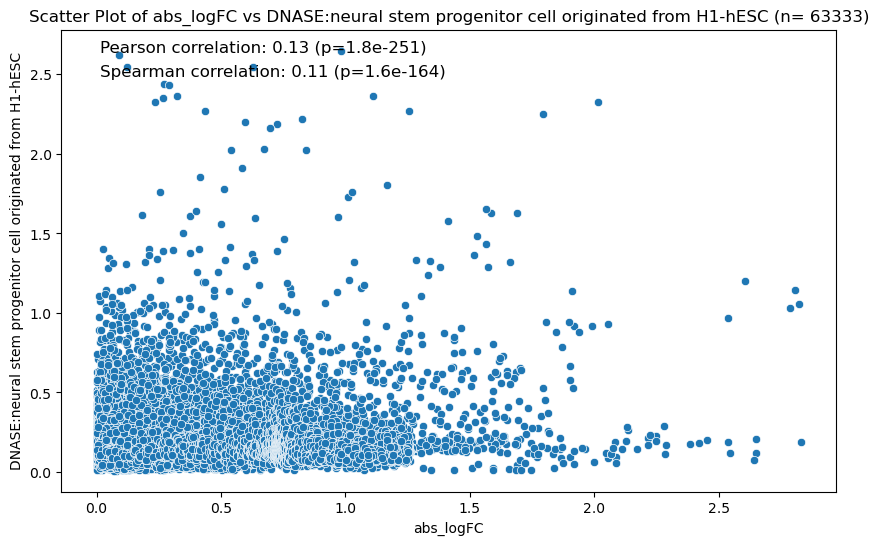

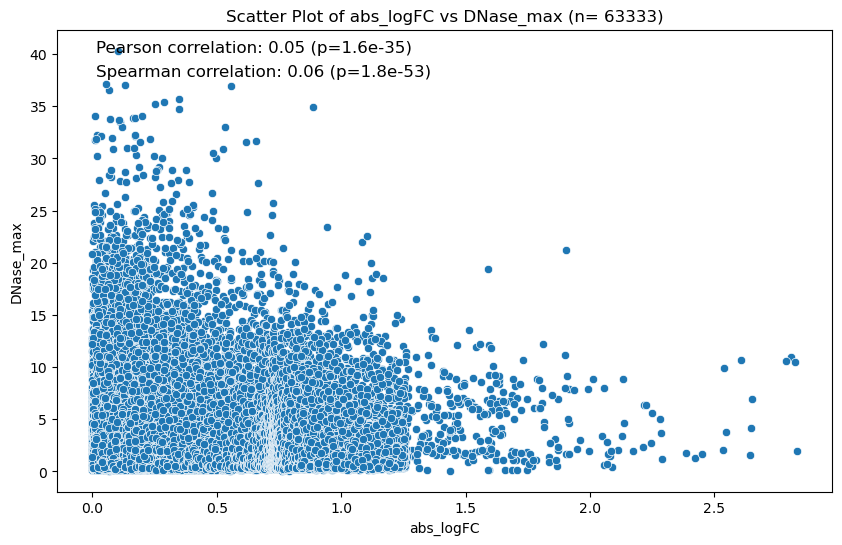

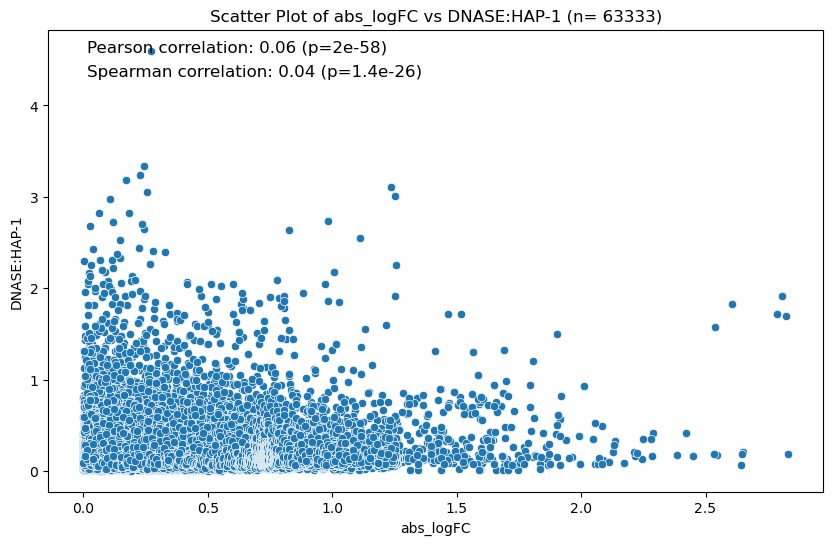

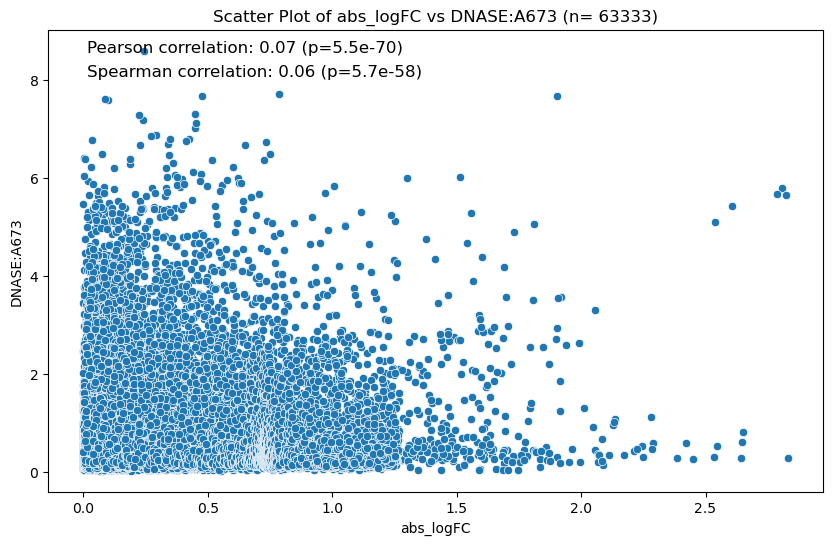

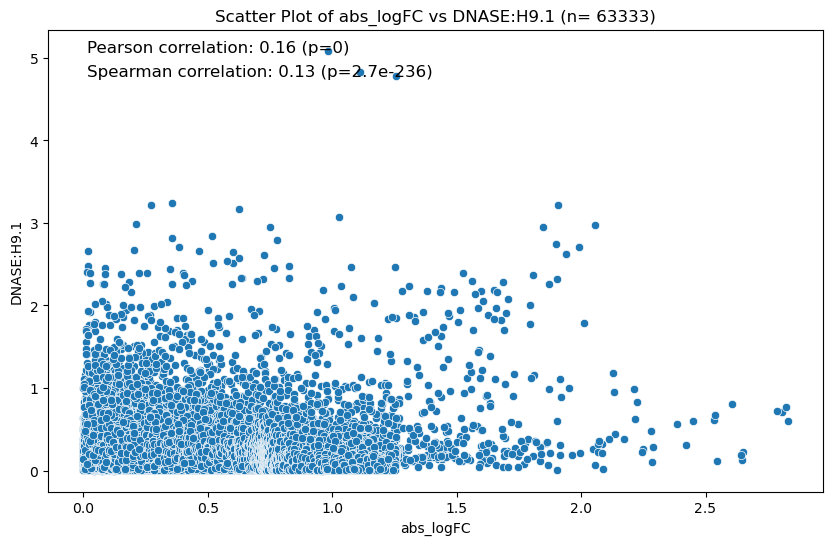

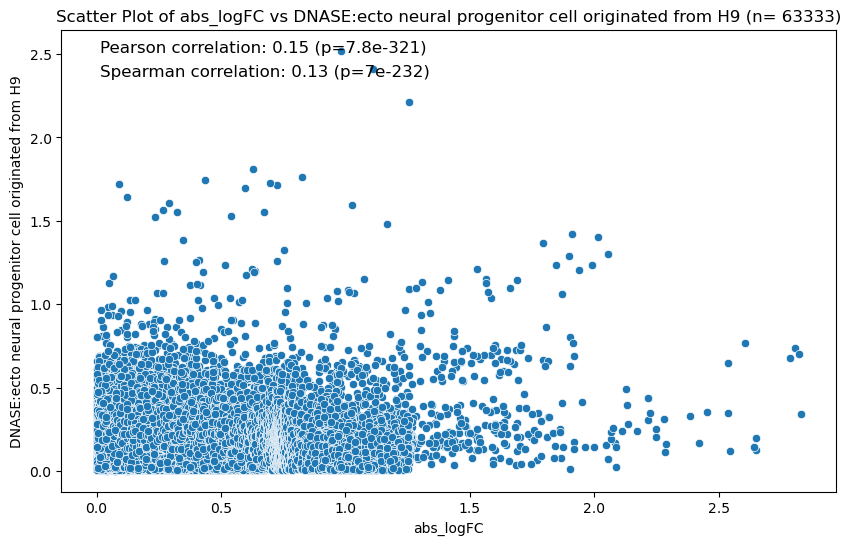

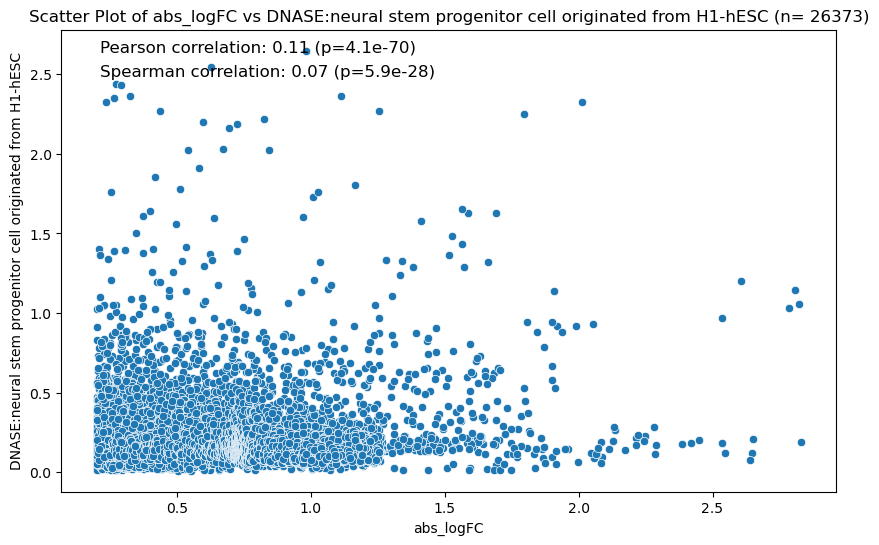

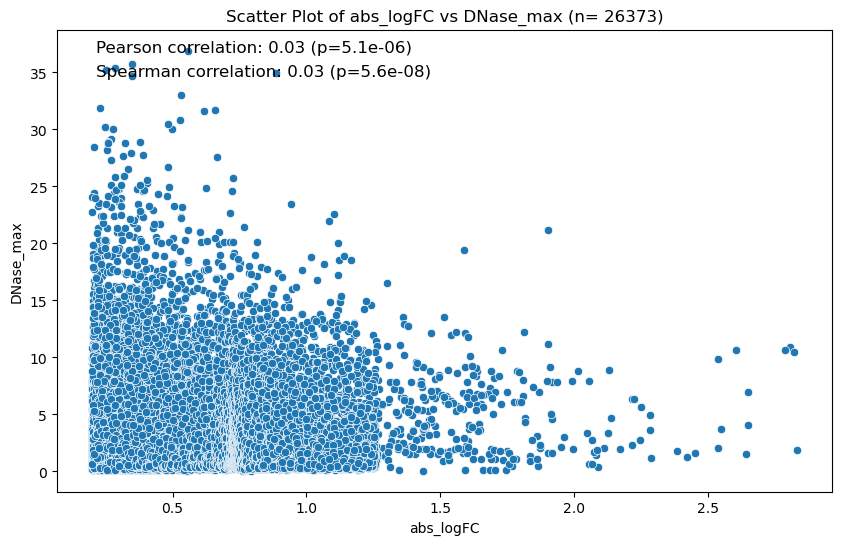

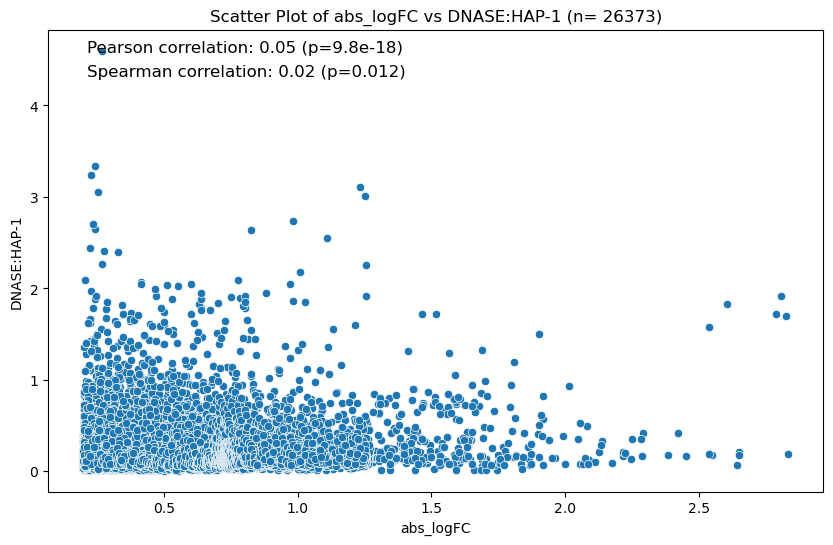

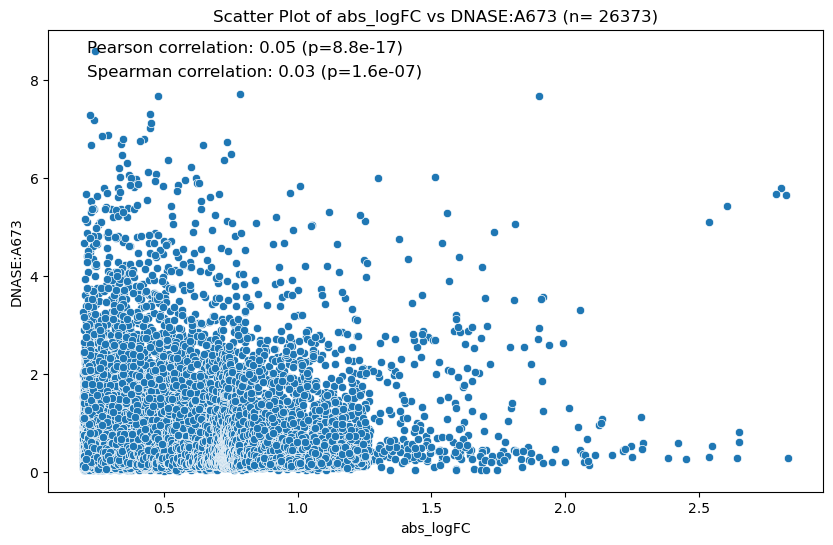

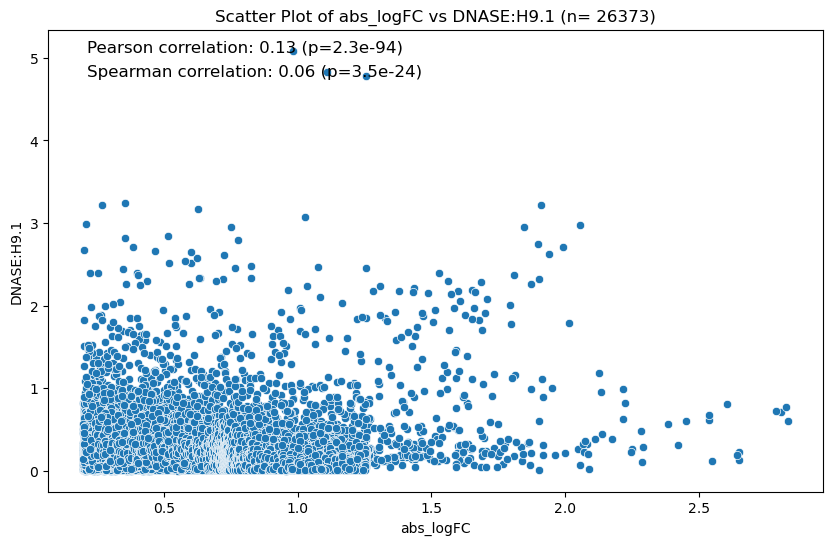

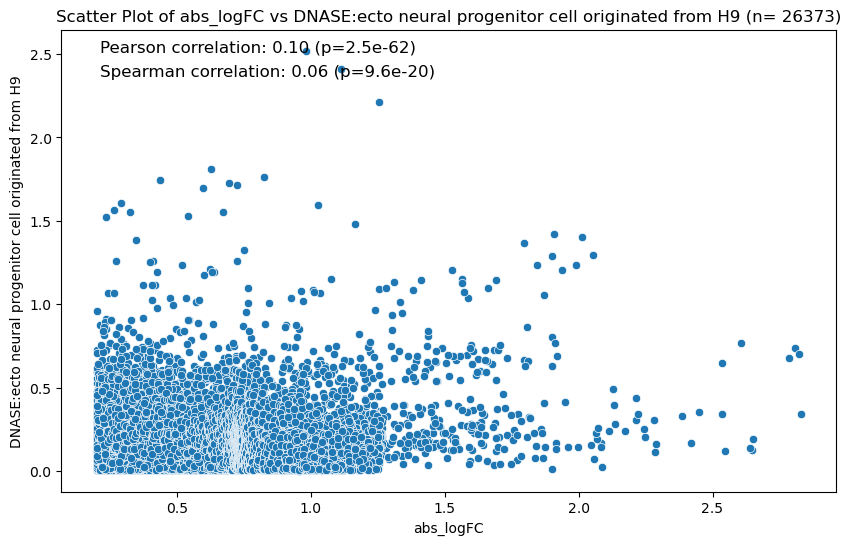

In [27]:

prediction_column_list = ['DNASE:neural stem progenitor cell originated from H1-hESC', 'DNase_max', 'DNASE:HAP-1', 'DNASE:A673', 'DNASE:H9.1', 'DNASE:ecto neural progenitor cell originated from H9'] # ['DNASE:neural stem progenitor cell originated from H1-hESC', 'DNase_max']
element_dfs = [bcalm_elements_merged]
measured_column = ['abs_logFC']# 'abs_logFC', 'logFC' with abs_logFC: absolute values of measurements vs DNase values
for col1 in measured_column:
    for df in element_dfs:
        # predictions comparison on full element set:
        for col2 in prediction_column_list:
            scatter_plot_of_prediction_measured_correlation(df, col1=col1, col2=col2)

        df_high_activity = df.loc[df[col1] >= 0.2]
        for col2 in prediction_column_list:
            scatter_plot_of_prediction_measured_correlation(df_high_activity, col1=col1, col2=col2)
        if 'abs' in col1:
            continue
        df_low_activity = df.loc[df[col1] <= 0]
        for col2 in prediction_column_list:
            scatter_plot_of_prediction_measured_correlation(df_low_activity, col1=col1, col2=col2)


## what has the highest correlation of the columns?

#### Focus on only elements: Plot all the combinations of all elements and their predictions for DNASE

In [38]:
bcalm_all_merged_elements.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'name', 'abs_logFC',
       'tmp_screen_region', 'ID', 'DNase_max',
       ...
       'DNASE:inferior parietal cortex male adult (84 years)',
       'DNASE:kidney capillary endothelial cell female embryo (113 days)',
       'DNASE:placenta male embryo (91 day)',
       'DNASE:right kidney male embryo (115 days)',
       'DNASE:coronary artery female adult (51 year)',
       'ATAC:BM0106-Day0-MCP-A / Bone Marrow CD34+ / pDC',
       'ATAC:BM0106-UNK-ATAC-2 / Bone Marrow CD34+ / UNK',
       'ATAC:BM0828-MEGA1-A-151109 / Bone Marrow CD34+ / Mega',
       'ATAC:BM1077-MCP / Bone Marrow CD34+ / pDC',
       'ATAC:BM1077-UNK / Bone Marrow CD34+ / UNK'],
      dtype='object', length=690)

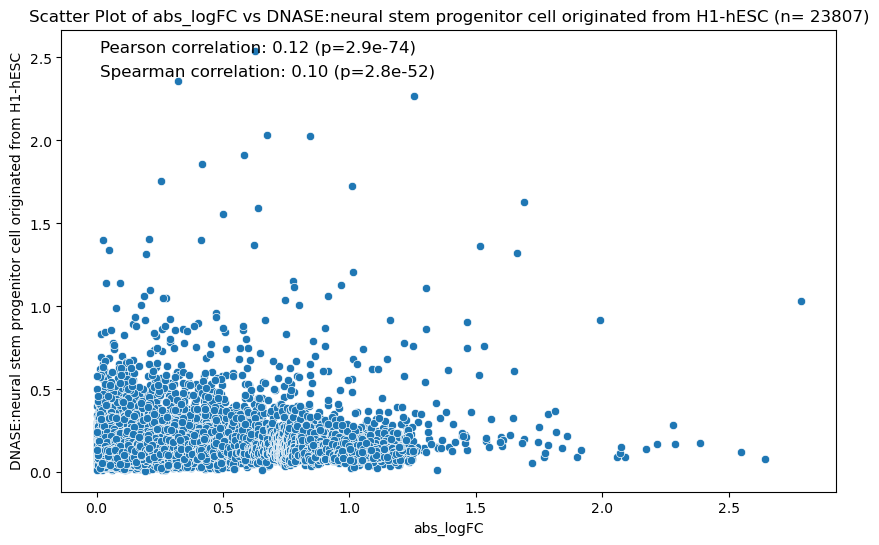

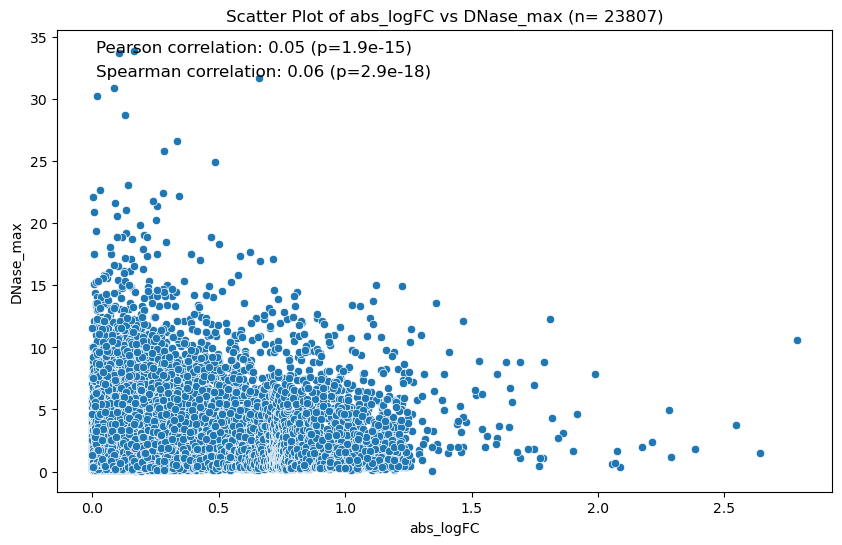

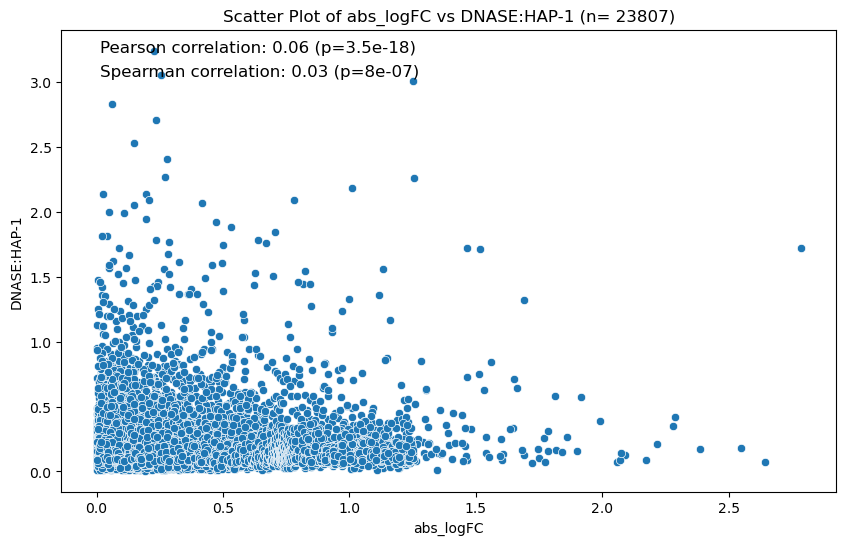

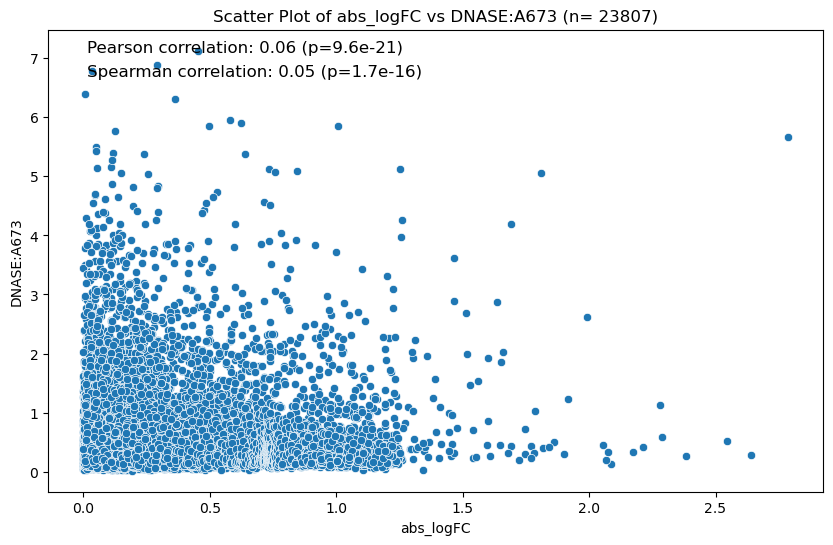

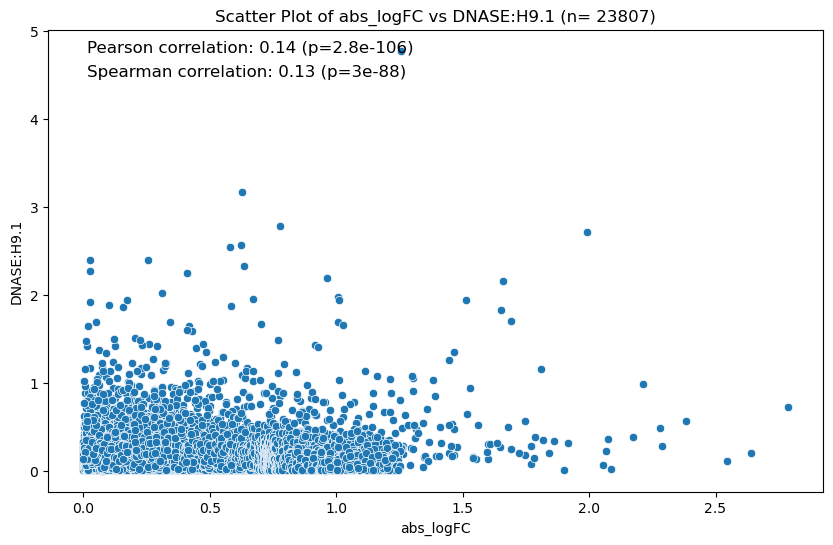

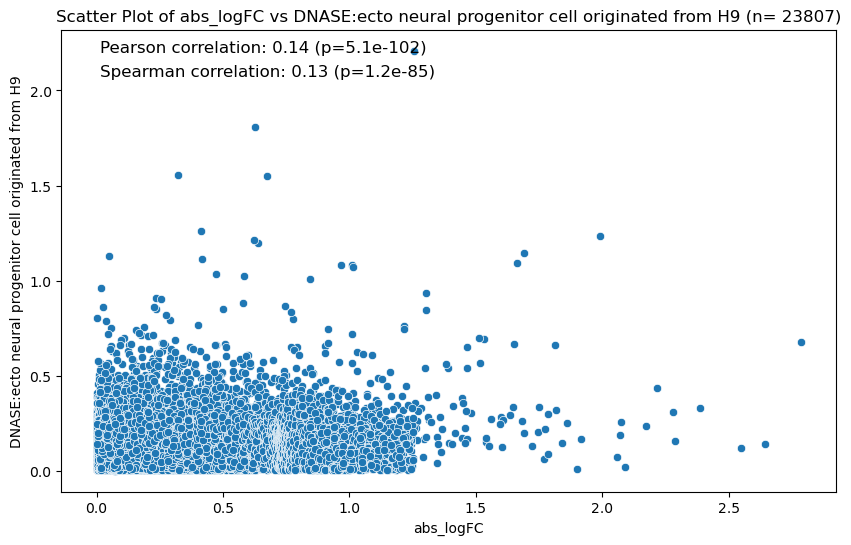

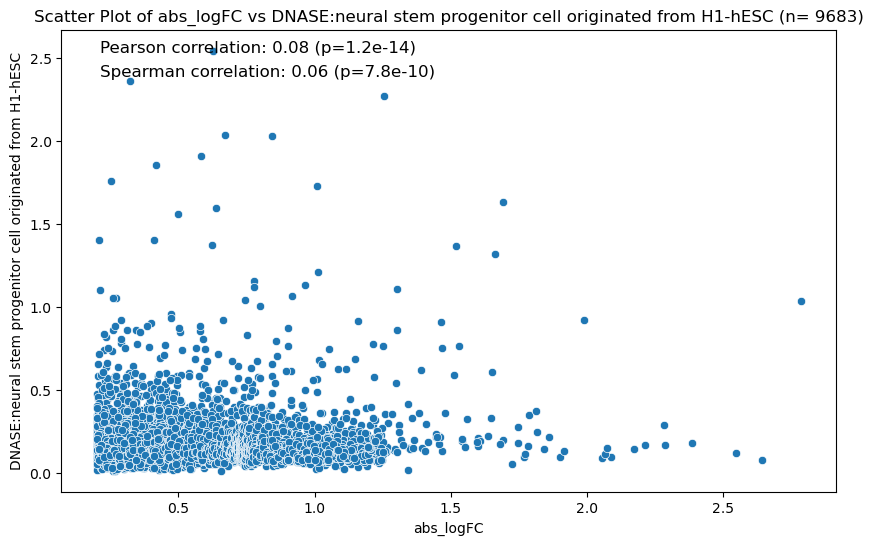

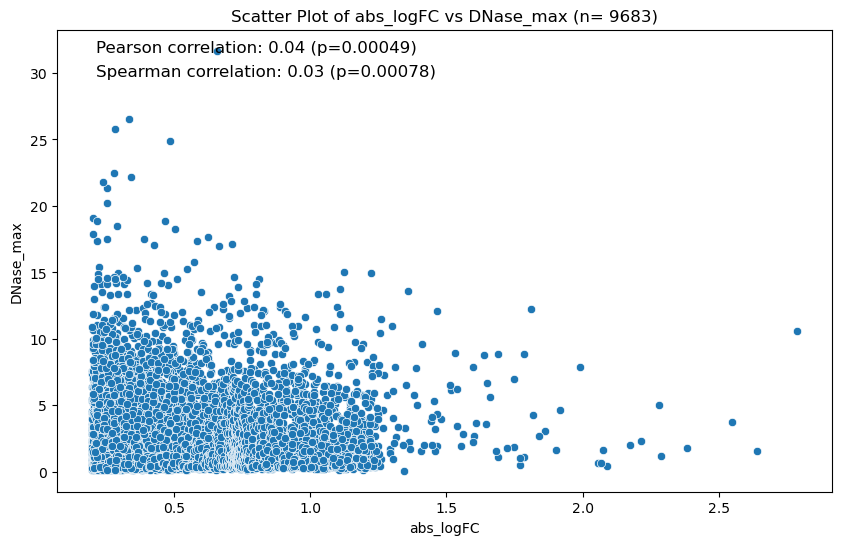

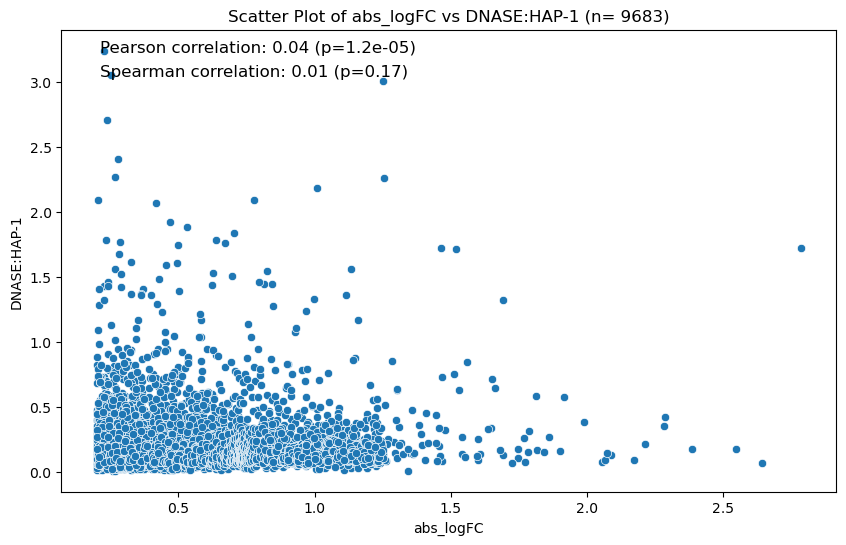

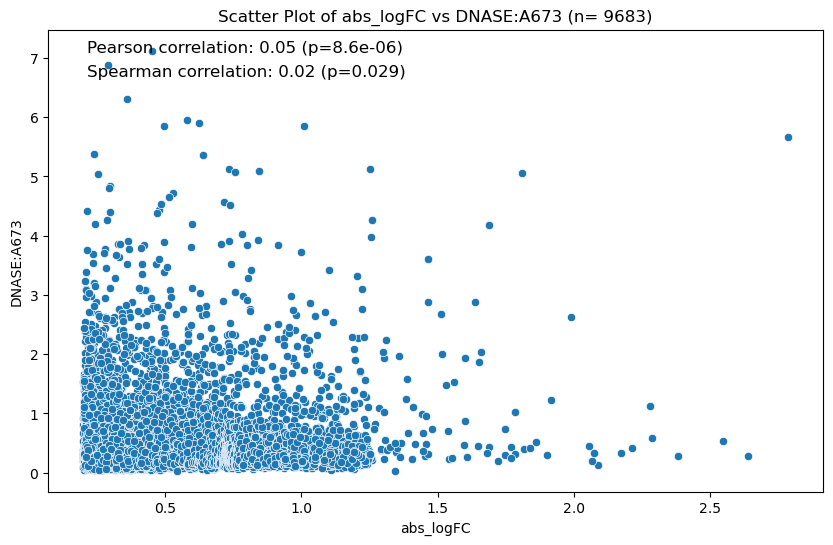

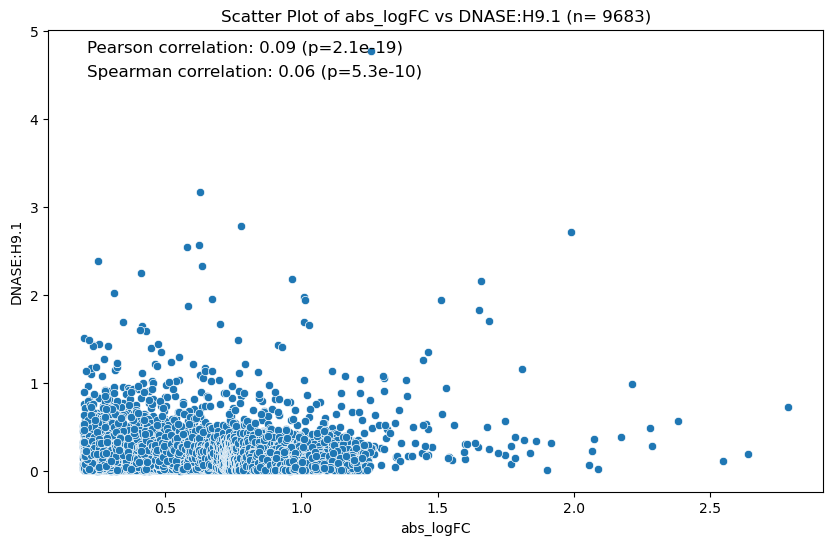

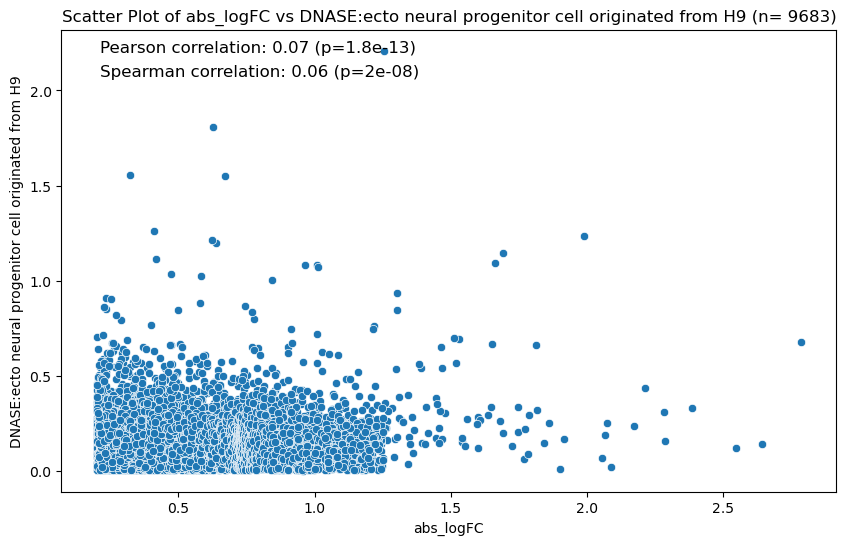

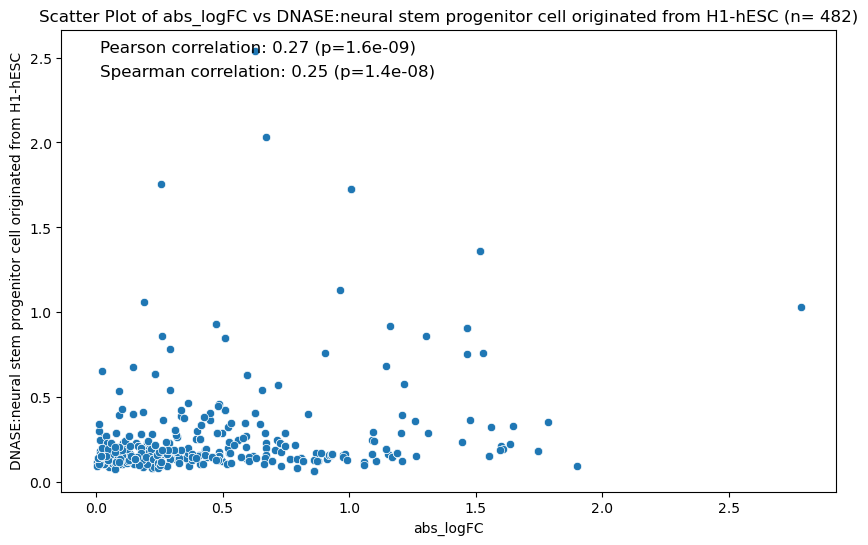

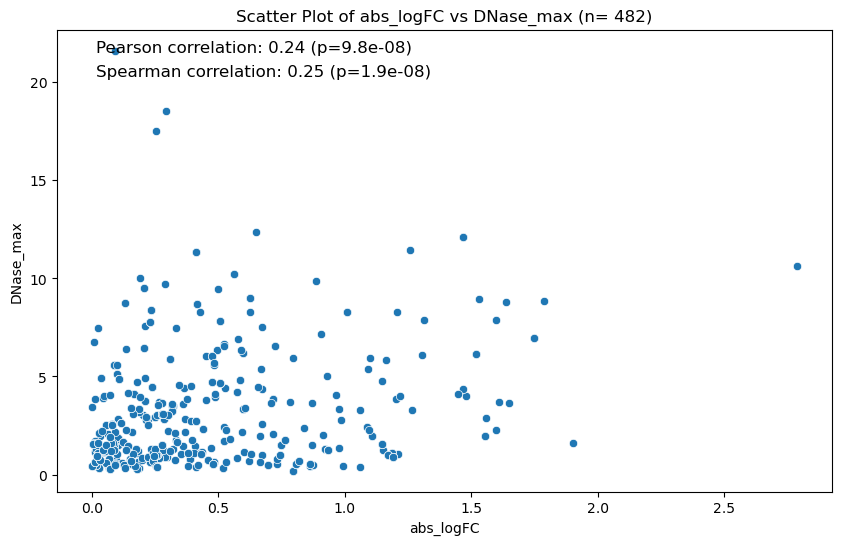

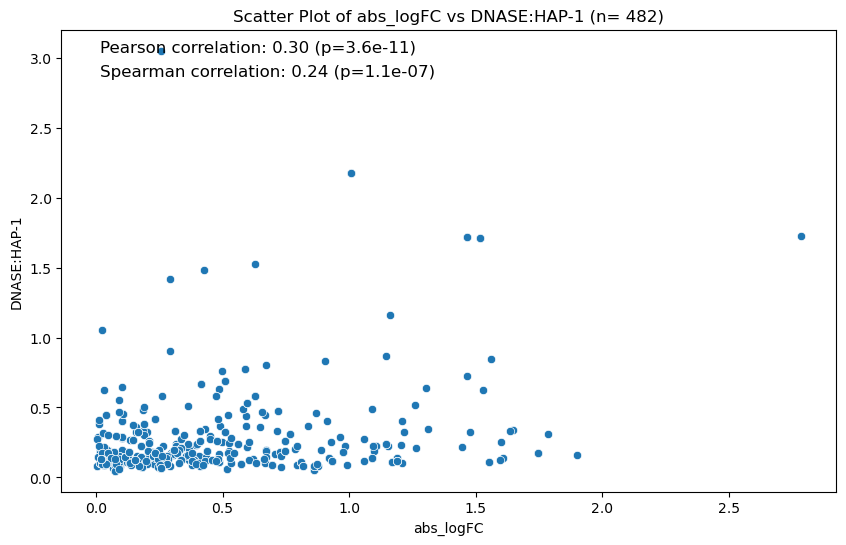

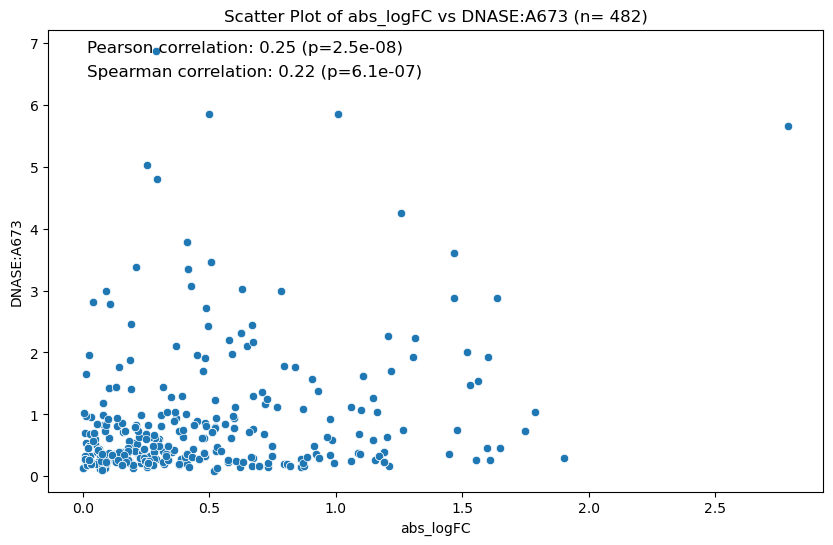

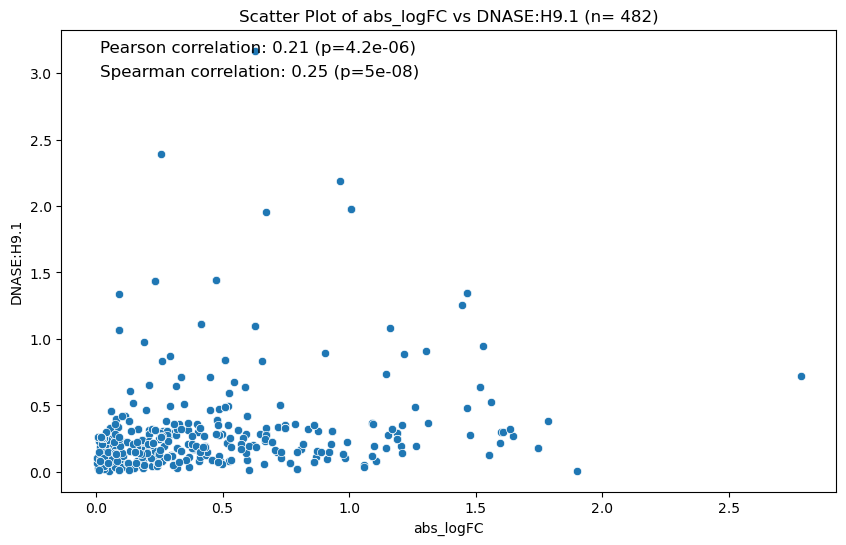

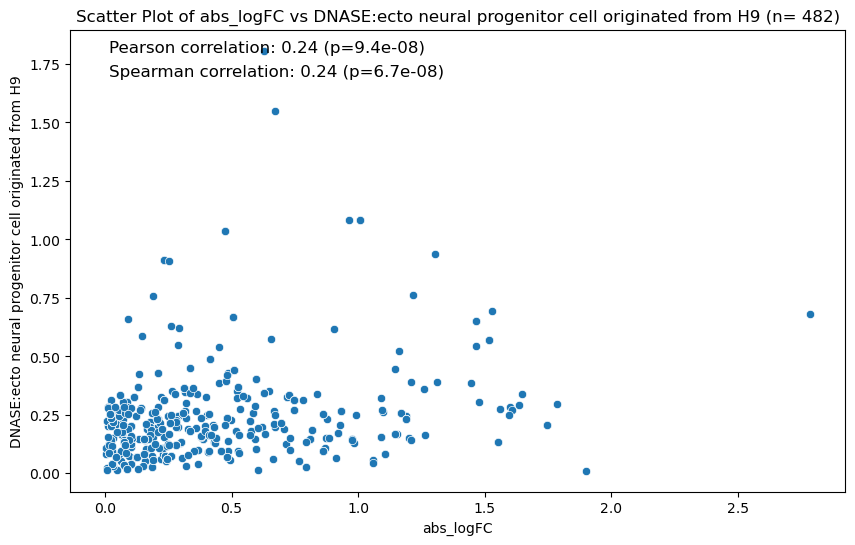

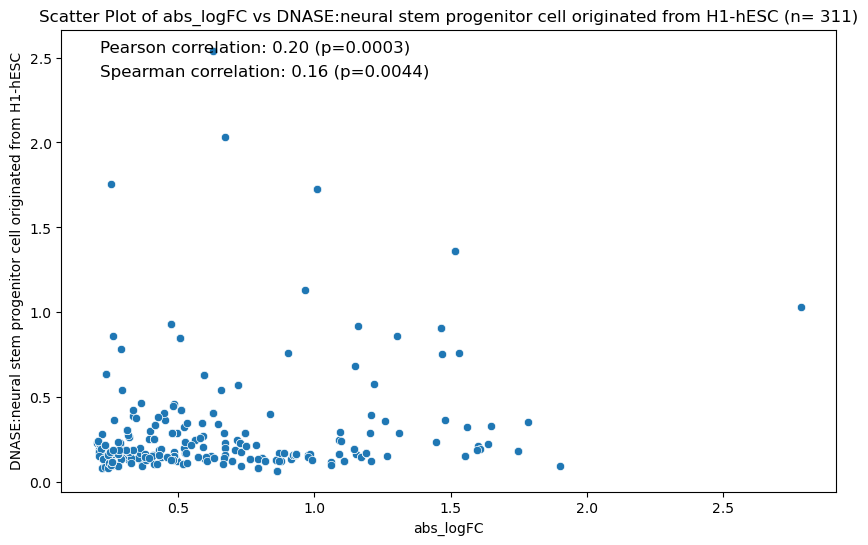

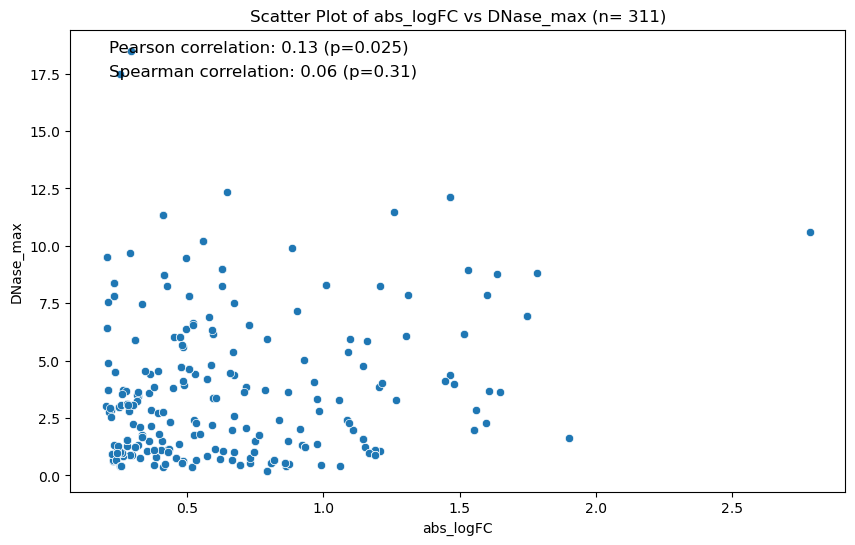

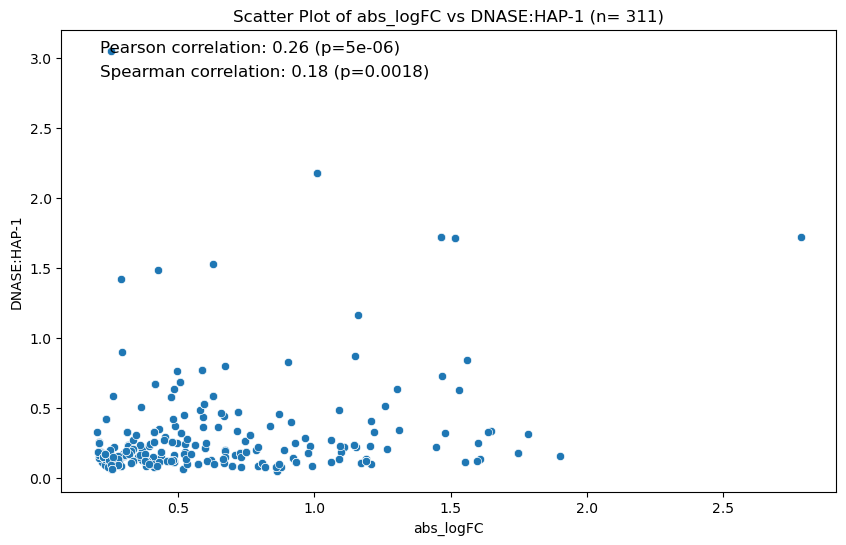

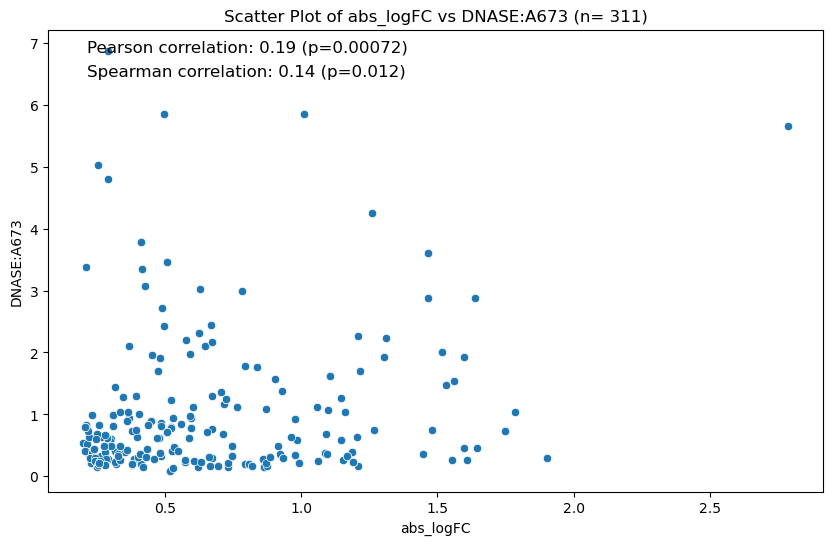

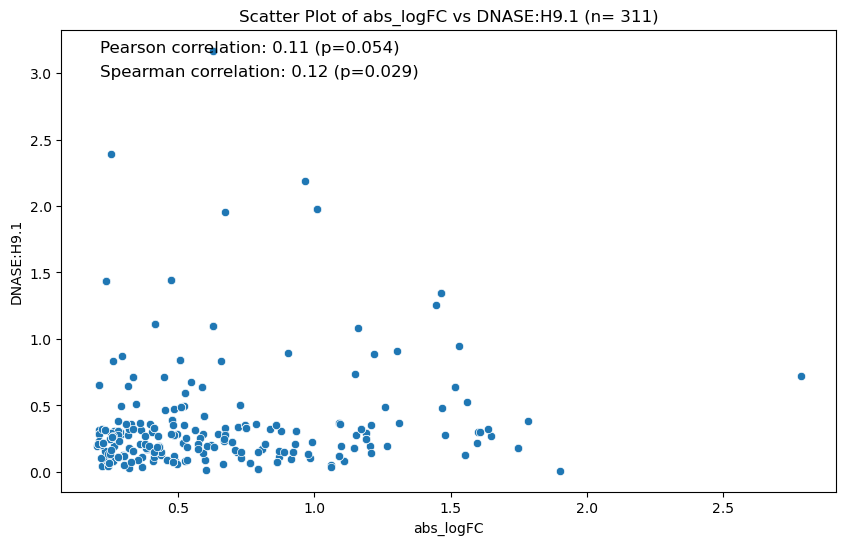

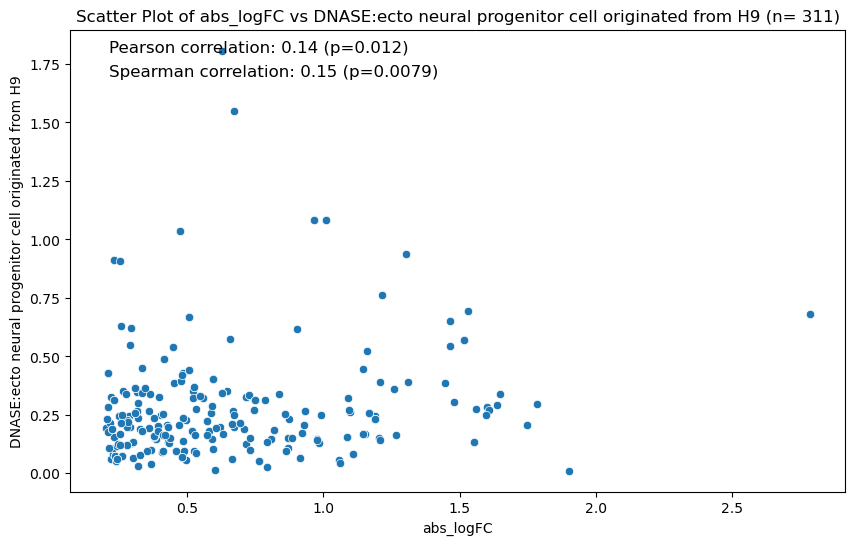

In [ ]:

prediction_column_list = ['DNASE:neural stem progenitor cell originated from H1-hESC', 'DNase_max', 'DNASE:HAP-1', 'DNASE:A673', 'DNASE:H9.1', 'DNASE:ecto neural progenitor cell originated from H9'] # ['DNASE:neural stem progenitor cell originated from H1-hESC', 'DNase_max']
element_dfs = [bcalm_all_merged_elements, bcalm_open_merged_elements]
measured_column = ['abs_logFC']# 'abs_logFC', 'logFC' with abs_logFC: absolute values of measurements vs DNase values
for col1 in measured_column:
    for df in element_dfs:
        # predictions comparison on full element set:
        for col2 in prediction_column_list:
            scatter_plot_of_prediction_measured_correlation(df, col1=col1, col2=col2)

        df_high_activity = df.loc[df[col1] >= 0.2]
        for col2 in prediction_column_list:
            scatter_plot_of_prediction_measured_correlation(df_high_activity, col1=col1, col2=col2)
        if 'abs' in col1:
            continue
        df_low_activity = df.loc[df[col1] <= 0]
        for col2 in prediction_column_list:
            scatter_plot_of_prediction_measured_correlation(df_low_activity, col1=col1, col2=col2)


## what has the highest correlation of the columns?


#### Less plotting compute the correlations and get the top correlating columns

In [25]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

def top_correlations(data_df, target_col, method='pearson', top_n=3):
    """
    Finds the top N columns with the highest correlation to a given column.

    Parameters:
        data_df (pd.DataFrame): The input DataFrame.
        target_col (str): The column to compare against.
        method (str): Correlation method ('pearson' or 'spearman').
        top_n (int): Number of top correlating columns to return.

    Returns:
        pd.DataFrame: DataFrame containing the top N correlating columns and their correlations.
    """
    correlations = []

    for col in data_df.columns:
        if col == target_col:
            continue

        # Handle NaN values by dropping them pairwise
        pair_df = data_df[[target_col, col]].dropna()

        if method == 'pearson':
            corr, _ = pearsonr(pair_df[target_col], pair_df[col])
        elif method == 'spearman':
            corr, _ = spearmanr(pair_df[target_col], pair_df[col])
        else:
            raise ValueError("Invalid method. Choose 'pearson' or 'spearman'.")

        correlations.append((col, corr))

    # Sort by correlation value and select top N
    sorted_correlations = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)[:top_n]

    return pd.DataFrame(sorted_correlations, columns=['Column', 'Correlation'])

# Example usage:
# Assume bcalm_all_merged_elements is your DataFrame and 'col1' is the target column.
# remove unused columns:
not_necessary_cols = ['AveExpr', 't', 'P.Value', 'adj.P.Val', 'name', 'abs_logFC', 'tmp_screen_region', 'ID']
not_necessary_cols = ['AveExpr', 't', 'P.Value', 'adj.P.Val', 'name', 'logFC', 'tmp_screen_region', 'ID']
# top_3_all = top_correlations(bcalm_all_merged_elements.drop(columns=not_necessary_cols), 'logFC', method='spearman', top_n=3) # DNASE:HAP-1 0.1279
top_3_all = top_correlations(bcalm_all_merged_elements.drop(columns=not_necessary_cols), 'abs_logFC', method='spearman', top_n=3)
top_3_all.Column.to_list()
# using absolute values:
# DNASE:H9.1	0.128543
# DNASE:ecto neural progenitor cell originated from H9	0.126597
# DNASE:islet precursor cell	0.126490

['DNASE:H9.1',
 'DNASE:ecto neural progenitor cell originated from H9',
 'DNASE:islet precursor cell']

In [26]:
# all elements best correlation:
top_3_with_alt = top_correlations(bcalm_elements_merged.drop(columns=not_necessary_cols), 'abs_logFC', method='spearman', top_n=3)
top_3_with_alt

,Column,Correlation
0,DNASE:H9.1,0.129877
1,DNASE:ecto neural progenitor cell originated f...,0.128659
2,DNASE:endodermal cell,0.126484


In [64]:
top_3_open_neuro = top_correlations(bcalm_open_merged_elements.drop(columns=not_necessary_cols + ['is_open_ngn2_wtc11']), 'logFC', method='spearman', top_n=3)
top_3_open_neuro # DNASE:WERI-Rb-1 # 0.394681
top_3_open_neuro['Column'].to_list()

['DNASE:WERI-Rb-1',
 'DNASE:SK-N-DZ treated with dimethyl sulfoxide for 72 hours',
 'DNASE:bipolar neuron originated from GM23338 treated with 0.5 ug/mL doxycycline hyclate for 4 days']

In [50]:
from collections import defaultdict
def get_gene_lookup_dict(gene_lists, gene_list_dir='/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists'):
    """
    prepare a dict which has gene_name: (list of associated gene_sets)
    :gene_lists - list of files containing gene names and have useful names
    """
    gene_lookup_dict = defaultdict(list)
    for file in gene_lists:
        with open(os.path.join(gene_list_dir, file), 'r') as f:
            gene_list = f.read().splitlines()
            gene_list_name = file.split('.')[0]
            for gene in gene_list:
                gene_lookup_dict[gene].append(gene_list_name)
    return gene_lookup_dict

In [55]:
# for cardiac specific sequences
# get gene_list files:
gene_list_dir = '/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists'
gene_lists = [file for file in os.listdir(gene_list_dir) if '.txt' in file]

# prepare a dict which has gene_name: (tuple of associated gene_sets)
gene_lookup_dict = get_gene_lookup_dict(gene_lists=gene_lists, gene_list_dir=gene_list_dir)

# get gene set
bcalm_all_merged_elements['tmp_gene_name'] = bcalm_all_merged_elements['name'].apply(lambda name: hf.get_gene_name(name, with_controls=False))
bcalm_all_merged_elements['tmp_gene_set'] = bcalm_all_merged_elements['tmp_gene_name'].apply(lambda gene: gene_lookup_dict[gene])
bcalm_all_merged_elements['tmp_gene_set'].value_counts()
#! remember adding these columns to not_necessary_cols (tmp_gene_name, tmp_gene_set)

/tmp/ipykernel_322592/1877965755.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bcalm_all_merged_elements['tmp_gene_name'] = bcalm_all_merged_elements['name'].apply(lambda name: hf.get_gene_name(name, with_controls=False))
/tmp/ipykernel_322592/1877965755.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bcalm_all_merged_elements['tmp_gene_set'] = bcalm_all_merged_elements['tmp_gene_name'].apply(lambda gene: gene_lookup_dict[gene])


tmp_gene_set
[neuro]             14193
[cardiac]            6558
[cava]               1467
[neuro, cardiac]      702
[random]              653
[neuro, cava]         141
[cava, cardiac]        93
Name: count, dtype: int64

In [56]:
# filter for specific gene group:
cardiac_bcalm_all_merged_elements = bcalm_all_merged_elements.loc[bcalm_all_merged_elements['tmp_gene_set'].apply(lambda gene_group: hf.is_element_of(gene_group, 'cardiac'))]
neuro_bcalm_all_merged_elements = bcalm_all_merged_elements.loc[bcalm_all_merged_elements['tmp_gene_set'].apply(lambda gene_group: hf.is_element_of(gene_group, 'neuro'))]
cava_bcalm_all_merged_elements = bcalm_all_merged_elements.loc[bcalm_all_merged_elements['tmp_gene_set'].apply(lambda gene_group: hf.is_element_of(gene_group, 'cava'))]
random_bcalm_all_merged_elements = bcalm_all_merged_elements.loc[bcalm_all_merged_elements['tmp_gene_set'].apply(lambda gene_group: hf.is_element_of(gene_group, 'random'))]

In [58]:
print(cardiac_bcalm_all_merged_elements.shape[0])
print(neuro_bcalm_all_merged_elements.shape[0])
print(cava_bcalm_all_merged_elements.shape[0])
print(random_bcalm_all_merged_elements.shape[0])

7353
15036
1701
653


In [ ]:
# cardiac
# remove unused columns:
not_necessary_cols = ['AveExpr', 't', 'P.Value', 'adj.P.Val', 'name', 'abs_logFC', 'tmp_screen_region', 'ID']
top_3_cardiac = top_correlations(cardiac_bcalm_all_merged_elements.drop(columns=not_necessary_cols+ ['tmp_gene_name', 'tmp_gene_set']), 'logFC', method='spearman', top_n=3)
print(top_3_cardiac) # DNASE:HAP-1 0.143

,Column,Correlation
0,DNASE:HAP-1,0.143431
1,DNASE:SK-N-MC,0.126520
2,DNASE:A673,0.109539


In [ ]:
top_3_neuro = top_correlations(neuro_bcalm_all_merged_elements.drop(columns=not_necessary_cols+ ['tmp_gene_name', 'tmp_gene_set']), 'logFC', method='spearman', top_n=3)
print(top_3_neuro) # DNASE:HAP-1     0.126704

          Column  Correlation
0    DNASE:HAP-1     0.126704
1  DNASE:SK-N-MC     0.115999
2     DNASE:A673     0.108601


In [ ]:
top_3_cava = top_correlations(cava_bcalm_all_merged_elements.drop(columns=not_necessary_cols+ ['tmp_gene_name', 'tmp_gene_set']), 'logFC', method='spearman', top_n=3)
print(top_3_cava) # DNASE:A673     0.109410 DNASE:HAP-1 0.093233

          Column  Correlation
0     DNASE:A673     0.109410
1  DNASE:SK-N-MC     0.098128
2    DNASE:HAP-1     0.093233


In [62]:
top_3_random = top_correlations(random_bcalm_all_merged_elements.drop(columns=not_necessary_cols+ ['tmp_gene_name', 'tmp_gene_set']), 'logFC', method='spearman', top_n=3)
print(top_3_random)

                                              Column  Correlation
0      DNASE:omental fat pad female adult (53 years)    -0.159012
1          DNASE:Peyer's patch male adult (37 years)    -0.158354
2  DNASE:gastrocnemius medialis male adult (54 ye...    -0.156337


absolute values

In [73]:
not_necessary_cols = ['AveExpr', 't', 'P.Value', 'adj.P.Val', 'name', 'logFC', 'tmp_screen_region', 'ID']
top_3_cardiac = top_correlations(cardiac_bcalm_all_merged_elements.drop(columns=not_necessary_cols+ ['tmp_gene_name', 'tmp_gene_set']), 'abs_logFC', method='spearman', top_n=3)
print(top_3_cardiac)

                       Column  Correlation
0  DNASE:islet precursor cell     0.127409
1                  DNASE:H9.1     0.125739
2                DNASE:K562.3     0.123201


In [75]:
top_3_neuro = top_correlations(neuro_bcalm_all_merged_elements.drop(columns=not_necessary_cols+ ['tmp_gene_name', 'tmp_gene_set']), 'abs_logFC', method='spearman', top_n=3)
print(top_3_neuro)

                                              Column  Correlation
0                                         DNASE:H9.1     0.129079
1  DNASE:ecto neural progenitor cell originated f...     0.127709
2  DNASE:kidney embryo (59 days) and female embry...     0.126140


In [76]:
top_3_cava = top_correlations(cava_bcalm_all_merged_elements.drop(columns=not_necessary_cols+ ['tmp_gene_name', 'tmp_gene_set']), 'abs_logFC', method='spearman', top_n=3)
print(top_3_cava)

                                           Column  Correlation
0                      DNASE:islet precursor cell     0.137119
1  DNASE:breast epithelium female adult (51 year)     0.129617
2                DNASE:placenta embryo (102 days)     0.128410


In [74]:
top_3_random = top_correlations(random_bcalm_all_merged_elements.drop(columns=not_necessary_cols+ ['tmp_gene_name', 'tmp_gene_set']), 'abs_logFC', method='spearman', top_n=3)
print(top_3_random)

                                              Column  Correlation
0  DNASE:brain embryo (56 days) and male embryo (...     0.158706
1  DNASE:GM23338 male adult (53 years) originated...     0.157630
2                                    DNASE:H1-hESC.2     0.155841


In [92]:
# compare the correlations:
prediction_column_list = ['DNASE:neural stem progenitor cell originated from H1-hESC', 'DNase_max', 'DNASE:islet precursor cell', 'DNASE:H9.1'] # ['DNASE:neural stem progenitor cell originated from H1-hESC', 'DNase_max']
element_dfs = [cardiac_bcalm_all_merged_elements, neuro_bcalm_all_merged_elements, cava_bcalm_all_merged_elements, random_bcalm_all_merged_elements]
dataframe_names = ['cardiac_set', 'neuro_set', 'cava_set', 'random_set']
measured_column = ['abs_logFC']# 'abs_logFC', 'logFC' with abs_logFC: absolute values of measurements vs DNase values
# Initialize the DataFrame to store results
result_data = []

for col1 in measured_column:
    for i, df in enumerate(element_dfs):
        df_name = dataframe_names[i]  # Assign unique names to DataFrames
        # Correlation on the full dataset
        for col2 in prediction_column_list:
            corr = scatter_plot_of_prediction_measured_correlation(df, col1=col1, col2=col2, show_plot=False)
            result_data.append({
                'DataFrame': df_name,
                'Prediction_Column': col2,
                'Measured_Column': col1,
                'Subset': 'Full Dataset',
                'Correlation': corr
            })

        # Correlation on the high-activity subset
        df_high_activity = df.loc[df[col1] >= 0.2]
        for col2 in prediction_column_list:
            corr = scatter_plot_of_prediction_measured_correlation(df_high_activity, col1=col1, col2=col2, show_plot=False)
            result_data.append({
                'DataFrame': df_name,
                'Prediction_Column': col2,
                'Measured_Column': col1,
                'Subset': 'High Activity (>=0.2)',
                'Correlation': corr
            })

# Convert results into a DataFrame
correlation_df = pd.DataFrame(result_data)

# Display the correlation DataFrame
correlation_df

pivot_df = correlation_df.pivot_table(
    index=['Prediction_Column', 'Subset'],
    columns='DataFrame',
    values='Correlation'
).reset_index()
pivot_df

DataFrame,Prediction_Column,Subset,cardiac_set,cava_set,neuro_set,random_set
0,DNASE:H9.1,Full Dataset,0.126,0.120,0.129,0.123
1,DNASE:H9.1,High Activity (>=0.2),0.048,-0.018,0.067,0.268
2,DNASE:islet precursor cell,Full Dataset,0.127,0.137,0.124,0.109
3,DNASE:islet precursor cell,High Activity (>=0.2),0.052,-0.001,0.066,0.221
4,DNASE:neural stem progenitor cell originated f...,Full Dataset,0.083,0.102,0.102,0.140
5,DNASE:neural stem progenitor cell originated f...,High Activity (>=0.2),0.038,0.026,0.071,0.161
6,DNase_max,Full Dataset,0.057,0.071,0.054,0.084
7,DNase_max,High Activity (>=0.2),0.036,0.041,0.028,0.030


DataFrame,Prediction_Column,Subset,DataFrame_1,DataFrame_2,DataFrame_3,DataFrame_4
0,DNASE:H9.1,Full Dataset,0.126,0.129,0.120,0.123
1,DNASE:H9.1,High Activity (>=0.2),0.048,0.067,-0.018,0.268
2,DNASE:islet precursor cell,Full Dataset,0.127,0.124,0.137,0.109
3,DNASE:islet precursor cell,High Activity (>=0.2),0.052,0.066,-0.001,0.221
4,DNASE:neural stem progenitor cell originated f...,Full Dataset,0.083,0.102,0.102,0.140
5,DNASE:neural stem progenitor cell originated f...,High Activity (>=0.2),0.038,0.071,0.026,0.161
6,DNase_max,Full Dataset,0.057,0.054,0.071,0.084
7,DNase_max,High Activity (>=0.2),0.036,0.028,0.041,0.030


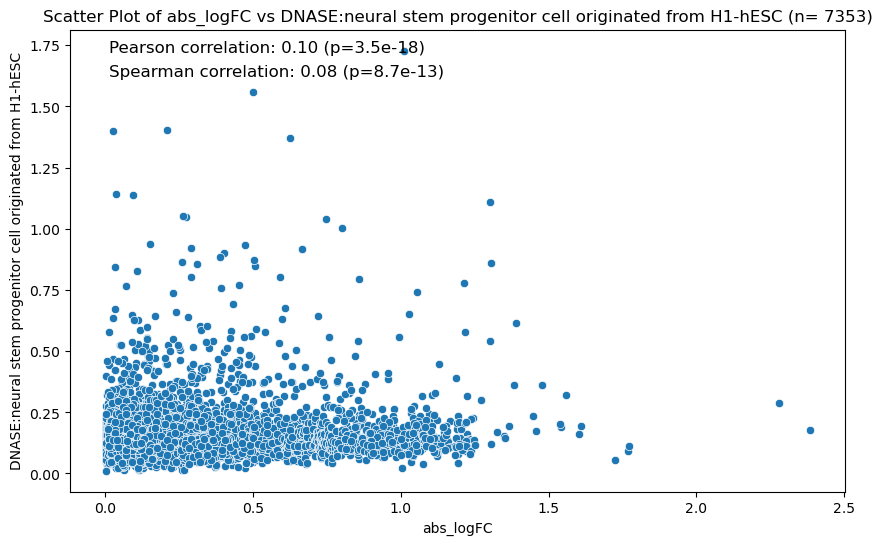

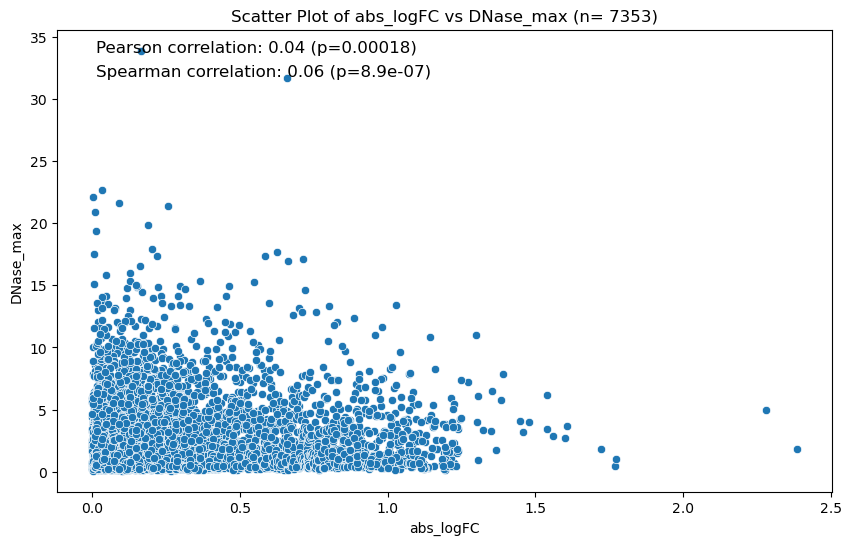

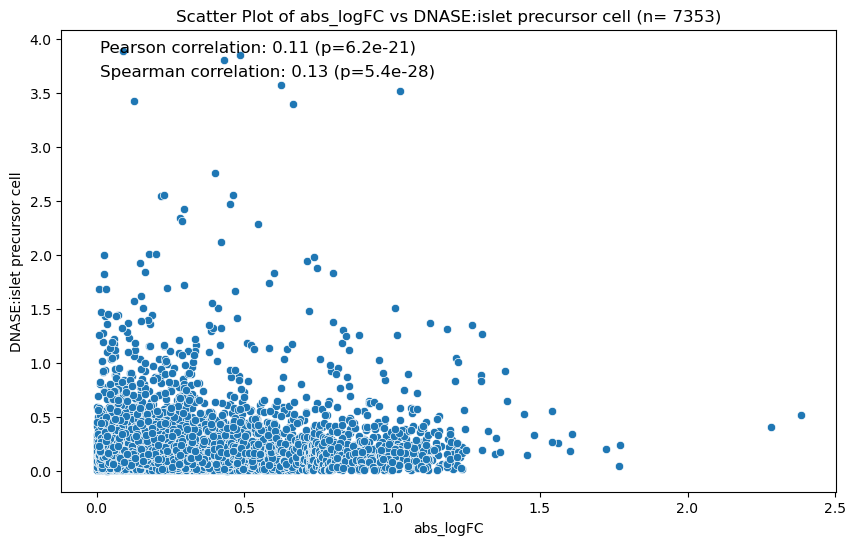

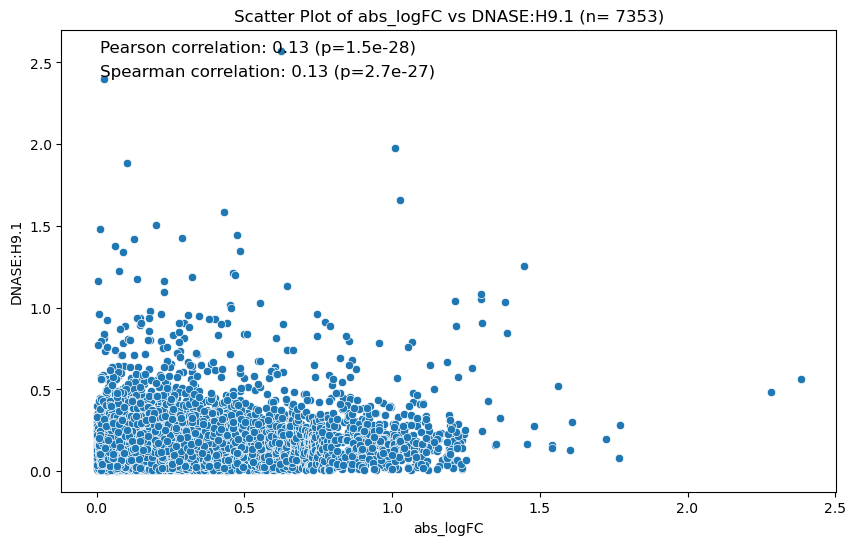

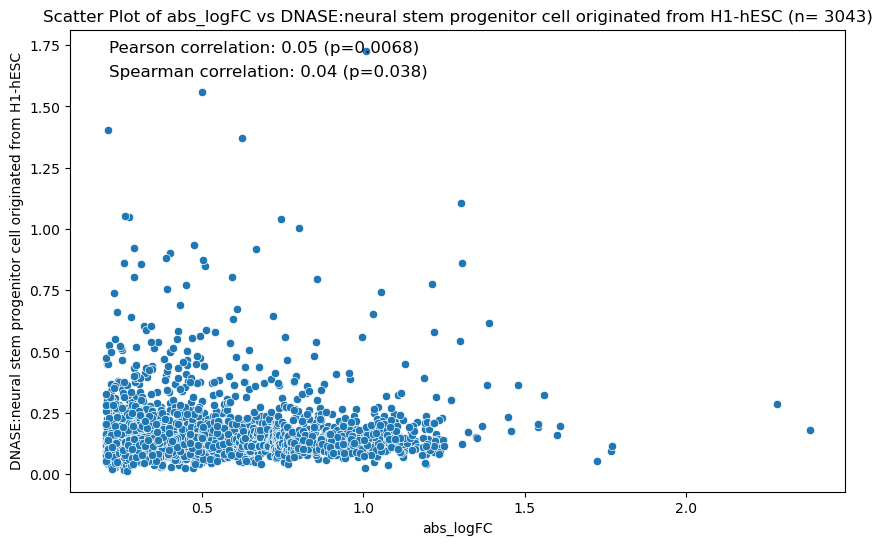

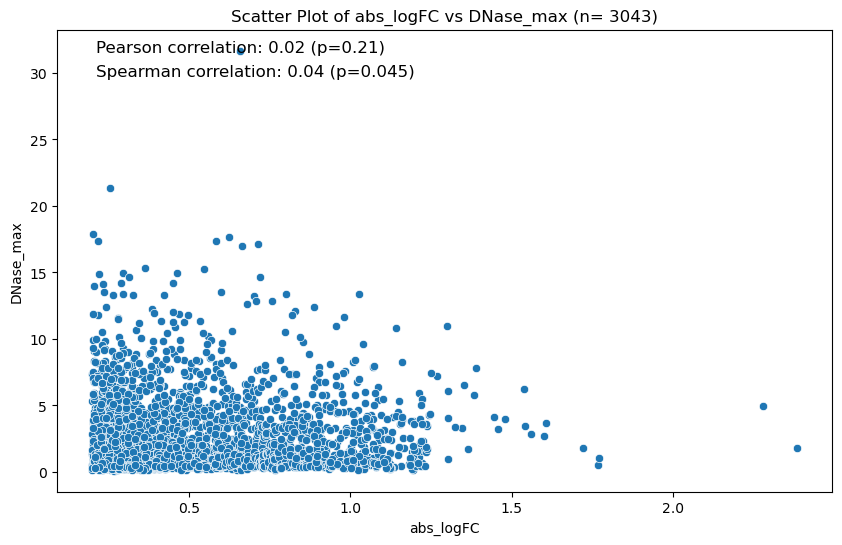

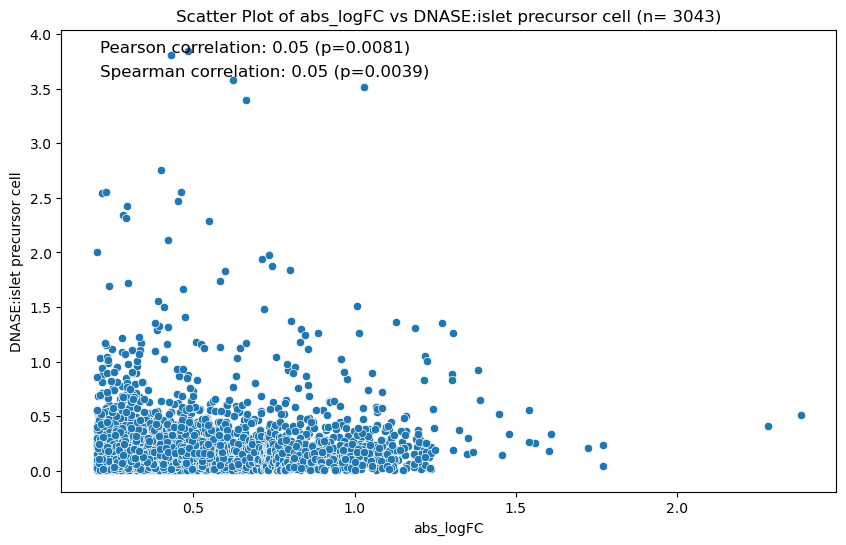

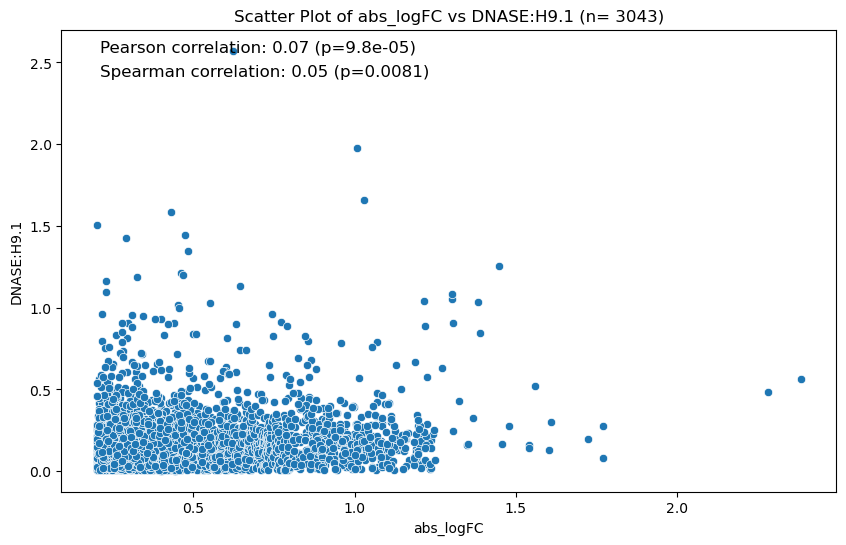

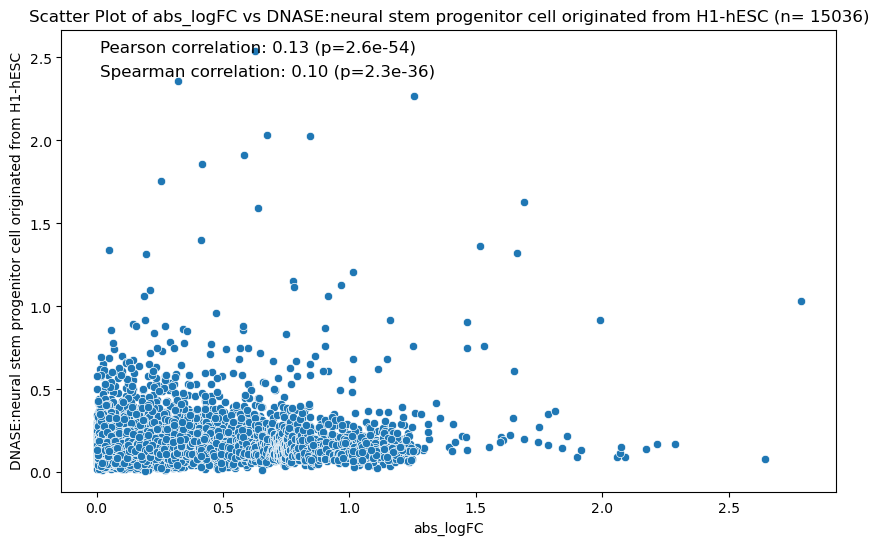

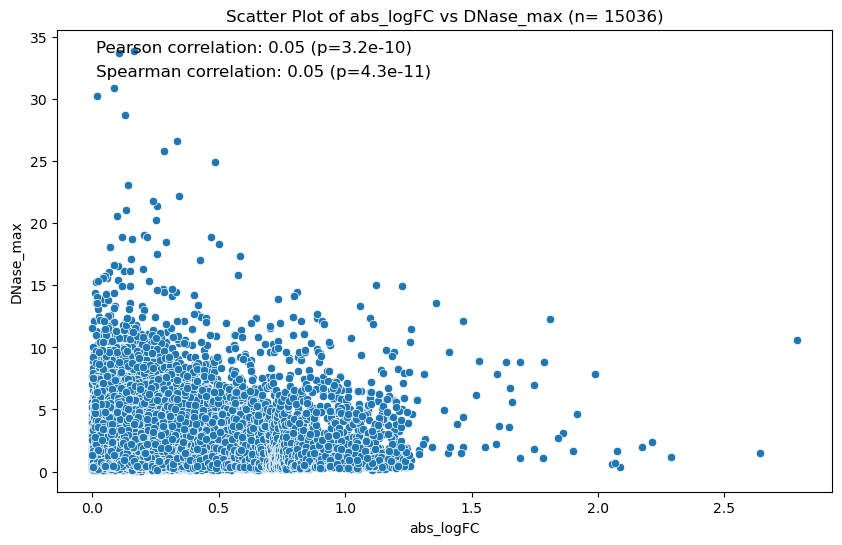

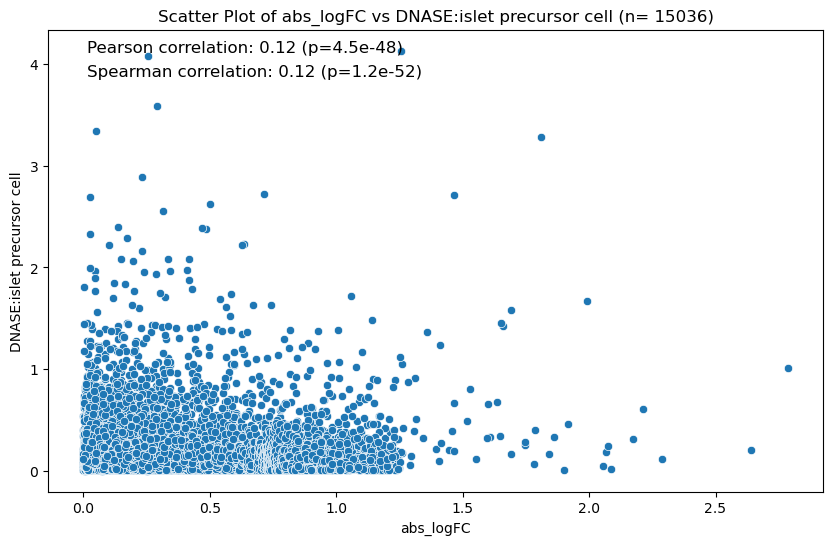

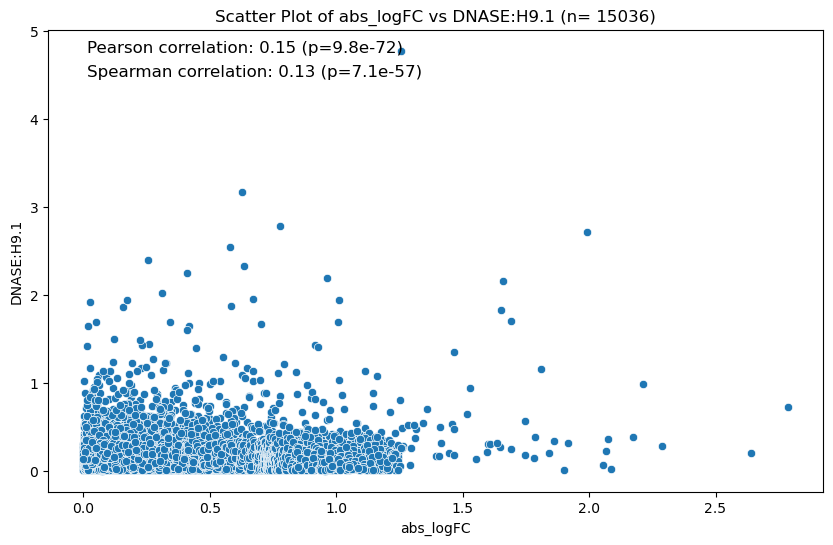

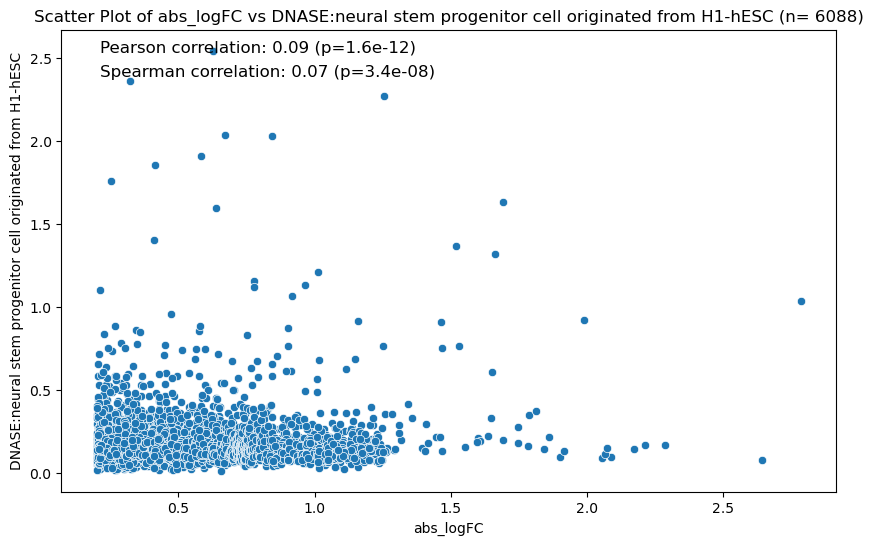

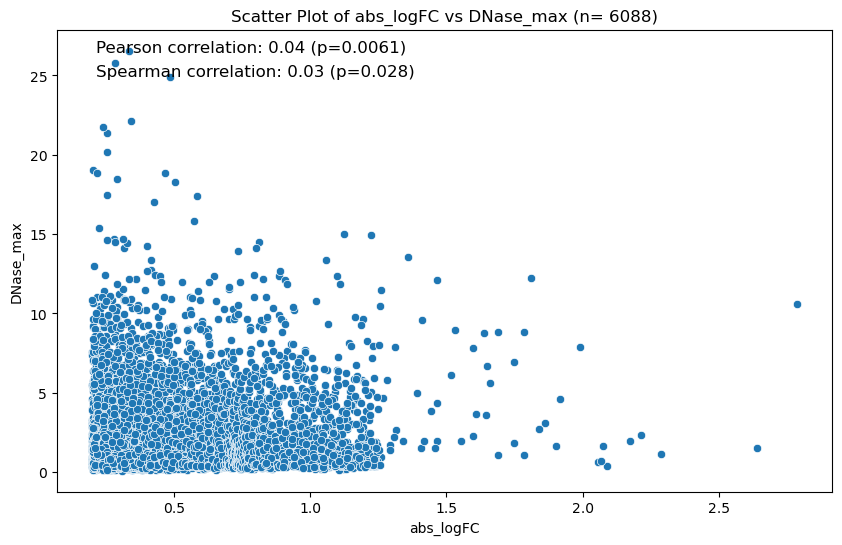

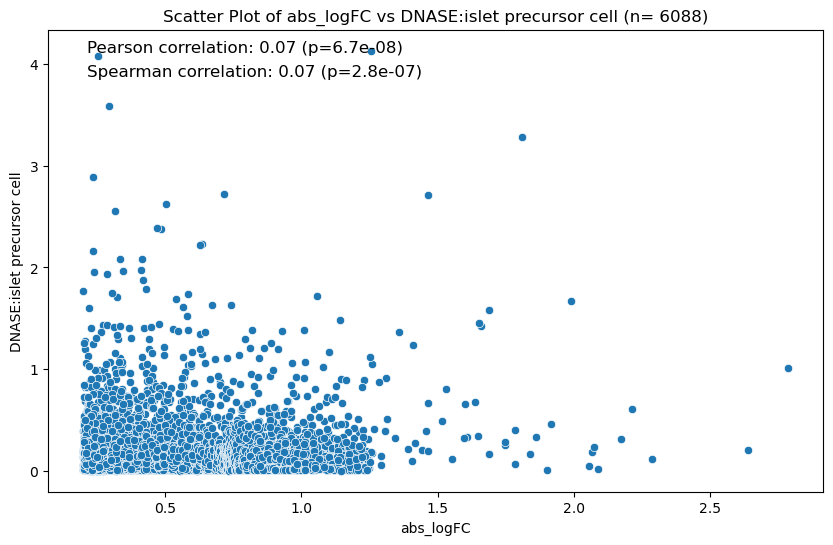

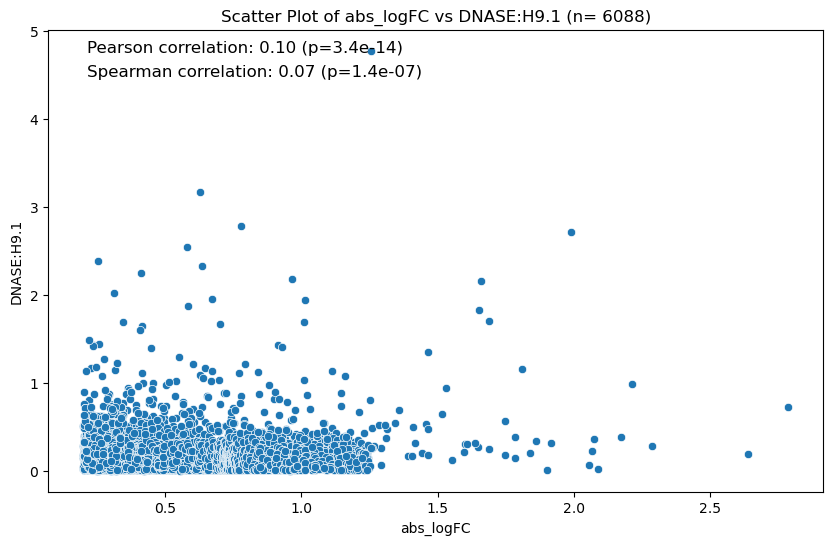

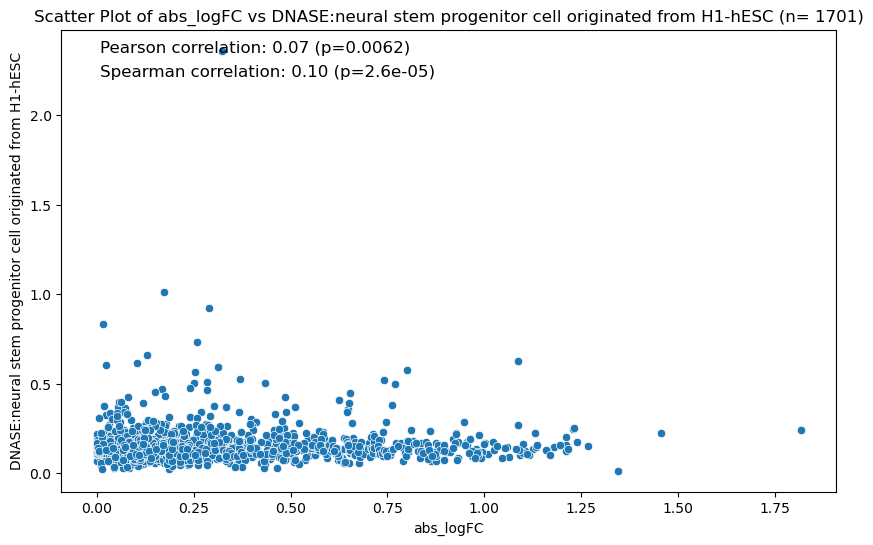

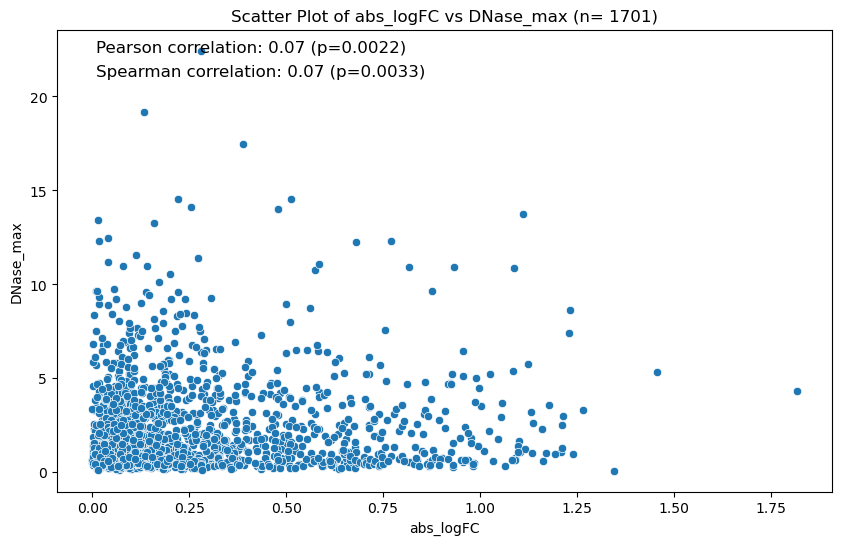

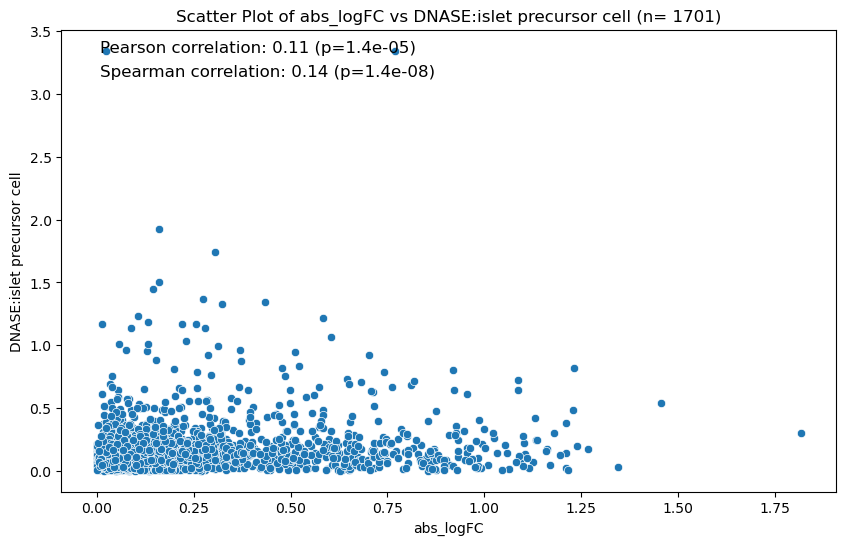

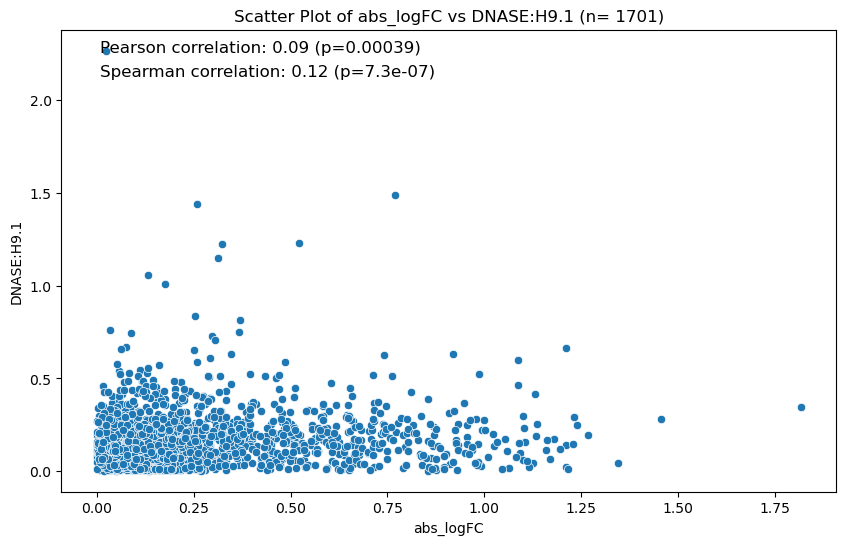

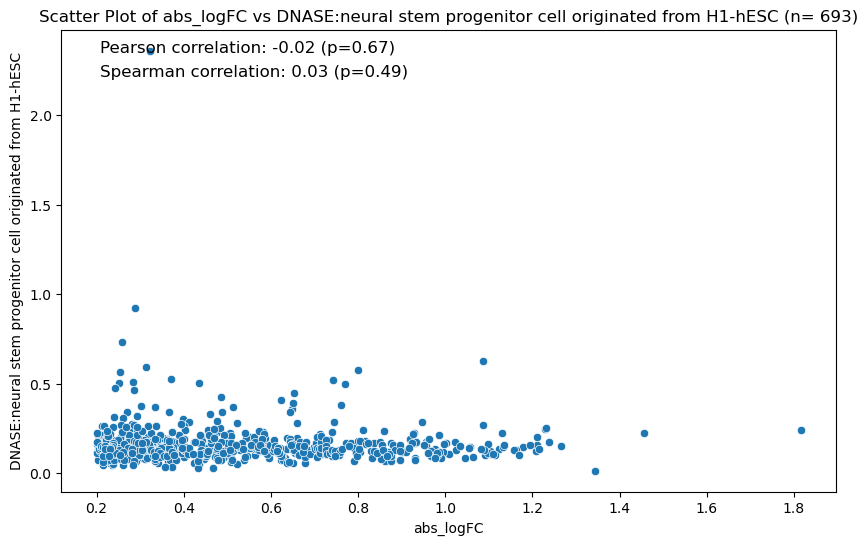

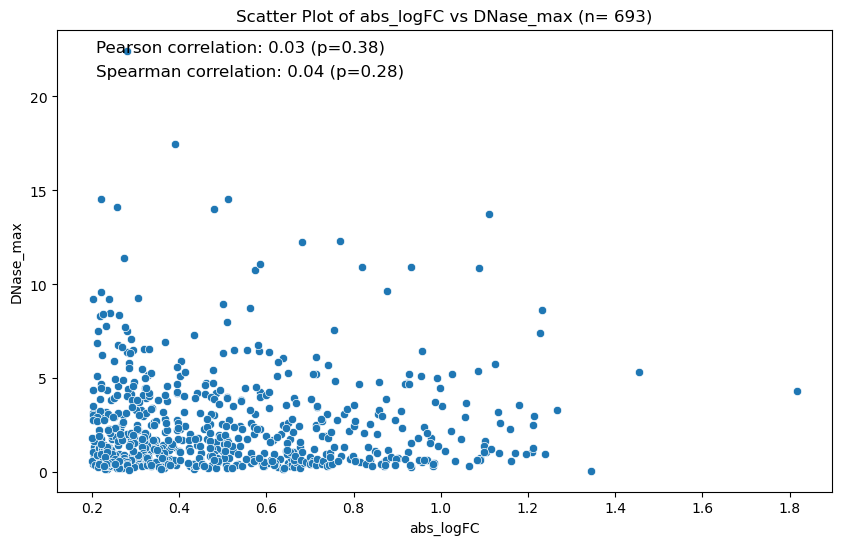

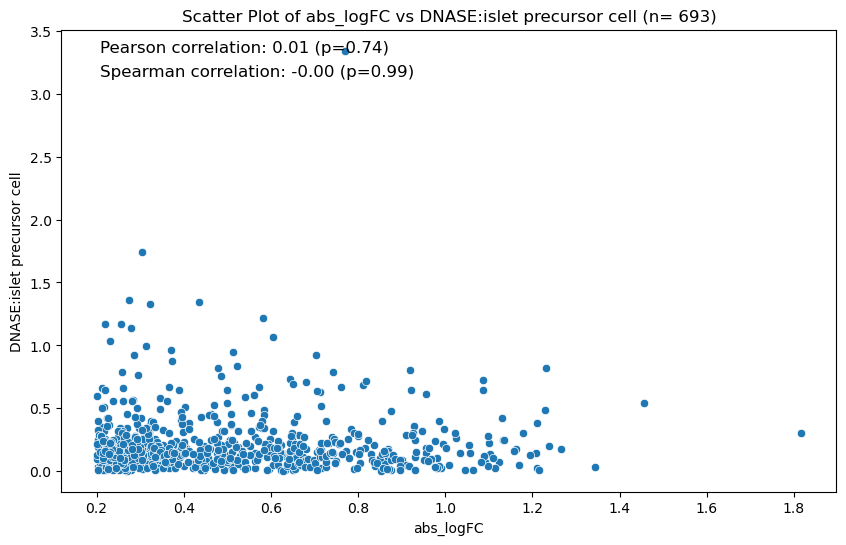

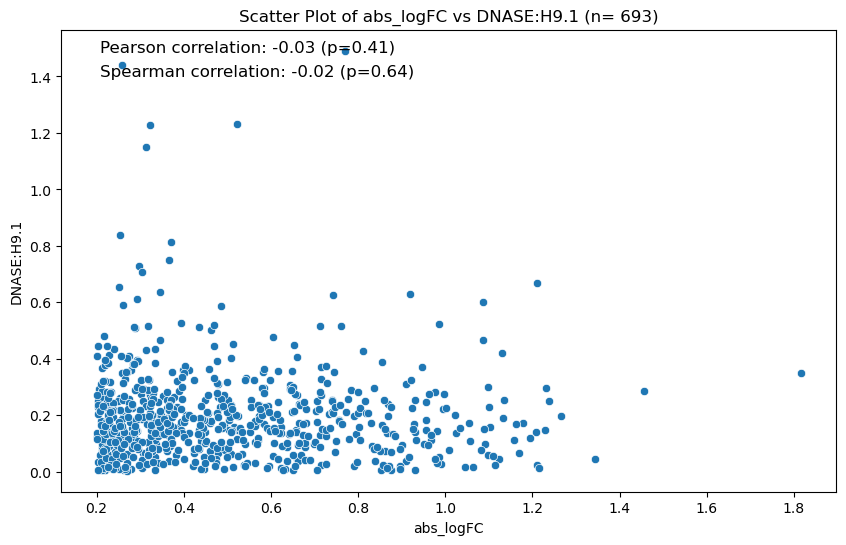

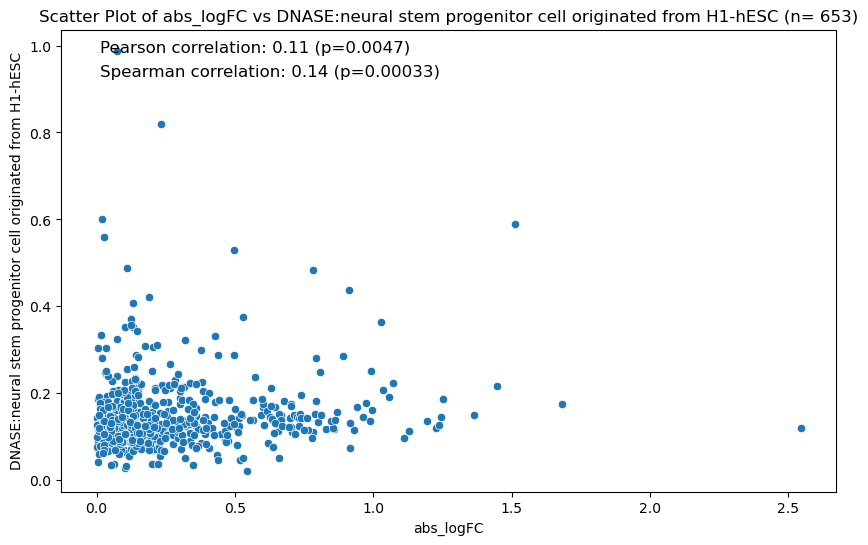

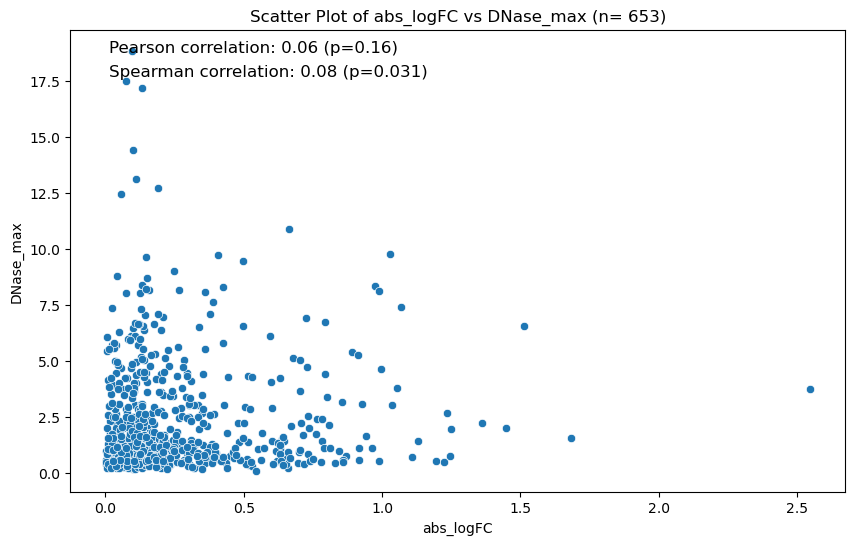

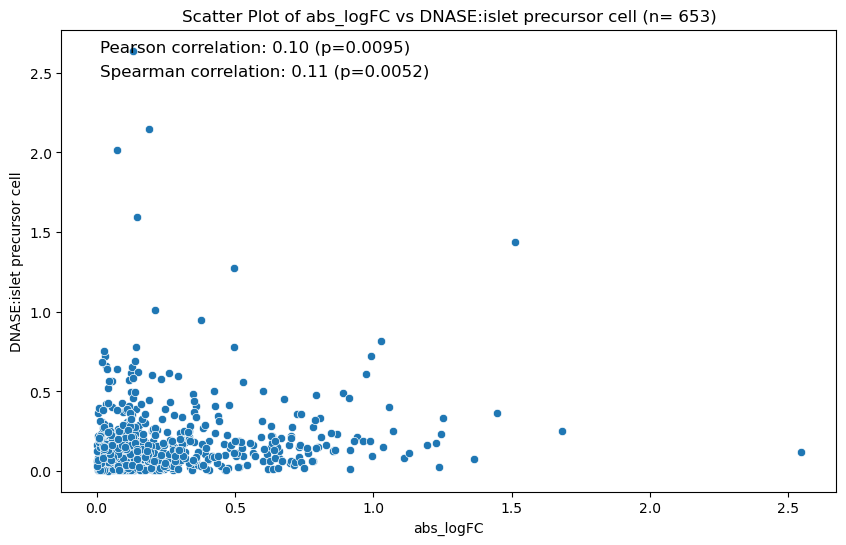

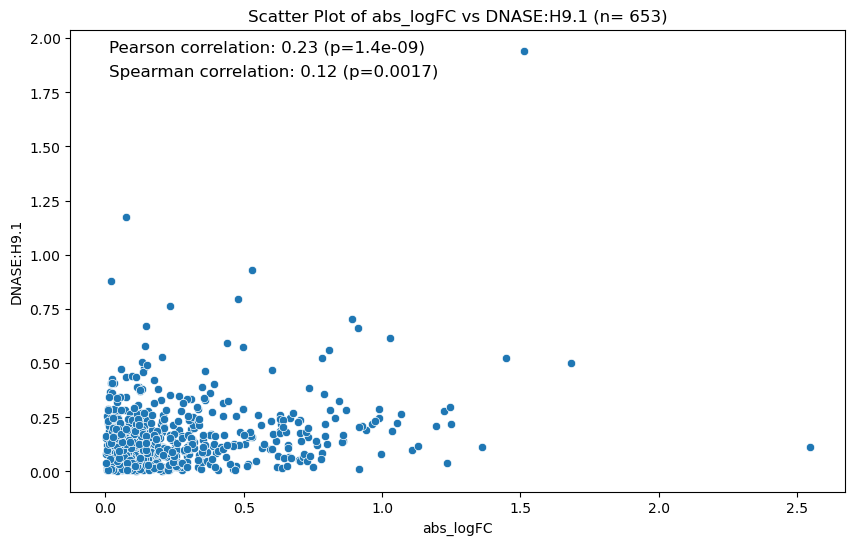

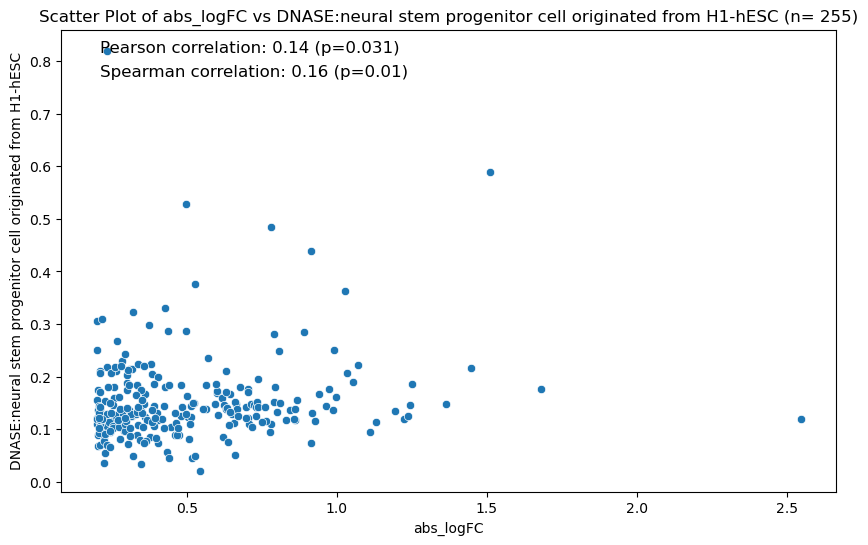

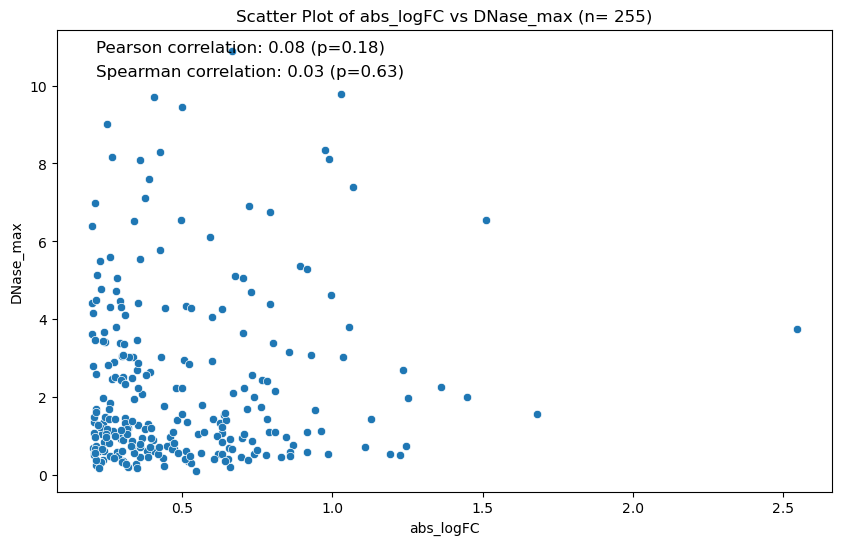

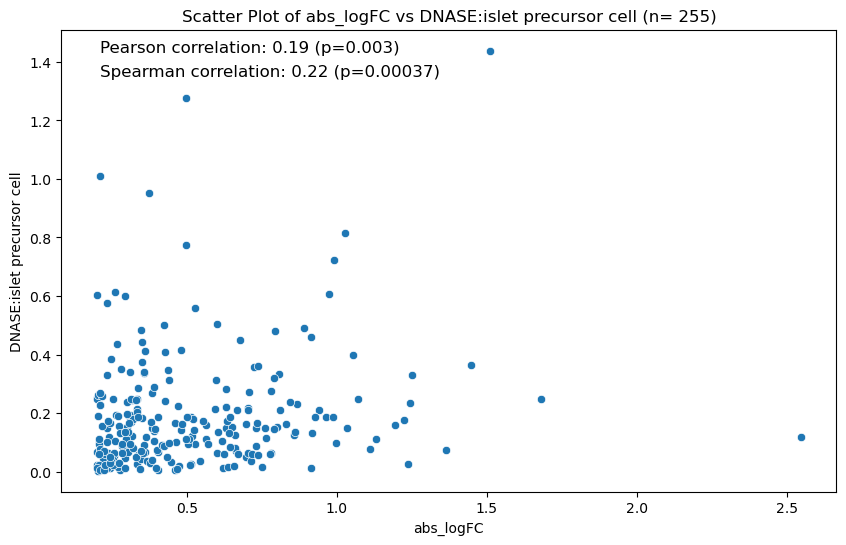

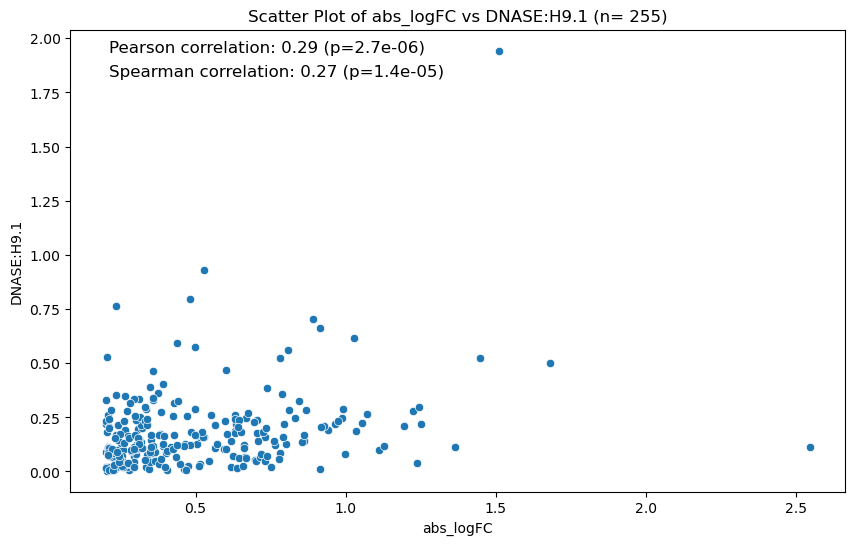

In [ ]:
# compare the correlations:
prediction_column_list = ['DNASE:neural stem progenitor cell originated from H1-hESC', 'DNase_max', 'DNASE:islet precursor cell', 'DNASE:H9.1'] # ['DNASE:neural stem progenitor cell originated from H1-hESC', 'DNase_max']
element_dfs = [cardiac_bcalm_all_merged_elements, neuro_bcalm_all_merged_elements, cava_bcalm_all_merged_elements, random_bcalm_all_merged_elements]
measured_column = ['abs_logFC']# 'abs_logFC', 'logFC' with abs_logFC: absolute values of measurements vs DNase values
for col1 in measured_column:
    for df in element_dfs:
        correlation_list = []
        # predictions comparison on full element set:
        for col2 in prediction_column_list:
            correlation_list.append(scatter_plot_of_prediction_measured_correlation(df, col1=col1, col2=col2))

        df_high_activity = df.loc[df[col1] >= 0.2]
        for col2 in prediction_column_list:
            correlation_list.append(scatter_plot_of_prediction_measured_correlation(df_high_activity, col1=col1, col2=col2))


In [52]:
bcalm_all_merged_elements['tmp_gene_name'].value_counts()

tmp_gene_name
AUTS2     380
RAD51B    373
FOXP1     343
WWOX      275
RERE      236
         ... 
MYH7        2
DRD4        2
LCE1A       1
NTHL1       1
NRAS        1
Name: count, Length: 522, dtype: int64

In [ ]:
bcalm_elements_all_predictions_merged.drop(columns=not_necessary_cols)

,logFC,DNase_max,max_col,DNASE:cerebellum male adult (27 years) and male adult (35 years),DNASE:frontal cortex male adult (27 years) and male adult (35 years),DNASE:chorion,DNASE:Ishikawa treated with 0.02% dimethyl sulfoxide for 1 hour,DNASE:GM03348,DNASE:GM03348 genetically modified using transduction treated with 3 ug/mL doxycycline for 10 days,DNASE:AG08395,...,DNASE:inferior parietal cortex male adult (84 years),DNASE:kidney capillary endothelial cell female embryo (113 days),DNASE:placenta male embryo (91 day),DNASE:right kidney male embryo (115 days),DNASE:coronary artery female adult (51 year),ATAC:BM0106-Day0-MCP-A / Bone Marrow CD34+ / pDC,ATAC:BM0106-UNK-ATAC-2 / Bone Marrow CD34+ / UNK,ATAC:BM0828-MEGA1-A-151109 / Bone Marrow CD34+ / Mega,ATAC:BM1077-MCP / Bone Marrow CD34+ / pDC,ATAC:BM1077-UNK / Bone Marrow CD34+ / UNK
0,2.056023,0.6182,DNASE:SK-MEL-5.1,0.0320,0.0307,0.0373,0.0506,0.0227,0.0190,0.0388,...,0.0551,0.1048,0.0555,0.0851,0.0597,2.3678,1.4921,2.2018,0.9275,1.0574
1,1.901706,1.6292,DNASE:A549,0.0606,0.0482,0.0425,0.0925,0.0331,0.0221,0.0596,...,0.0676,0.1134,0.0524,0.4930,0.0113,2.2172,0.9823,1.7878,1.0706,0.9541
2,2.088181,0.3966,DNASE:SK-MEL-5.1,0.0608,0.0535,0.0470,0.0737,0.0336,0.0273,0.0565,...,0.0579,0.1173,0.0512,0.0834,0.0200,1.9935,1.0576,1.7493,1.0573,1.0243
3,2.287976,1.1645,DNASE:H7-hESC.1,0.0715,0.0598,0.0851,0.1734,0.0384,0.0382,0.0578,...,0.0575,0.1003,0.0933,0.1036,0.1111,2.7052,1.5624,2.6087,1.0185,1.2910
4,1.768680,0.4848,DNASE:SK-MEL-5.1,0.0742,0.0548,0.0581,0.0740,0.0360,0.0320,0.0558,...,0.0444,0.0727,0.0501,0.0941,0.0419,1.1774,0.6196,1.1705,0.5512,0.6485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63328,-1.165619,4.8042,DNASE:HepG2.2,0.1113,0.1276,0.1467,0.2157,0.0937,0.0853,0.1954,...,0.1320,0.2798,0.1692,0.2020,0.0934,2.1971,1.0823,3.0348,1.1128,1.0964
63329,-1.194520,0.9707,DNASE:renal cortical epithelial cell,0.0901,0.0566,0.1388,0.2646,0.0534,0.0356,0.0855,...,0.0507,0.1247,0.2974,0.2050,0.0488,1.6660,0.7057,1.4415,0.7301,0.7759
63330,-1.177983,1.8362,DNASE:foreskin melanocyte male newborn,0.0915,0.0697,0.0607,0.1414,0.0482,0.0369,0.0826,...,0.0847,0.2089,0.0862,0.2275,0.0417,2.7214,1.6041,4.0859,1.3680,1.3132
63331,-1.222079,1.9516,DNASE:foreskin melanocyte male newborn,0.1250,0.0857,0.0761,0.1560,0.0563,0.0586,0.1144,...,0.0935,0.1418,0.0806,0.1863,0.0997,2.6052,1.7298,2.9143,1.3954,1.4152


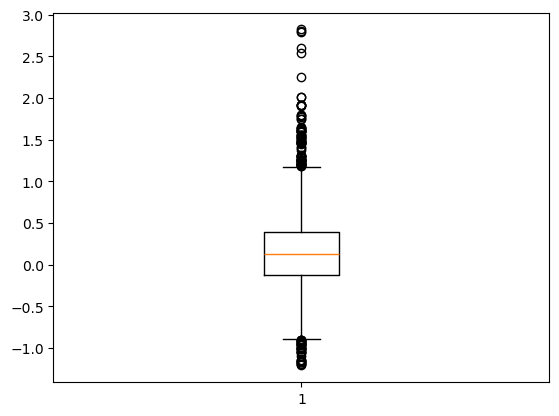

In [ ]:
plt.boxplot(bcalm_elements_open_merged['logFC'])
plt.show()

In [ ]:
# read merged table: (combined enformer prioritized and common variants)
merged_enformer_variant_table_path = '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/merged_variants_table.tsv'
merged_enformer_variant_df = pd.read_csv(merged_enformer_variant_table_path, sep="\t")
merged_enformer_variant_df.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info
0,chr1,2177753,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1,PASS,AF=0.0126802;AC=1930,1-2177753-C-T,NaN,NaN,"[('neuro', 'rare', 'NA')]"
1,chr1,2180660,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1,PASS,AF=0.0143032;AC=2175,1-2180660-T-C,NaN,NaN,"[('neuro', 'rare', 'NA')]"
2,chr1,2182832,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1,PASS,AF=0.0450113;AC=6841,1-2182832-C-T,NaN,NaN,"[('neuro', 'rare', 'NA')]"
3,chr1,2191284,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1,PASS,AF=0.046652;AC=7101,1-2191284-C-G,NaN,NaN,"[('neuro', 'rare', 'NA')]"
4,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,1-2191444-G-A,NaN,NaN,"[('neuro', 'rare', 'NA')]"


In [ ]:
merged_enformer_variant_df.shape[0] # 68222

68222

#### Old code because of problems with the matching (less well thought through it during the time the code was born)

Wieso bekomme ich immer noch nicht 5000 für die cardiac, cava und singleton raus? 

Was erwarte ich? (5000 für singleton oder ultra-rare und 2500 für random)

Wie viele sind cardiac, ultra-rare in variant file?

In [ ]:
merged_ultra_rare_singleton_variants.groupby(['gene_type', 'variant_type']).size()

gene_type  variant_type
cardiac    singleton       5000
           ultra-rare      5000
cava       singleton       5000
           ultra-rare      5000
neuro      singleton       5000
           ultra-rare      5000
random     singleton       2500
           ultra-rare      2500
dtype: int64

Investigate the number of unique IDs in both dataframes maybe not unique => unexpected behaviour
- ID is still not a unique identifier
- check if ID + gene_type is a unique identifier (it is) => then make list out of gene_type

In [ ]:
merged_ultra_rare_singleton_variants

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type
11743,chr7,151844596,PRKAG2|ENSG00000106617.15|EH38E2601933|7-15184...,A,G,1,PASS,AF=1.31399e-05;AC=2,cardiac,ultra-rare
11744,chr9,107505071,KLF4|ENSG00000136826.15|EH38E2715497|9-1075050...,T,G,1,PASS,AF=0.000453428;AC=69,cardiac,ultra-rare
11745,chr7,151806383,PRKAG2|ENSG00000106617.15|EH38E3809265|7-15180...,A,G,1,PASS,AF=5.91195e-05;AC=9,cardiac,ultra-rare
11746,chr19,55119303,TNNI3|ENSG00000129991.13|EH38E3317178|19-55119...,C,T,1,PASS,AF=1.97278e-05;AC=3,cardiac,ultra-rare
11747,chr15,67093652,SMAD3|ENSG00000166949.17|EH38E3141522|15-67093...,C,G,1,PASS,AF=1.9707e-05;AC=3,cardiac,ultra-rare
...,...,...,...,...,...,...,...,...,...,...
71405,chr6,26284345,H1-3|ENSG00000124575.7|EH38E3697740|6-26284345...,G,A,1,PASS,AF=6.57903e-06;AC=1,random,singleton
71406,chr2,210478202,CPS1|ENSG00000021826.18|EH38E3397495|2-2104782...,C,T,1,PASS,AF=6.5697e-06;AC=1,random,singleton
71407,chr2,210477975,CPS1|ENSG00000021826.18|EH38E3397495|2-2104779...,G,C,1,PASS,AF=6.57315e-06;AC=1,random,singleton
71408,chr2,210478142,CPS1|ENSG00000021826.18|EH38E3397495|2-2104781...,T,A,1,PASS,AF=6.56858e-06;AC=1,random,singleton


In [ ]:
merged_ultra_rare_singleton_variants['ID'].nunique()

34251

In [ ]:
merged_ultra_rare_singleton_variants['tmp_ID_gene_type'] = merged_ultra_rare_singleton_variants['ID'] + "_" + merged_ultra_rare_singleton_variants['gene_type']

/tmp/ipykernel_299781/3875900091.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_ultra_rare_singleton_variants['tmp_ID_gene_type'] = merged_ultra_rare_singleton_variants['ID'] + "_" + merged_ultra_rare_singleton_variants['gene_type']


In [ ]:
merged_ultra_rare_singleton_variants['tmp_ID_gene_type'].nunique()

35000

In [ ]:
# merged_ultra_rare_singleton_variants.groupby('ID')['gene_type'].apply(list).reset_index(name='alternatives')
merged_ultra_rare_singleton_variants


,ID,gene_type
0,AARS1|ENSG00000090861.17|EH38E3188744|16-70230...,[neuro]
1,AARS1|ENSG00000090861.17|EH38E3188759|16-70282...,[neuro]
2,AARS1|ENSG00000090861.17|EH38E3188759|16-70282...,[neuro]
3,AARS1|ENSG00000090861.17|EH38E3188760|16-70283...,[neuro]
4,AARS1|ENSG00000090861.17|EH38E3188772|16-70291...,[neuro]
...,...,...
34246,ZNF462|ENSG00000148143.13|EH38E3899572|9-10694...,[neuro]
34247,ZNF462|ENSG00000148143.13|EH38E3899577|9-10695...,[neuro]
34248,ZNF462|ENSG00000148143.13|EH38E3899581|9-10695...,[neuro]
34249,ZNF462|ENSG00000148143.13|EH38E3899612|9-10703...,[neuro]


In [ ]:
matched_row_counter

39195

#### Prepare the enformer files for the common variants (without enformer class => set enformer_class == "NA")

In [ ]:
common_variant_dir = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants'
common_variant_files = [os.path.join(common_variant_dir, file) for file in os.listdir(common_variant_dir) if (".common" in file) or (".rare" in file)]
common_variant_files

['/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/neuro.rare_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/neuro.common_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/random.common_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/cava.rare_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/random.rare_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/cardiac.rare_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/cava.common_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/

Check if these ids are unique as well => They are

In [ ]:
unique_files = 0
for variant_files in common_variant_files:
    # get information for precise printing
    entformer_name = variant_files.split("/")[-1]
    variant_files_df = pd.read_csv(variant_files, sep="\t")
    gene_type = variant_files.split("/")[-1].split('_')[0]
    variant_type = variant_files.split("/")[-1].split('_')[1].split('_')[0]
    # check for duplicated IDs
    if variant_files_df['ID'].nunique() == variant_files_df.shape[0]:
        unique_files += 1
    if len(variant_files_df.columns) > 10:
        print(variant_files)
        print(variant_files_df.columns)
if unique_files == len(common_variant_files):
    print('IDs are unique!')

IDs are unique!


Check if there are duplicated common variants 

In [ ]:
# merge the common variant files
merged_common_variant_df = pd.concat([pd.read_csv(file, sep='\t') for file in common_variant_files])
print(merged_common_variant_df.shape[0]) # 36410
merged_common_variant_df['ID'].duplicated().sum() # 1456


36410


1456

In [ ]:
merged_common_variant_df.loc[merged_common_variant_df.duplicated(subset=['ID'], keep=False)].sort_values(by="POS") # as you can see different gene types

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type
5846,chr11,492765,HRAS|ENSG00000174775.18|EH38E2937561|11-492765...,C,T,1,PASS,AF=0.0263002;AC=4004,neuro,rare
3243,chr11,492765,HRAS|ENSG00000174775.18|EH38E2937561|11-492765...,C,T,1,PASS,AF=0.0263002;AC=4004,cardiac,rare
3244,chr11,492972,HRAS|ENSG00000174775.18|EH38E2937561|11-492972...,G,A,1,PASS,AF=0.0129466;AC=1970,cardiac,rare
5847,chr11,492972,HRAS|ENSG00000174775.18|EH38E2937561|11-492972...,G,A,1,PASS,AF=0.0129466;AC=1970,neuro,rare
6894,chr11,493007,HRAS|ENSG00000174775.18|EH38E2937561|11-493007...,C,G,1,PASS,AF=0.532344;AC=80927,neuro,common
...,...,...,...,...,...,...,...,...,...,...
324,chr1,156178457,LMNA|ENSG00000160789.24|EH38E1387748|1-1561784...,C,T,1,PASS,AF=0.0553516;AC=8413,cardiac,common
28,chr1,156178510,LMNA|ENSG00000160789.24|EH38E1387748|1-1561785...,A,G,1,PASS,AF=0.0321415;AC=4885,cava,rare
294,chr1,156178510,LMNA|ENSG00000160789.24|EH38E1387748|1-1561785...,A,G,1,PASS,AF=0.0321415;AC=4885,cardiac,rare
42,chr1,156186428,LMNA|ENSG00000160789.24|EH38E2840601|1-1561864...,T,C,1,PASS,AF=0.201702;AC=30666,cava,common


investigate the duplicates

In [ ]:
merged_common_variant_df['chr_pos_ref_alt'] = merged_common_variant_df['ID'].apply(hf.get_chrom_pos_ref_alt_pattern)
duplicated_merged_common_variant_df = merged_common_variant_df.loc[merged_common_variant_df['ID'].duplicated(keep=False)].sort_values(by='chr_pos_ref_alt')
duplicated_merged_common_variant_df['ID'].to_list()[:10]

['LMNA|ENSG00000160789.24|EH38E2840374|1-156033864-A-T',
 'LMNA|ENSG00000160789.24|EH38E2840374|1-156033864-A-T',
 'LMNA|ENSG00000160789.24|EH38E2840410|1-156072629-C-T',
 'LMNA|ENSG00000160789.24|EH38E2840410|1-156072629-C-T',
 'LMNA|ENSG00000160789.24|EH38E2840417|1-156076182-C-T',
 'LMNA|ENSG00000160789.24|EH38E2840417|1-156076182-C-T',
 'LMNA|ENSG00000160789.24|EH38E2840429|1-156082048-T-G',
 'LMNA|ENSG00000160789.24|EH38E2840429|1-156082048-T-G',
 'LMNA|ENSG00000160789.24|EH38E2840429|1-156082100-T-G',
 'LMNA|ENSG00000160789.24|EH38E2840429|1-156082100-T-G']

Resolve the duplicates with the same technique like the ultra-rare and singleton => dict

In [ ]:
merged_common_variant_df['ID'].duplicated().sum()
merged_common_variant_df[['ID', 'variant_type']].duplicated().sum()

1456

In [ ]:
def reduce_association_list(type_list):
    """Check if all elements are the same if so return only one elemented list"""
    return list(set(type_list))

In [ ]:
#### Old: by producing lists
# gene_list_df = merged_common_variant_df.groupby('ID')['gene_type'].apply(list).reset_index(name='gene_type_list')
# # variant_type_list_df = merged_common_variant_df.groupby('ID')['variant_type'].apply(list).reset_index(name='variant_type_list')
# # summarized_common_variant_df = summarized_gene_type.merge(variant_type_list_df, on='ID', how='left')
# # summarized_common_variant_df['variant_type_list'] = summarized_common_variant_df['variant_type_list'].apply(reduce_association_list)

# # left join with
# summarized_common_variant_df = merged_common_variant_df.merge(gene_list_df, on='ID', how='left')
# summarized_common_variant_df['gene_type_list'] = summarized_common_variant_df['gene_type_list'].apply(reduce_association_list)
# # only common info is interesting
# summarized_common_variant_df['variant_type_list'] = 'common'
# summarized_common_variant_df.drop(columns=['gene_type'], inplace=True)
# summarized_common_variant_df.drop(columns=['variant_type'], inplace=True)

# # rename to gene_type and variant_type
# summarized_common_variant_df.rename(columns={'gene_type_list': 'gene_type', 'variant_type_list': 'variant_type'}, inplace=True)

# summarized_common_variant_df.drop_duplicates(subset=['ID'], inplace=True)
# summarized_common_variant_df # 34954

# summarized_common_variant_df['enformer_class'] = 'NA'
# summarized_common_variant_df['DNase_max'] = 'NA'
# summarized_common_variant_df['max_col'] = 'NA'

# # write to file
# output_common_variant_directory = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants'
# output_path = os.path.join(input_variant_directory, 'merged_common_variants.tsv')
# summarized_common_variant_df.to_csv(output_path, sep="\t", index=False)

Reduced the number of rows to 34954

In [ ]:
# summarized_common_variant_df.shape[0]

34954

In [ ]:
merged_common_variant_df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type
0,chr1,2177753,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1,PASS,AF=0.0126802;AC=1930,neuro,rare
1,chr1,2180660,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1,PASS,AF=0.0143032;AC=2175,neuro,rare
2,chr1,2182832,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1,PASS,AF=0.0450113;AC=6841,neuro,rare
3,chr1,2191284,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1,PASS,AF=0.046652;AC=7101,neuro,rare
4,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,neuro,rare
...,...,...,...,...,...,...,...,...,...,...
6455,chrX,154367050,FLNA|ENSG00000196924.19|EH38E2774215|X-1543670...,T,C,1,PASS,AF=0.36263;AC=40269,cardiac,common
6456,chrX,154369716,FLNA|ENSG00000196924.19|EH38E2774221|X-1543697...,C,A,1,PASS,AF=0.0758093;AC=8466,cardiac,common
6457,chrX,154384011,FLNA|ENSG00000196924.19|EH38E3949546|X-1543840...,G,C,1,PASS,AF=0.36297;AC=40081,cardiac,common
6458,chrX,154396528,FLNA|ENSG00000196924.19|EH38E3949551|X-1543965...,A,G,1,PASS,AF=0.294413;AC=29751,cardiac,common


In [ ]:
def get_gene_association(id):
    """Get the gene of the id: SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T => SKI"""
    return id.split('|')[0]

In [ ]:
### New code
merged_common_variant_df['enformer_class'] = 'NA'
merged_common_variant_df['DNase_max'] = 'NA'
merged_common_variant_df['max_col'] = 'NA'
# merged_common_variant_df['gene_association'] = merged_common_variant_df['ID'].apply(get_gene_association)
# merged_common_variant_df['variant_type'] = 'common' # I think the split between common and rare is not important (it is actually)

# merged_common_variant_df['merged'] = merged_common_variant_df.apply(lambda row: {row['gene_type']:(row['variant_type'], row['enformer_class'])}, axis=1)
merged_common_variant_df['merged'] = merged_common_variant_df.apply(lambda row: (row['gene_type'], row['variant_type'], row['enformer_class']), axis=1)
merged_common_variant_df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type,chr_pos_ref_alt,enformer_class,DNase_max,max_col,merged
0,chr1,2177753,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1,PASS,AF=0.0126802;AC=1930,neuro,rare,1-2177753-C-T,NA,NA,NA,"(neuro, rare, NA)"
1,chr1,2180660,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1,PASS,AF=0.0143032;AC=2175,neuro,rare,1-2180660-T-C,NA,NA,NA,"(neuro, rare, NA)"
2,chr1,2182832,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1,PASS,AF=0.0450113;AC=6841,neuro,rare,1-2182832-C-T,NA,NA,NA,"(neuro, rare, NA)"
3,chr1,2191284,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1,PASS,AF=0.046652;AC=7101,neuro,rare,1-2191284-C-G,NA,NA,NA,"(neuro, rare, NA)"
4,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,neuro,rare,1-2191444-G-A,NA,NA,NA,"(neuro, rare, NA)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6455,chrX,154367050,FLNA|ENSG00000196924.19|EH38E2774215|X-1543670...,T,C,1,PASS,AF=0.36263;AC=40269,cardiac,common,X-154367050-T-C,NA,NA,NA,"(cardiac, common, NA)"
6456,chrX,154369716,FLNA|ENSG00000196924.19|EH38E2774221|X-1543697...,C,A,1,PASS,AF=0.0758093;AC=8466,cardiac,common,X-154369716-C-A,NA,NA,NA,"(cardiac, common, NA)"
6457,chrX,154384011,FLNA|ENSG00000196924.19|EH38E3949546|X-1543840...,G,C,1,PASS,AF=0.36297;AC=40081,cardiac,common,X-154384011-G-C,NA,NA,NA,"(cardiac, common, NA)"
6458,chrX,154396528,FLNA|ENSG00000196924.19|EH38E3949551|X-1543965...,A,G,1,PASS,AF=0.294413;AC=29751,cardiac,common,X-154396528-A-G,NA,NA,NA,"(cardiac, common, NA)"


has still duplicates which will be made unique with the ultra-rare and singleton variants

In [ ]:
merged_common_variant_df

In [ ]:
# remove columns and sanity check with the chosen example from below:
merged_common_variant_df.loc[merged_common_variant_df['ID'] == 'LMNA|ENSG00000160789.24|EH38E2840374|1-156033864-A-T']

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type,enformer_class,DNase_max,max_col,merged
0,chr1,156033864,LMNA|ENSG00000160789.24|EH38E2840374|1-1560338...,A,T,1,PASS,AF=0.489263;AC=73868,cava,common,NA,NA,NA,"(cava, common, NA)"
283,chr1,156033864,LMNA|ENSG00000160789.24|EH38E2840374|1-1560338...,A,T,1,PASS,AF=0.489263;AC=73868,cardiac,common,NA,NA,NA,"(cardiac, common, NA)"


#### Combining the enformer information file
- First question: is the ID a unique identifier => yes all files individually have unique ids
- mergeing a row if there is the same variant described: (need to change the ID or merge rows together)
  - Add column: gene type and enformer info: (dict: {'gene_set': ('variant_type', 'enformer_class')})
  - same means: same gene association + variant position (ID), 

In [ ]:
# input of the variant files
input_variant_directory = '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants'
input_variant_directory_server = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants'

input_files = [os.path.join(input_variant_directory, file) for file in os.listdir(input_variant_directory) if ('prioritized_variants.tsv' in file) and not ('merged' in file)]
input_files

# output_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/with_enformer_info'
# output_path = '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_merged'
output_path = '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_merged'

# iterate over enformer_variant files
unique_files = 0
for enformer_file in input_files:
    # get information for precise printing
    entformer_name = enformer_file.split("/")[-1]
    enformer_file_df = pd.read_csv(enformer_file, sep="\t")
    gene_type = enformer_file.split("/")[-1].split('_')[0]
    variant_type = enformer_file.split("/")[-1].split('_')[1].split('_')[0]
    # check for duplicated IDs
    if enformer_file_df['ID'].nunique() == enformer_file_df.shape[0]:
        unique_files += 1
if unique_files == len(input_files):
    print('IDs are unique!')


IDs are unique!


##### Add the common but first make the data structure for ultra-rare and singleton and then for the common variants

In [ ]:
# merge the input files
merged_enformer_variant_df = pd.concat([pd.read_csv(file, sep='\t') for file in input_files])
merged_enformer_variant_df['chr_pos_ref_alt'] = merged_enformer_variant_df['ID'].apply(hf.get_chrom_pos_ref_alt_pattern)

# # create new column being the dict representation of the enformer info: (dict: {'gene_type': ('variant_type', 'enformer_class')})
merged_enformer_variant_df['merged'] = merged_enformer_variant_df.apply(lambda row: (row['gene_type'], row['variant_type'], row['enformer_class']), axis=1)

In [ ]:
merged_enformer_variant_df.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO',
       'variant_type', 'gene_type', 'DNase_max', 'max_col', 'enformer_class',
       'merged'],
      dtype='object')

Check how a duplicated ID looks like at this stage

In [ ]:
merged_enformer_variant_df.loc[merged_enformer_variant_df['ID'] == 'CACNA1C|ENSG00000151067.23|EH38E2998634|12-2616967-C-A']

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,variant_type,gene_type,DNase_max,max_col,enformer_class,merged
3,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,1,PASS,AF=6.56763e-06;AC=1,singleton,cardiac,2754.7705,401_DNASE:common myeloid,enformer_high,"(cardiac, singleton, enformer_high)"
13,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,1,PASS,AF=6.56763e-06;AC=1,singleton,neuro,2754.7705,401_DNASE:common myeloid,enformer_high,"(neuro, singleton, enformer_high)"


In [ ]:
# merged_enformer_variant_df.shape[0] # 35000 with common: 69954

In [ ]:
# merged_enformer_variant_df.head()

concat with common list of tuples

In [ ]:
merged_variants_df = pd.concat([merged_common_variant_df, merged_enformer_variant_df])
merged_variants_df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type,chr_pos_ref_alt,enformer_class,DNase_max,max_col,merged
0,chr1,2177753,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1,PASS,AF=0.0126802;AC=1930,neuro,rare,1-2177753-C-T,NA,NA,NA,"(neuro, rare, NA)"
1,chr1,2180660,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1,PASS,AF=0.0143032;AC=2175,neuro,rare,1-2180660-T-C,NA,NA,NA,"(neuro, rare, NA)"
2,chr1,2182832,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1,PASS,AF=0.0450113;AC=6841,neuro,rare,1-2182832-C-T,NA,NA,NA,"(neuro, rare, NA)"
3,chr1,2191284,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1,PASS,AF=0.046652;AC=7101,neuro,rare,1-2191284-C-G,NA,NA,NA,"(neuro, rare, NA)"
4,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,neuro,rare,1-2191444-G-A,NA,NA,NA,"(neuro, rare, NA)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,chr2,219219689,ANKZF1|ENSG00000163516.14|EH38E3401197|2-21921...,T,G,1,PASS,AF=1.97075e-05;AC=3,random,ultra-rare,2-219219689-T-G,enformer_low,-0.586787,31_DNASE:iPS-NIHi11 mal,"(random, ultra-rare, enformer_low)"
2496,chr19,48747089,IZUMO1|ENSG00000182264.9|EH38E1960256|19-48747...,C,T,1,PASS,AF=1.31413e-05;AC=2,random,ultra-rare,19-48747089-C-T,enformer_low,-0.961862,90_DNASE:HeLa-S3 G1b ph,"(random, ultra-rare, enformer_low)"
2497,chr2,210475933,CPS1|ENSG00000021826.18|EH38E3397490|2-2104759...,C,A,1,PASS,AF=2.62871e-05;AC=4,random,ultra-rare,2-210475933-C-A,enformer_low,-0.964058,665_DNASE:testis male ad,"(random, ultra-rare, enformer_low)"
2498,chr2,210477091,CPS1|ENSG00000021826.18|EH38E3397493|2-2104770...,C,T,1,PASS,AF=7.60025e-05;AC=11,random,ultra-rare,2-210477091-C-T,enformer_low,-1.122092,170_DNASE:iPS DF 4.7 mal,"(random, ultra-rare, enformer_low)"


##### Add new datastructure: enformer_variant_info list of tuples ('gene_set', 'variant_type', 'enformer_class')
- for each gene_set the variant type and enformer class
- first for ultra-rare and singleton 
- secondly for common variants
- !! ATTENTION: We remove here information about the associated gene (some variants are associated to multiple genes but we only care for the position of the variant here)

In [ ]:
grouped_tuples = merged_variants_df[['chr_pos_ref_alt', 'merged']].groupby(['chr_pos_ref_alt']).agg(list).reset_index()
grouped_tuples
# # rename column
grouped_tuples.rename(columns={'merged': 'enformer_variant_info'}, inplace=True)

# # left join with
grouped_merged_variants_df = merged_variants_df.merge(grouped_tuples, on="chr_pos_ref_alt", how='left')
grouped_merged_variants_df.drop(columns=['merged', 'variant_type', 'enformer_class', 'gene_type'], inplace=True)

grouped_merged_variants_df.drop_duplicates(subset=['chr_pos_ref_alt'], inplace=True)

In [ ]:
grouped_merged_variants_df.loc[grouped_merged_variants_df['ID'] == 'CACNA1C|ENSG00000151067.23|EH38E2998634|12-2616967-C-A']
grouped_merged_variants_df.loc[grouped_merged_variants_df['chr_pos_ref_alt'] == '16-2015380-G-C']

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info
39011,chr16,2015380,TSC2|ENSG00000103197.18|EH38E3162684|16-201538...,G,C,1,PASS,AF=6.57298e-06;AC=1,16-2015380-G-C,351.10806,47_DNASE:A549,"[(cardiac, singleton, enformer_high), (cava, s..."


In [ ]:
grouped_merged_variants_df['ID'].duplicated().sum() # no non unique ids

0

In [ ]:
output_variant_directory = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants'
output_variants_local = '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants'
output_path = os.path.join(output_variant_directory, 'merged_variants_table.tsv')
output_path = os.path.join(output_variants_local, 'merged_variants_table.tsv')

In [ ]:
output_path

'/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/merged_variants_table.tsv'

In [ ]:
# grouped_merged_variants_df.to_csv(output_path, sep="\t", index=False)

In [ ]:
grouped_merged_variants_df.loc[grouped_merged_variants_df['ID'] == 'CACNA1C|ENSG00000151067.23|EH38E2998634|12-2616967-C-A']['enformer_variant_info'].to_list()

[[('cardiac', 'singleton', 'enformer_high'),
  ('neuro', 'singleton', 'enformer_high')]]

In [ ]:
# check the duplicates
def get_enformer_variant_info_length(enformer_variant_info):
    """
    Return the length of the list of dicts
    """
    return len(enformer_variant_info)

duplicated_merged_variants = grouped_merged_variants_df.loc[grouped_merged_variants_df['enformer_variant_info'].apply(get_enformer_variant_info_length) > 1]
duplicated_merged_variants.to_csv('duplicated_variants_tuple_check.tsv', sep="\t", index=False)

investigate the results (get enformer variant type and gene set)

In [ ]:
def get_enformer_class_list(enformer_variant_info):
    """
    return the enformer class list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    enformer_class_list = []
    for elem in enformer_variant_info:
        enformer_class_list.append(elem[2])
    return list(set(enformer_class_list))

def get_variant_type_list(enformer_variant_info):
    """
    return the variant type list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    variant_type_list = []
    for elem in enformer_variant_info:
        variant_type_list.append(elem[1])
    return list(set(variant_type_list))

def get_gene_set_list(enformer_variant_info):
    """
    return the geme set list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    gene_set_list = []
    for elem in enformer_variant_info:
        gene_set_list.append(elem[0])
    return list(set(gene_set_list))

In [ ]:
grouped_merged_variants_df['enformer_class_list'] = grouped_merged_variants_df['enformer_variant_info'].apply(get_enformer_class_list)
grouped_merged_variants_df['gene_set_list'] = grouped_merged_variants_df['enformer_variant_info'].apply(get_gene_set_list)
grouped_merged_variants_df['variant_type_list'] = grouped_merged_variants_df['enformer_variant_info'].apply(get_variant_type_list)

In [ ]:
grouped_merged_variants_df['enformer_class_list'].value_counts()


enformer_class_list
[NA]                                34954
[enformer_high]                     23905
[enformer_random]                    5248
[enformer_low]                       5096
[enformer_high, enformer_random]        1
[enformer_random, enformer_low]         1
Name: count, dtype: int64

In [ ]:
grouped_merged_variants_df['gene_set_list'].value_counts()


gene_set_list
[neuro]                   29392
[cardiac]                 19844
[cava]                    11900
[random]                   5956
[cardiac, neuro]           1455
[cava, cardiac]             352
[cava, neuro]               214
[cava, cardiac, neuro]       92
Name: count, dtype: int64

In [ ]:
grouped_merged_variants_df['variant_type_list'].value_counts()

variant_type_list
[common]        34954
[ultra-rare]    17130
[singleton]     17121
Name: count, dtype: int64

In [ ]:
# grouped = merged_enformer_variant_df[['ID', 'merged']].groupby(['ID'])
# grouped_enformer_variant_df = grouped.aggregate(lambda x: x).reset_index()
# # rename column
# grouped_enformer_variant_df.rename(columns={'merged': 'enformer_variant_info'}, inplace=True)

# grouped_enformer_variant_df.shape[0] # 34251
# # left join with
# grouped_merged_enformer_variant_df = merged_enformer_variant_df.merge(grouped_enformer_variant_df, on="ID", how='left')
# grouped_merged_enformer_variant_df.drop(columns=['merged', 'variant_type', 'enformer_class', 'gene_type'], inplace=True)

# grouped_merged_enformer_variant_df.drop_duplicates(subset=['ID'], inplace=True)

Only for enformer files: 

In [ ]:
# grouped_tuples = merged_enformer_variant_df[['ID', 'merged']].groupby(['ID']).agg(list).reset_index()
# grouped_tuples
# # # rename column
# grouped_tuples.rename(columns={'merged': 'enformer_variant_info'}, inplace=True)

# # # left join with
# grouped_merged_enformer_variant_df = merged_enformer_variant_df.merge(grouped_tuples, on="ID", how='left')
# grouped_merged_enformer_variant_df.drop(columns=['merged', 'variant_type', 'enformer_class', 'gene_type'], inplace=True)

# grouped_merged_enformer_variant_df.drop_duplicates(subset=['ID'], inplace=True)

In [ ]:
# grouped_merged_enformer_variant_df

In [ ]:
grouped_merged_enformer_variant_df['ID'].duplicated().sum() # no duplicates

0

In [ ]:
grouped_merged_enformer_variant_df.loc[grouped_merged_enformer_variant_df['ID'] == 'CACNA1C|ENSG00000151067.23|EH38E2998634|12-2616967-C-A']['enformer_variant_info'].to_list()

[array([{'cardiac': ('singleton', 'enformer_high')},
        {'neuro': ('singleton', 'enformer_high')}], dtype=object)]

Same for common

In [ ]:
merged_common_variant_df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type,enformer_class,DNase_max,max_col,merged
0,chr1,2177753,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1,PASS,AF=0.0126802;AC=1930,neuro,rare,NA,NA,NA,"{'neuro': ('rare', 'NA')}"
1,chr1,2180660,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1,PASS,AF=0.0143032;AC=2175,neuro,rare,NA,NA,NA,"{'neuro': ('rare', 'NA')}"
2,chr1,2182832,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1,PASS,AF=0.0450113;AC=6841,neuro,rare,NA,NA,NA,"{'neuro': ('rare', 'NA')}"
3,chr1,2191284,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1,PASS,AF=0.046652;AC=7101,neuro,rare,NA,NA,NA,"{'neuro': ('rare', 'NA')}"
4,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,neuro,rare,NA,NA,NA,"{'neuro': ('rare', 'NA')}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6455,chrX,154367050,FLNA|ENSG00000196924.19|EH38E2774215|X-1543670...,T,C,1,PASS,AF=0.36263;AC=40269,cardiac,common,NA,NA,NA,"{'cardiac': ('common', 'NA')}"
6456,chrX,154369716,FLNA|ENSG00000196924.19|EH38E2774221|X-1543697...,C,A,1,PASS,AF=0.0758093;AC=8466,cardiac,common,NA,NA,NA,"{'cardiac': ('common', 'NA')}"
6457,chrX,154384011,FLNA|ENSG00000196924.19|EH38E3949546|X-1543840...,G,C,1,PASS,AF=0.36297;AC=40081,cardiac,common,NA,NA,NA,"{'cardiac': ('common', 'NA')}"
6458,chrX,154396528,FLNA|ENSG00000196924.19|EH38E3949551|X-1543965...,A,G,1,PASS,AF=0.294413;AC=29751,cardiac,common,NA,NA,NA,"{'cardiac': ('common', 'NA')}"


In [ ]:
grouped_common = merged_common_variant_df[['ID', 'merged']].groupby(['ID'])
grouped_common_df = grouped_common.aggregate(lambda x: x).reset_index()
# rename column
grouped_common_df.rename(columns={'merged': 'enformer_variant_info'}, inplace=True)

print(grouped_common_df.shape[0]) # 34954
# left join with
grouped_merged_common_variant_df = merged_common_variant_df.merge(grouped_common_df, on="ID", how='left')
grouped_merged_common_variant_df.drop(columns=['merged', 'variant_type', 'enformer_class', 'gene_type'], inplace=True)

grouped_merged_common_variant_df.drop_duplicates(subset=['ID'], inplace=True)

34954


write common df to file

In [ ]:
# output_common_variant_directory = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants'
# output_path = os.path.join(output_common_variant_directory, 'merged_common_variants.tsv')
# grouped_merged_common_variant_df.to_csv(output_path, sep="\t", index=False)

In [ ]:
grouped_merged_common_variant_df.loc[grouped_merged_common_variant_df['ID'] == 'LMNA|ENSG00000160789.24|EH38E2840374|1-156033864-A-T']

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,DNase_max,max_col,enformer_variant_info
28528,chr1,156033864,LMNA|ENSG00000160789.24|EH38E2840374|1-1560338...,A,T,1,PASS,AF=0.489263;AC=73868,NA,NA,"[{'cava': ('common', 'NA')}, {'cardiac': ('com..."


In [ ]:
common_file = [os.path.join(input_variant_directory, file) for file in os.listdir(input_variant_directory) if ('merged_common_variants.tsv' in file)]

In [ ]:
def was_merged(column_list):
    """check if column of insterest has more than 1 element"""
    if len(column_list) > 1:
        return True
    return False

In [ ]:
# def get_enformer_class_list(enformer_variant_info):
#     """
#     return the enformer class list
#     enformer_variant_info: [{'gene_set': ('variant_type', 'enformer_class')}, ]
#     """
#     enformer_class_list = []
#     if len(enformer_variant_info) == 1:
#         for gene_set, values in enformer_variant_info.items():
#             variant_type, enformer_class = values
#             enformer_class_list.append(enformer_class)
#         return list(set(enformer_class_list))
#     for elem_dict in enformer_variant_info:
#         for gene_set, values in elem_dict.items():
#             variant_type, enformer_class = values
#             enformer_class_list.append(enformer_class)
#     return list(set(enformer_class_list))

# def get_variant_type_list(enformer_variant_info):
#     """
#     return the variant type list
#     enformer_variant_info: {'gene_set': ('variant_type', 'enformer_class')}
#     """
#     variant_type_list = []
#     if len(enformer_variant_info) == 1:
#         for gene_set, values in enformer_variant_info.items():
#             variant_type, enformer_class = values
#             variant_type_list.append(variant_type)
#         return list(set(variant_type_list))
#     for elem_dict in enformer_variant_info:
#         for gene_set, values in elem_dict.items():
#             variant_type, enformer_class = values
#             variant_type_list.append(variant_type)
#     return list(set(variant_type_list))

# def get_gene_set_list(enformer_variant_info):
#     """
#     return the geme set list
#     enformer_variant_info: {'gene_set': ('variant_type', 'enformer_class')}
#     """
#     gene_set_list = []
#     if len(enformer_variant_info) == 1:
#         for gene_set, values in enformer_variant_info.items():
#             gene_set_list.append(gene_set)
#         return list(set(gene_set_list))
#     for elem_dict in enformer_variant_info:
#         for gene_set, values in elem_dict.items():
#             gene_set_list.append(gene_set)
#     return list(set(gene_set_list))

def get_enformer_variant_info_length(enformer_variant_info):
    """
    Return the length of the list of dicts
    """
    return len(enformer_variant_info)


def is_element_of(column_list, pattern):
    """Check for the pattern in the column_list"""
    return pattern in column_list


investigate merged enformer_variant_info (with common)

In [ ]:
grouped_merged_enformer_variant_df.loc[grouped_merged_enformer_variant_df['ID'] == 'LMNA|ENSG00000160789.24|EH38E2840374|1-156033864-A-T']

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list
62822,chr1,156033864,LMNA|ENSG00000160789.24|EH38E2840374|1-1560338...,A,T,1,PASS,AF=0.489263;AC=73868,NaN,NaN,"{'['cava', 'cardiac']': ('common', nan)}",[nan],"[['cava', 'cardiac']]",[common]


In [ ]:
merged_enformer_dicts = grouped_merged_enformer_variant_df.loc[grouped_merged_enformer_variant_df['enformer_variant_info'].apply(was_merged)] # 728 were merged
merged_enformer_dicts['ID'].to_list()

['CACNA1C|ENSG00000151067.23|EH38E2998634|12-2616967-C-A',
 'CACNA1C|ENSG00000151067.23|EH38E2998440|12-2323748-A-G',
 'RAI1|ENSG00000108557.20|EH38E1850471|17-17757668-G-T',
 'CACNA1C|ENSG00000151067.23|EH38E2998192|12-1994360-T-C',
 'CACNA1C|ENSG00000151067.23|EH38E1587027|12-2342052-G-C',
 'MED13L|ENSG00000123066.9|EH38E3043756|12-116324234-G-A',
 'NF1|ENSG00000196712.20|EH38E3217473|17-31414161-G-A',
 'SMARCA4|ENSG00000127616.21|EH38E1938934|19-11092033-C-G',
 'SMARCA4|ENSG00000127616.21|EH38E3290139|19-11052175-A-G',
 'LMNA|ENSG00000160789.24|EH38E1387661|1-156124748-G-C',
 'LMNA|ENSG00000160789.24|EH38E2840566|1-156156383-C-T',
 'SMARCA4|ENSG00000127616.21|EH38E3290174|19-11092377-A-G',
 'RAI1|ENSG00000108557.20|EH38E3212056|17-17663845-T-A',
 'SMARCA4|ENSG00000127616.21|EH38E1938934|19-11091881-G-A',
 'MED13L|ENSG00000123066.9|EH38E3043756|12-116324216-C-A',
 'HRAS|ENSG00000174775.18|EH38E1513589|11-503539-C-G',
 'MED13L|ENSG00000123066.9|EH38E1647510|12-116282632-G-A',
 'MED13L

In [ ]:
merged_enformer_dicts = grouped_merged_enformer_variant_df.loc[grouped_merged_enformer_variant_df['enformer_variant_info'].apply(was_merged)] # 728 were merged
merged_enformer_dicts

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list
3,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,1,PASS,AF=6.56763e-06;AC=1,2754.770500,401_DNASE:common myeloid,"[{'cardiac': ('singleton', 'enformer_high')}, ...",[enformer_high],"[cardiac, neuro]",[singleton]
8,chr12,2323748,CACNA1C|ENSG00000151067.23|EH38E2998440|12-232...,A,G,1,PASS,AF=6.57825e-06;AC=1,2470.716000,392_DNASE:CD14-positive,"[{'cardiac': ('singleton', 'enformer_high')}, ...",[enformer_high],"[cardiac, neuro]",[singleton]
10,chr17,17757668,RAI1|ENSG00000108557.20|EH38E1850471|17-177576...,G,T,1,PASS,AF=6.57091e-06;AC=1,2414.682400,"177_DNASE:CD8-positive,","[{'cardiac': ('singleton', 'enformer_high')}, ...",[enformer_high],"[cardiac, neuro]",[singleton]
14,chr12,1994360,CACNA1C|ENSG00000151067.23|EH38E2998192|12-199...,T,C,1,PASS,AF=6.56875e-06;AC=1,2080.044400,"177_DNASE:CD8-positive,","[{'cardiac': ('singleton', 'enformer_high')}, ...",[enformer_high],"[cardiac, neuro]",[singleton]
23,chr12,2342052,CACNA1C|ENSG00000151067.23|EH38E1587027|12-234...,G,C,1,PASS,AF=6.57237e-06;AC=1,1770.119800,392_DNASE:CD14-positive,"[{'cardiac': ('singleton', 'enformer_high')}, ...",[enformer_high],"[cardiac, neuro]",[singleton]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24927,chr15,42998931,UBR1|ENSG00000159459.12|EH38E3130946|15-429989...,C,A,1,PASS,AF=2.13468e-05;AC=3,0.615248,122_DNASE:K562,"[{'cardiac': ('ultra-rare', 'enformer_low')}, ...",[enformer_low],"[cardiac, neuro]",[ultra-rare]
24943,chr17,31183197,NF1|ENSG00000196712.20|EH38E1855951|17-3118319...,T,C,1,PASS,AF=1.97052e-05;AC=3,0.584250,69_DNASE:GM12878,"[{'cardiac': ('ultra-rare', 'enformer_low')}, ...",[enformer_low],"[cardiac, neuro]",[ultra-rare]
24954,chr12,112407874,PTPN11|ENSG00000179295.19|EH38E3041821|12-1124...,C,T,1,PASS,AF=3.28627e-05;AC=5,0.536548,38_DNASE:MCF-7 originat,"[{'cardiac': ('ultra-rare', 'enformer_low')}, ...",[enformer_low],"[cardiac, neuro]",[ultra-rare]
24958,chr15,43057035,UBR1|ENSG00000159459.12|EH38E3130953|15-430570...,C,G,1,PASS,AF=1.31543e-05;AC=2,0.514892,"177_DNASE:CD8-positive,","[{'cardiac': ('ultra-rare', 'enformer_low')}, ...",[enformer_low],"[cardiac, neuro]",[ultra-rare]


In [ ]:
grouped_merged_enformer_variant_df['enformer_class_list'] = grouped_merged_enformer_variant_df['enformer_variant_info'].apply(get_enformer_class_list)
grouped_merged_enformer_variant_df['gene_set_list'] = grouped_merged_enformer_variant_df['enformer_variant_info'].apply(get_gene_set_list)
grouped_merged_enformer_variant_df['variant_type_list'] = grouped_merged_enformer_variant_df['enformer_variant_info'].apply(get_variant_type_list)

In [ ]:
grouped_merged_enformer_variant_df['enformer_class_list'].value_counts()

enformer_class_list
[nan]                               34954
[enformer_high]                     23905
[enformer_random]                    5248
[enformer_low]                       5096
[enformer_random, enformer_high]        1
[enformer_low, enformer_random]         1
Name: count, dtype: int64

In [ ]:
grouped_merged_enformer_variant_df['gene_set_list'].value_counts()

gene_set_list
[['neuro']]                       19922
[['cardiac']]                     10494
[cava]                             9703
[neuro]                            9470
[cardiac]                          9350
[random]                           5000
[['cava']]                         2197
[['cardiac', 'neuro']]             1024
[['random']]                        956
[cardiac, neuro]                    431
[['cava', 'cardiac']]               154
[['cava', 'neuro']]                 136
[cardiac, cava]                     105
[cava, cardiac]                      93
[cava, neuro]                        78
[['cava', 'cardiac', 'neuro']]       71
[cardiac, cava, neuro]               12
[cava, cardiac, neuro]                9
Name: count, dtype: int64

In [ ]:
grouped_merged_enformer_variant_df['variant_type_list'].value_counts()

variant_type_list
[ultra-rare]    17130
[singleton]     17121
Name: count, dtype: int64

##### One could get the number of all neuro associated ids with a function looking for the element in the list


In [ ]:
gene_set_values = ['neuro', 'cava', 'cardiac', 'random']
for gene_set in gene_set_values:
    print(f"Number of {gene_set}: {grouped_merged_enformer_variant_df['gene_set_list'].apply(lambda x: is_element_of(x, gene_set)).sum()}")


Number of neuro: 10000
Number of cava: 10000
Number of cardiac: 10000
Number of random: 5000


In [ ]:
variant_type_values = ['ultra-rare', 'singleton']

In [ ]:
grouped_merged_enformer_variant_df

### Investigate the max column of the neuron associated variants

In [ ]:
import pandas as pd
enformer_all_max_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/neuro/enformer/neuro.singleton_max_values.tsv"
enformer_all_max_df = pd.read_csv(enformer_all_max_path, sep="\t")

In [ ]:
print(enformer_all_max_df.shape[0])
enformer_all_max_df.head()


607227


,chrom,pos,id,ref,alt,DNase_max,max_col
0,chr1,2177695,SKI|ENSG00000157933.11|EH38E2778468|1-2177695-G-T,G,T,4.075520,137_DNASE:keratinocyte f
1,chr1,2177710,SKI|ENSG00000157933.11|EH38E2778468|1-2177710-T-C,T,C,22.967257,19_DNASE:H1-hESC
2,chr1,2177750,SKI|ENSG00000157933.11|EH38E2778468|1-2177750-C-T,C,T,11.847027,19_DNASE:H1-hESC
3,chr1,2177751,SKI|ENSG00000157933.11|EH38E2778468|1-2177751-A-G,A,G,31.371693,19_DNASE:H1-hESC
4,chr1,2177759,SKI|ENSG00000157933.11|EH38E2778468|1-2177759-A-G,A,G,17.870950,19_DNASE:H1-hESC


/tmp/ipykernel_299781/1968071171.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette="viridis")


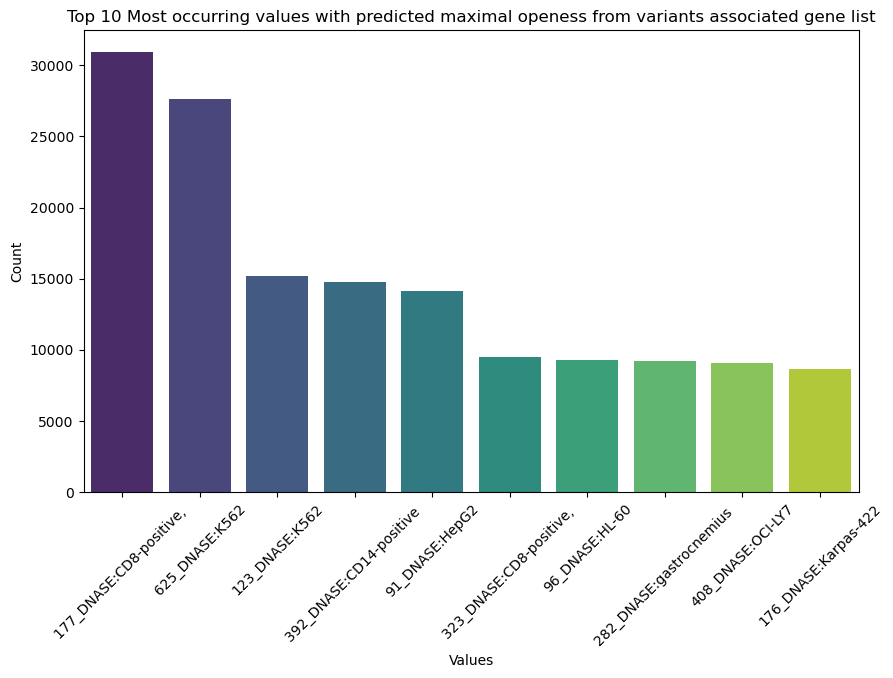

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

top_values = enformer_all_max_df['max_col'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_values.index, y=top_values.values, palette="viridis")
plt.title('Top 10 Most occurring values with predicted maximal openess from variants associated gene list')
plt.xlabel('Values')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()